# Pandas Tutorial

In [36]:
import pandas as pd

| Time - Topic | Video Overview |
| :--- | :--- |
| **Intro to Dataframes** | **Creating DataFrames, Index/Columns, Basic Functionality, Usefull Function** |
| **Loading in DataFrames from Files** | **(CSV, Excel, Parquet, etc.)** |
| **Accessing Data** | **.head() .tail() .sample()** |
| **Accessing Data** | **.loc() .iloc()** |
| **Setting DataFrame Values** | **loc() & iloc()** |
| **Accessing Single Values** | **.at() .iat()** |
| **Accessing Data** | **Grab Columns, Sort Values, Ascending/Descending** |
| **Iterating over a DataFrame (df) with a For Loop** | **df.iterrows()** |
| **Filtering Data** | **Syntax Options, Numeric Values, Multiple Conditions** |
| **Filtering Data** | **String Operations, Regular Expressions (Regex)** |
| **Filtering Data** | **Query Functions** |
| **Adding / Removing Columns** | **Basics, Conditional Values, Math Operations, Renaming Columns** |
| **Adding / Removing Columns** | **String Operations**, **Datetime (pd.to_datetime) Operations** |
| **Saving our Updated DataFrame** | **(df.to_csv, df.to_excel, df.to_parquet, etc)** |
| **Adding / Removing Columns** | **Using Lambda & Custom Functions w/ .apply()** |
| **Merging & Concatenating Data** | **pd.merge(), pd.concat(), types of joins** |
| **Handling Null Values (NaNs)** | **.fillna() .interpolate() .dropna() .isna() .notna()** |
| **Aggregating Data** | **value_counts()** |
| **Aggregating Data** | **Using Groupby - groupby() .sum() .mean() .agg()** |
| **Aggregating Data** | **Pivot Tables** |
| **Aggregating Data** | **Groupby combined with Datetime Operations** |
| **Advanced Functionality** | **.shift() .rank() .cumsum() .rolling()** |
| **New Functionality** | **Pandas 1.0 vs Pandas 2.0 - pyarrow** |



# Intro to Dataframes <a id="intro-df"></a>

**DataFrame** merupakan struktur utama dalam *Library Python Pandas*. Kita bisa mengganggap *DataFrame* sebagai `Table` dengan tambahan toping dan fungsi. Jadi cara kerjanya mirip kaya *spreadsheet* (excel) tapi menggunakan Python.  

### Creating DataFrame

Ok, jadi bentuk *DataFrame* tuh kaya gimana? Ok, kita bisa buat data paling sederhana kaya gini :

```python
df = pd.DataFrame([data][data][data])
```

Kita buat *DataFrame* sederhana yang terdiri dari 2 baris dan lebarnya 2 kolom

In [37]:
# data frame 2 baris, 2 kolom

df = pd.DataFrame([[1,2], [3,4]])

Kalo ditampilin hasilnya kaya gini :

In [38]:
df

,0,1
0,1,2
1,3,4


Jadi yang mana datanya?
- baris 1 : [1, 2]
- baris 2 : [3, 4]

masih bingung, yaudah kita buat yang 3 kolom 2 baris :

In [39]:
# df 3 kolom 2 baris

df = pd.DataFrame([[1,2,3], [4,5,6]])

In [40]:
df.head()

,0,1,2
0,1,2,3
1,4,5,6


---

#### , columns = [ ... ]

Mungkin bagi sebagian orang masih ada yang bingung sama penjelasan diatas, terlebih bingung mana bagian kolom dan baris? Kita ganti saja nama kolomnya semisal menjadi `A`, `B` dan `C`. 

```python
, columns = ["A", "B", "C"] # pada bagian belakang
```

jangan lupa tambahkan koma `,` sebelum menambah syntax `columns`

In [41]:
# data frame 2 baris, 2 kolom

df = pd.DataFrame([[1,2], [3,4]], columns = ['A', 'B'])

In [42]:
df

,A,B
0,1,2
1,3,4


Oke diharapkan udah liat perbedaannya ya. Yang `A` dan `B` itu nama kolom. Sedangkan `0` dan `1` itu menunjukan barisnya. 

Kita buat lagi yang 3 kolom

In [43]:
# menambahkan nama kolom

df = pd.DataFrame([[1,2,3], [4,5,6]], columns = ['A', 'B', 'C'])

In [44]:
# kita cek lagi 5 data teratas menggunakan .head()
df.head()

,A,B,C
0,1,2,3
1,4,5,6


---

Kalo diatas kan cuman DataFrame yang terdiri dari beberapa baris, nah kita bisa improve DataFrame kita menggunakan dari beberapa bentuk, kaya : Dictionary, List of List, dan JSON.

### Dictionary

Ciri paling gampang keliatan dari Dictionary tuh terdiri dari `Key` dan `Value`.

- **Logikanya**: `Key` (Kunci) jadi Judul Kolom, `Value` (List) jadi isinya ke bawah.

- **Rumusnya**: `{'Key'`: `[Value]}`

- **Contohnya**: `{'Buku'`: `['Harry Potter', 'The Lord of the Rings']}`

Kalo contoh di bawah kita nyimpennya per key, dalam jumlah yang sama antar-key.

In [45]:
# Data Mentah (Bentuk Dictionary)
data_buku = {
    'Judul': ['Laskar Pelangi', 'Bumi Manusia', 'Harry Potter'],
    'Penulis': ['Andrea Hirata', 'Pramoedya A. Toer', 'J.K. Rowling'],
    'Harga': [75000, 90000, 150000]
}

# Masak jadi DataFrame
df_buku = pd.DataFrame(data_buku)

df_buku

,Judul,Penulis,Harga
0,Laskar Pelangi,Andrea Hirata,75000
1,Bumi Manusia,Pramoedya A. Toer,90000
2,Harry Potter,J.K. Rowling,150000


- **Kelebihan** : Nama **`Key` otomatis berubah menjadi nama kolom** dan tentunya paling enak dibaca mata manusia.
- **Kekurangan** : jika jumlah `Value` berbeda tiap `Key`, akan terjadi error. (bisa coba code diatas)

---

#### List of Lists

Cara ini dipake kalo kamu punya data yang **"Baris demi Baris"**, tapi belum ada judulnya. Biasanya data kaya gini tuh hasil dari *scraping data website*.

- **Logikanya**: Kamu tumpuk datanya dulu, baru kasih label kolom di akhir.
- **Rumusnya**: [`[data_1]`, `[data_2]`, `[data_3]`], `columns` = [ `'nama_kolom1'` , `'nama_kolom2'` , ... , ]

In [47]:
# Data Mentah (Bentuk List of Lists)
data_nilai = [
    ['Andi', 80, 90],   # Baris 1, 3 data kesamping
    ['Budi', 75, 85],   # Baris 2
    ['Caca', 95, 100]   # Baris 3
]

# Ubah menjadi DataFrame (jangan lupa parameter 'columns')
df_nilai = pd.DataFrame(data_nilai, columns=['Nama', 'Matematika', 'IPA'])

df_nilai

,Nama,Matematika,IPA
0,Andi,80,90
1,Budi,75,85
2,Caca,95,100


**Penting**: >> kalo ga dikasih `columns=['...']`, nanti nama kolomnya jadi angka `0`, `1`, `2`, Gaenak dilihat.

---

#### JSON: Dari List of Dictionaries

Ini biasanya kalau kamu ambil data dari **API** atau database **NoSQL** (seperti MongoDB/Firebase). Setiap baris membawa kuncinya sendiri-sendiri.

- **Logikanya**: Setiap baris adalah satu paket lengkap (ada kunci dan isi).
- **Rumusnya**: `[{Key : Data1}, {Key : Data2}, {Key : Data3}]`

In [48]:
# Data Mentah (Bentuk List of Dictionaries)
data_karyawan = [
    {'Nama': 'Agung', 'Divisi': 'IT', 'Gaji': 10},      # Baris 1
    {'Nama': 'Bayu', 'Divisi': 'HR', 'Gaji': 8},        # Baris 2
    {'Nama': 'Citra', 'Divisi': 'Finance', 'Gaji': 12}  # Baris 3
]

# Masak jadi DataFrame
df_karyawan = pd.DataFrame(data_karyawan)

df_karyawan

,Nama,Divisi,Gaji
0,Agung,IT,10
1,Bayu,HR,8
2,Citra,Finance,12


- **Kelebihan**: Kalau ada data yang bolong (misal Bayu nggak punya 'Gaji'), Pandas otomatis mengisinya dengan `NaN` (Kosong) tanpa error.

In [49]:
# Data Mentah (Bentuk List of Dictionaries)
data_karyawan2 = [
    {'Nama': 'Agung', 'Divisi': 'IT', 'Gaji': 10},      # Baris 1
    {'Nama': 'Bayu', 'Gaji': 8},            # Baris 2, Divisi Kosong
    {'Nama': 'Citra', 'Divisi': 'Finance'}  # Baris 3, Gaji kosong
]

# Masak jadi DataFrame
df_karyawan2 = pd.DataFrame(data_karyawan2)

df_karyawan2

,Nama,Divisi,Gaji
0,Agung,IT,10.0
1,Bayu,NaN,8.0
2,Citra,Finance,NaN


Otomatis akan menjadi `NaN` kalo Divisi atau Gaji tidak dimasukan.

---

### Basic Function

#### .head()

Fungi `.head()` adalah untuk melihat data di 5 baris teratas.

Secara _default_ akan menampilkan 5 baris teratas. Namun kita bisa atur mau menampilkan berapa total baris yang ingin ditampilkan.
- Jika ingin menampilkan 1 baris, atur `.head(1)`
- Jika ingin menampilkan 2 baris, atur `.head(2)`, dan seterusnya.
- Akan menampilkan 5 baris jika kita menggunakan defaut `.head()`

In [50]:
# melihat 1 baris teratas
df.head(1) # ganti angka 1 dengan angka bebas

,A,B,C
0,1,2,3


In [51]:
# melihat 2 baris teratas
df.head(2)

,A,B,C
0,1,2,3
1,4,5,6


In [52]:
# melihat 3 baris teratas
df.head(3)

,A,B,C
0,1,2,3
1,4,5,6


---

#### .tail()

Jika `.head()` digunakan untuk **melihat 5 data teratas**, 

maka `.tail()` digunakan untuk **melihat 5 data terakhir.**

In [53]:
df_karyawan.tail()

,Nama,Divisi,Gaji
0,Agung,IT,10
1,Bayu,HR,8
2,Citra,Finance,12


karena data cuman ada 3, yang tampil hanya 3 baris

`.tail(1)` hanya akan menampilkan 1 baris saja.

In [54]:
# 1 baris paling bawah
df_karyawan.tail(1)

,Nama,Divisi,Gaji
2,Citra,Finance,12


`.tail(2)` juga hanya akan menampilkan 2 baris saja.

In [55]:
# 2 baris paling bawah
df_karyawan.tail(2)

,Nama,Divisi,Gaji
1,Bayu,HR,8
2,Citra,Finance,12


**Sekarang kita nyoba make angka minus**

`df.tail(-n)` artinya: "Tampilkan semua baris, KECUALI `n` baris pertama dari atas

Kita lihat lagi dulu sebelum di beri angka minus :

In [56]:
df_karyawan.tail()

,Nama,Divisi,Gaji
0,Agung,IT,10
1,Bayu,HR,8
2,Citra,Finance,12


Kita coba menggunakan `-1`

In [57]:
df_karyawan.tail(-1)

,Nama,Divisi,Gaji
1,Bayu,HR,8
2,Citra,Finance,12


Bisa dilihat disini, index paling atas atau index `0` atau `-1`, karyawan atas nama `Agung` tidak ditampilkan.

**Buang 2 baris paling atas** (index `0` dan `1`), sisanya tampilkan

In [58]:
df_karyawan.tail(-2)

,Nama,Divisi,Gaji
2,Citra,Finance,12


baris karyawan di index `0` dan `1` tidak ditampilkan (`-1` hingga `-2`). Sehingga hanya menyisakan `Citra`.

---

### Usefull Function

Ada buanyak buanget function yang harus kita ketahui dalam DataFrame, gunanya biar kita semakin paham sama isi data kita.

#### .columns

**`.columns` untuk melihat nama kolom** apa saja yang ada dalam suatu *DataFrame*. Sebagai contoh kita akan menggunakan *DataFrame* => `df`

In [59]:
df

,A,B,C
0,1,2,3
1,4,5,6


Sekarang kita coba lihat ada apa saja kolomnya menggunakan `df.columns`.

In [60]:
df.columns

Index(['A', 'B', 'C'], dtype='object')

Pandas akan menampilkan **kolom yang ada di DataFrame `df`, ternyata ada kolom `A`, `B` dan `C`** yang bertipe data *string* atau *object*.

---

#### .info()

**`.info`** sangat berguna jika kita ingin melihat informasi lengkap dari *DataFrame* yang kita miliki

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       2 non-null      int64
 1   B       2 non-null      int64
 2   C       2 non-null      int64
dtypes: int64(3)
memory usage: 180.0 bytes


Bisa kita lihat begitu detail dari hanya `.info()`

- `<class 'pandas.core.frame.DataFrame'>` : menunjukan ini *class DataFrame*.
- `RangeIndex: 2 entries, 0 to 2` : menunjukan **ada 3 baris** yang **index-nya dimulai dari 0 hingga 2** (index 0, 1 dan 2)
- `Data columns (total 3 columns)` : **memiliki 3 kolom**, yang ditambah perincian sebagai berikut :
    - `0   A       3 non-null      int64` : kolom index ke-0, `A`, memiliki 3 data yang bukan null value, dan bertipe data integer 64 bit.
    - `1   B       3 non-null      int64` : kolom index ke-1, `B`, memiliki 3 data yang bukan null value, dan bertipe data integer 64 bit
    - begitu pula untuk kolom lain
- `dtypes: int64(3)` : kolom dengan tipe data integer 64 bit (ada 3)
- `memory usage: 180.0 bytes` : menggunakan sekitar 204.0 bytes memory di dalam file ini

---

#### .describe()

kalo **`.describe()`** fungsinya buat ngelihat data statistik dari data kita.

Sebelum kita mengetes, alangkah baiknya kita lihat lagi DataFrame yang akan kita gunakan

In [62]:
df

,A,B,C
0,1,2,3
1,4,5,6


In [63]:
df.describe()

,A,B,C
count,2.00000,2.00000,2.00000
mean,2.50000,3.50000,4.50000
std,2.12132,2.12132,2.12132
min,1.00000,2.00000,3.00000
25%,1.75000,2.75000,3.75000
50%,2.50000,3.50000,4.50000
75%,3.25000,4.25000,5.25000
max,4.00000,5.00000,6.00000


**nanti penjelasan dibawah diubah dulu.|**

- `count` : Total data di tiap kolom (masing-masing memiliki 2 data / baris)
- `mean` : Rata-rata tiap kolom, untuk kolom `A` mendapatkan hasil `2.5` dari $\frac{(1+4)}{2} = 2.5$
- `min` : Nilai terkecil tiap kolom
- `max` : Nilai terbesar tiap kolom
- `std` : Seberapa jauh data tersebar dari atau kabur dari rata-rata (mean)
    - Rumusnya seperti ini : $s = \sqrt{\frac{\sum (x_i - \bar{x})^2}{n - 1}}$
        - $x_i$ : Nilai data ke-i
        - $\bar{x}$ : Rata - rata (mean)
        - $n$ : Jumlah data
    - Contoh perhitungannya manual kolom `A`, mari kita beda `3.0` didapatkan dari mana :
        - Data kolom `A` : `[1, 4]`
        - Cari rata-rata (*Mean*) :
            - $\bar{x} = \frac{1+4}{2} = 2.5$
        - Cari selisih kuadrat dari *Mean* :
            - $(1 - 2.5)^2 = (-1.5)^2 = 2.25$
            - $(4 - 2.5)^2 = (1.5)^2 = 2.25$
        - Jumlahkan selisihnya (Sum of Square) :
            - $2.25 + 2.25 = 4.5$
        - Bagi dengan $(n - 1)$
            - $\frac{4.5}{2-1} = \frac{4.5}{1} = 4.5$
        - Akar Kuadrat (Hasil Akhir) :
            -  $\sqrt{4.5} = 2.1213203...$
- Quartile (`25%`, `50%` dan `75%`)
Quartile ini bisa diibaratkan kalau kita punya martabak panjang (data sudah diurutkan dari nilai terkecil ke terbesar), lalu kita potong menjadi 4 bagian sama besar.
Contoh dari data kita, kolom A yang memiliki data `[1, 4]` :
- Contoh dari data kita, kolom `A` yang memiliki data `[1, 4, 7]`
- `25%` (Q1 - Quartile bawah)
    - Artinya **25% data kita ada di bawah angka ini**.
    - Berdasarkan metode linier Pandas pada data `[1, 4]`, nilainya adalah 1.75
- `50%` (Q2 - Median)
    - Artinya **titik tengah**, jadi ada 50% data dibawah dan 50% data diatas.
    - Tepat di tengah antara `1` dan `4`, nilainya adalah `2.5`
- `75%` (Q3 - Quartile atas)
    - Artinya ada **75% data nilainya dibawah ini**, dan **hanya ada 25% data yang diatas ini**.
    - Nilainya adalah 3.25

---

#### .nunique()

Digunakan untuk melihat berapa jumlah data yang unik dalam satu DataFrame yang kita miliki

In [64]:
df

,A,B,C
0,1,2,3
1,4,5,6


In [65]:
df.nunique()

A    2
B    2
C    2
dtype: int64

Maksudnya dari output diatas, tiap - tiap data kaya `A`, `B` dan `C` memiliki 2 data unik. Ayo kita coba lihat satu persatu

#### .nunique

Kalo pengen lihat ada data unik apa aja dalam suatu kolom, kita bisa gini :

```python
df['nama_kolom'].nunique # tanpa tanda kurung ()
```

In [66]:
df["A"].nunique

<bound method IndexOpsMixin.nunique of 0    1
1    4
Name: A, dtype: int64>

diperlihatkan secara jelas, di kolom `A` ini ada 
- index-0 nilai uniknya `1`
- index-1 nilai uniknya `4`

Coba kita cek ke kolom yang lain semisam kolom `B`

In [67]:
df["B"].nunique

<bound method IndexOpsMixin.nunique of 0    2
1    5
Name: B, dtype: int64>

Disini diliatin kalo di kolom `B` memiliki data unik seperti ini :
- index-0 nilai uniknya `2`
- index-1 nilai uniknya `5`

---

#### .shape

Syntax selanjutnya yang berguna untuk melihat berapa jumlah kolom dan baris yang kita miliki

In [68]:
df.shape

(2, 3)

Maksudnya memiliki 2 baris dan 3 kolom. 

Mari kita buat data baru untuk melihat perbedaan dengan jelas

In [69]:
# menambah data baru untuk cek .shape
df = pd.DataFrame([[1,2,3], [4,5,6], [7,8,9], [10,11,12] ], columns = ['A', 'B', 'C'])

In [70]:
df

,A,B,C
0,1,2,3
1,4,5,6
2,7,8,9
3,10,11,12


In [71]:
df.shape

(4, 3)

yang berarti data diatas memiliki 4 baris (index 0 - 3) dan 3 kolom (kolom `A`, `B` dan `C`)

Coba kita cek `df_karyawan2` tadi yang memiliki nilai `NaN`

In [72]:
df_karyawan2

,Nama,Divisi,Gaji
0,Agung,IT,10.0
1,Bayu,NaN,8.0
2,Citra,Finance,NaN


In [73]:
df_karyawan2.shape

(3, 3)

Ternyata masih dibaca 3 x 3 walau memiliki NaN

---

#### .size

size sih penting ga penting ya, ya karena cuman kaya melihat total data kalo di itung satu - satu ada berapa.

In [74]:
df

,A,B,C
0,1,2,3
1,4,5,6
2,7,8,9
3,10,11,12


In [75]:
df.size

12

12 dapet dari mana? tadi diatas kita udah cek `df` terakhir menggunakan `df.shape` outputnya : **(4, 3)**

maka 12 itu dapet dari $4 \times 3 = 12$

In [76]:
df_karyawan2

,Nama,Divisi,Gaji
0,Agung,IT,10.0
1,Bayu,NaN,8.0
2,Citra,Finance,NaN


In [77]:
df_karyawan2.size

9

Oh.. ternyata kalo nilai suatu data berupa `NaN` juga tetap dihitung

---

### Index / Columns

Angka `0`, `1`, `2` dan seterusnya merupakan **`index`** atau nomor baris dalam suatu *DataFrame*. Kita bia cek dengan cara seperti ini :

In [78]:
df

,A,B,C
0,1,2,3
1,4,5,6
2,7,8,9
3,10,11,12


#### .index

In [79]:
df.index

RangeIndex(start=0, stop=4, step=1)

- index-nya dimulai dari `0`
- berhenti ketika indexnya 4 (kok bukan index 3 ya? -_-)
- dan lompatan atau step dari satu index ke index lain (0 sampai 3) = 1 langkah

---

#### .index.tolist()

Mungkin kita tadi diatas cukup anehnya kok `stop=4`? bukan `3`? Nah biar makin yakin, kita bisa ngecek manual kaya gini dengan cara di convert dulu ke list

In [80]:
df.index.tolist()

[0, 1, 2, 3]

Nah dengan ini kita bisa lihat jelas index-nya apa aja

---

#### , index = [ ... ]

beda dengan `.index` diatas, disini kita bisa *setting* bentuk index-nya dalam bentuk angka. Dalam artian ga selalu dari index 0 hingga sekian.. 

Secara *default*, `index` mengurutkan data dengan angka dimulai dari `0`, `1`, `2` dan seterusnya sampai baris terakhir. Namun kita bisa menggantinya dengan selain angka seperti ini :  

In [81]:
# kita modif data df diatas
# mengganti index menjadi huruf

df = pd.DataFrame([[1,2,3], [4,5,6], [7,8,9]] , columns = ['A', 'B', 'C'] , index=["A", "B", "C"])

In [82]:
df

,A,B,C
A,1,2,3
B,4,5,6
C,7,8,9


Nah disini terlihat kalo DataFrame yang barusan kita buat udah jadi `A`, `B` dan `C` **bukan lagi `0`, `1`, dan `2`**. 

Mungkin kita perlu ganti nama index-nya biar ga samaan kaya nama kolom

In [83]:
# kita modif data df diatas
# mengganti index menjadi huruf

df = pd.DataFrame([[1,2,3], [4,5,6], [7,8,9]] , columns = ['A', 'B', 'C'] , index=["x", "y", "z"])

In [84]:
df

,A,B,C
x,1,2,3
y,4,5,6
z,7,8,9


Oke, udah berubah nama index-nya jadi `x`, `y` dan `z`.

coba kita cek lagi 

In [85]:
df.index

Index(['x', 'y', 'z'], dtype='object')

*index*-nya menjadi `x`, `y` dan `z` dan bertipe data *object* atau *string*.

In [86]:
df.index.tolist()

['x', 'y', 'z']

---

## Loading DataFrames from File

Membuat DataFrame seperti :

```python
df = pd.DataFrame([[1,2,3], [4,5,6], [7,8,9]] , columns = ['A', 'B', 'C'] , index=["x", "y", "z"])
```

Sebenarnya memang bisa. tapi dalam dunia nyata, biasanya kita akan *load* data dari sebuah file karena data era saat ini sudah sangat massive dan sangat banyak bahkan sampai jutaan baris dalam satu file. Mari kita latihan menggunakan data sederhana berikut :

### CSV File

Kita punya data csv sederhana, yaitu `coffee.csv` yang berisi data sederhana seperti berikut :

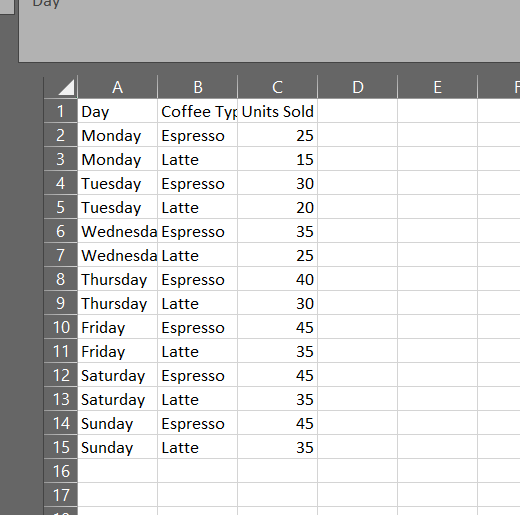

Merupakan data sederhana dari penjualan kopi dari sebuah cafe yang terdiri dari kolom berikut :
- `Day` : Hari dijualnya kopi
- `Coffee Type` : Jenis kopi
- `Units Sold` : Total jumlah kopi yang terjual

dan kita akan mencoba membaca file tersebut menggunakan Python menggunakan `read_csv`

```python
pd.read_csv(file_name)
```

In [45]:
coffee = pd.read_csv('./warm-up data/coffee.csv') 

In [46]:
coffee.head()

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35


---

### Github Raw File CSV

Salah satu hal yang keren di Python Pandas adalah kita ga harus mendownload data di lokal, kita bisa menggunakan repo di Github. 

Caranya, bebas mau menggunakan `repo` milik siapa pun. 

kalo pengen coba, coba klik link ini :
https://github.com/agungwahyuprayogo/advanced-pandas-toolkit/blob/main/warm-up%20data/coffee.csv

Lalu cari file `csv`, lalu klik pada bagian **`raw`**

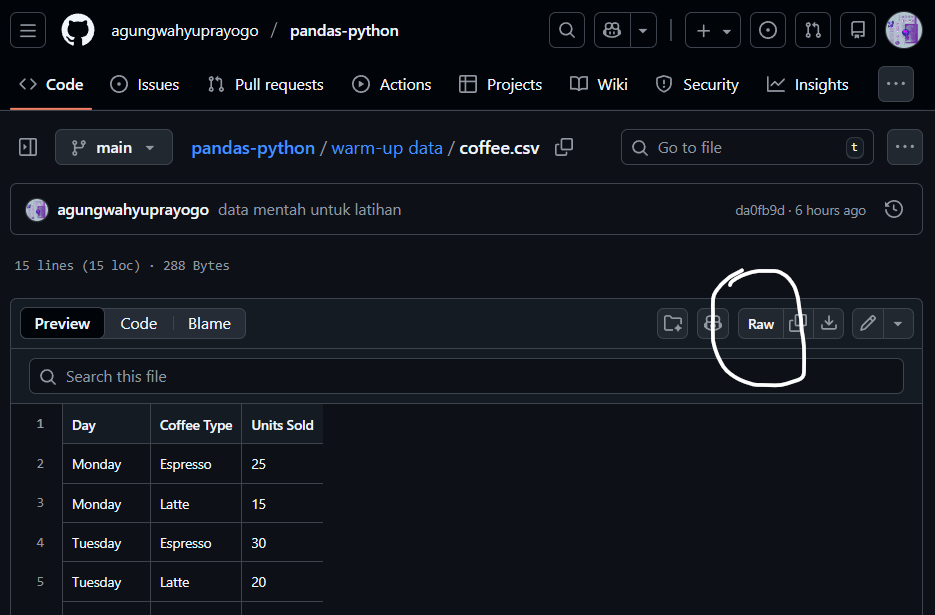


Jika sudah, kita bisa tinggal copy link yang ada diatas :

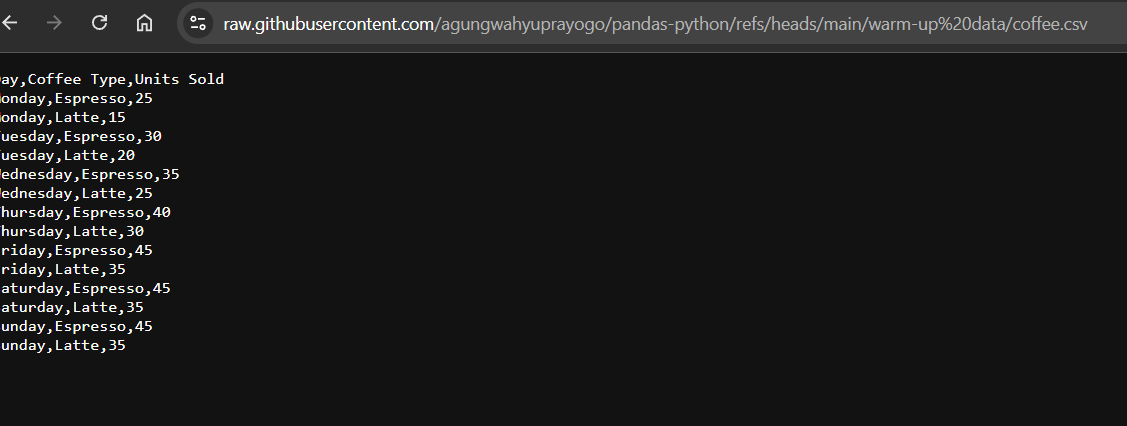

In [47]:
# masukan link pada ('link')

# hapus tanda pagar (#), jika sudah terhubung ke internet
# coffee = pd.read_csv('https://raw.githubusercontent.com/agungwahyuprayogo/pandas-python/refs/heads/main/warm-up%20data/coffee.csv')

In [48]:
coffee

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35
5,Wednesday,Latte,25
6,Thursday,Espresso,40
7,Thursday,Latte,30
8,Friday,Espresso,45
9,Friday,Latte,35


---

Kita kembali make file lokal aja ya, 

In [49]:
# from local
coffee = pd.read_csv('./warm-up data/coffee.csv')

In [50]:
coffee

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35
5,Wednesday,Latte,25
6,Thursday,Espresso,40
7,Thursday,Latte,30
8,Friday,Espresso,45
9,Friday,Latte,35


Beberapa hal yang perlu ditahui tentang *load data* menggunakan file adalah banyak perusahaan yang menyimpan datanya dalam bentuk file ekstensi `CSV` yang dimana file dengan ekstensi ini merupakan data yang paling umum digunakan. csv bukan bentuk data yang terbaik, tapi kembali lagi dengan kebutuhan dan kasus yang dibutuhkan. Namun satu hal menyenangkan mengenai `csv` adalah mereka mudah untuk dibaca. Memang ada satu **kelemahan** dari file berformat `csv` ini, **yaitu memiliki ukuran yang terbilang besar**. bisa dilihat gambar berikut : 

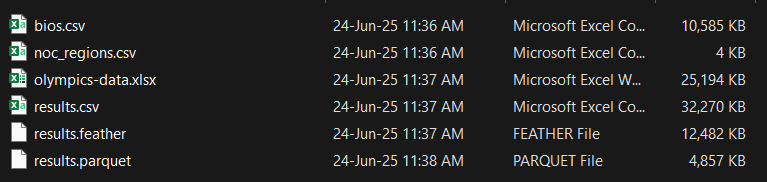

Saya memiliki data `Result` dari *Olympic* tahun 1860 yang **ukurannya mencapai sekitar 32 Megabytes** hanya untuk ukuran satu file excel.

Tak perlu khawatir, **ada bentuk format file lain yang dapat kita gunakan** seperti format file **`.feather`** yang memiliki data yang sama persis tapi dengan excel namun hanya memiliki ukurannya **`12 Megabytes`**. Atau file dengan format **`parquet`** yang hanya memiliki ukuran **4 Megabytes**, dimana format file tersebut sangat populer di dunia _data engineering_ karena tidak terlalu memakan *memory*.

Alternatif lain kita dapat menggabung beberapa file `csv` ke dalam bentuk file **`Excel`**. Dapat digunakan juga namun akan menjadi **file dengan waktu loading paling lama dari pada file format lain**.

Dengan Python, kita dapat load semua bentuk format diatas dengan cara berikut :

### Feather File

In [51]:
results = pd.read_feather('./data/results.feather')

`.` dengan *double* `..` beda ya! 

- satu `.` tandanya kita disuruh untuk scan folder yang sama dengan file ipynb ini, lalu kita memerintahkan untuk mengecek apakah ada folder `data`
- nah kalo *double* `..` kita memerintahkan untuk keluar ke folder sebelumnya baru ke folder `data`

In [52]:
results.head()

,year,type,discipline,event,as,athlete_id,noc,team,place,tied,medal
0,1912.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,None,17.0,True,None
1,1912.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jean Montariol,NaN,False,None
2,1920.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,None,32.0,True,None
3,1920.0,Summer,Tennis,"Doubles, Mixed (Olympic)",Jean-François Blanchy,1,FRA,Jeanne Vaussard,8.0,True,None
4,1920.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jacques Brugnon,4.0,False,None


---

### Parquet File

In [53]:
results = pd.read_parquet('./data/results.parquet')

In [54]:
results.head()

,year,type,discipline,event,as,athlete_id,noc,team,place,tied,medal
0,1912.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,None,17.0,True,None
1,1912.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jean Montariol,NaN,False,None
2,1920.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,None,32.0,True,None
3,1920.0,Summer,Tennis,"Doubles, Mixed (Olympic)",Jean-François Blanchy,1,FRA,Jeanne Vaussard,8.0,True,None
4,1920.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jacques Brugnon,4.0,False,None


Kita lihat, kita dapat load data `Olympic Result` ini dalam bentuk Data Frame **begitu mudah dan cepat.**

### Excel File

Kita pun dapat *load* data file excel dengan cara berikut :

In [55]:
olympics_data = pd.read_excel('./data/olympics-data.xlsx')

Lama bet njirr :v oke kita lihat dulu isi datanya :

In [56]:
olympics_data.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25


Karena file excel bisa menaruh `sheets` lebih dari satu (ada `bios` dan `results`)

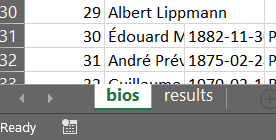

kita bisa juga untuk lebih spesifik mengambil data `sheets` bagian mana yang kita mau :

In [57]:
olympics_data = pd.read_excel('./data/olympics-data.xlsx', sheet_name="results")

Alamak harus **nunggu 17 detik hanya untuk load satu file `excel`** :) padahal file dengan **format `parquet` cuman butuh sekitar 1-2 detik**. jadi kalo kalian butuh waktu dengan cepat, disarankan menggunakan file dengan format `parquet`. 

Tapi yaa kalo kalian bekerja dan terpaksa berkolaborasi dengan orang lain ya memang `csv` sudah cukup.

Dan sekarang kalo kita lihat harusnya data `Olympics` di `sheets` sudah berubah : 

In [58]:
olympics_data.head()

,year,type,discipline,event,as,athlete_id,noc,team,place,tied,medal
0,1912.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,NaN,17.0,True,NaN
1,1912.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jean Montariol,NaN,False,NaN
2,1920.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,NaN,32.0,True,NaN
3,1920.0,Summer,Tennis,"Doubles, Mixed (Olympic)",Jean-François Blanchy,1,FRA,Jeanne Vaussard,8.0,True,NaN
4,1920.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jacques Brugnon,4.0,False,NaN


### Konversi Format File

Namun, semisal memang dibutuhkan format file dalam bentuk ekstensi lain karena kecepatan dan efisiensi *memory*, kita dapat mengkonversi nya dengan cara berikut :

In [59]:
bios = pd.read_csv('./data/bios.csv')

Supaya kita masukan ke dalam folder `konversi data`. Agar data tidak berantakan dan tidak satu folder dengan file ipynb

#### .to_parquet( folder/nama file )

In [60]:
# Untuk Parquet
bios.to_parquet("konversi data/bios.parquet")

#### .to_feather(folder/nama file )

In [61]:
# Untuk Feather
bios.to_feather("konversi data/bios.feather")

**Kita tes panggil lagi ya**

In [62]:
bios_parquet = pd.read_parquet('konversi data/bios.parquet')
bios_parquet

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,None
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25
...,...,...,...,...,...,...,...,...,...,...
145495,149222,Polina Luchnikova,2002-01-30,Serov,Sverdlovsk,RUS,ROC,167.0,61.0,None
145496,149223,Valeriya Merkusheva,1999-09-20,Moskva (Moscow),Moskva,RUS,ROC,168.0,65.0,None
145497,149224,Yuliya Smirnova,1998-05-08,Kotlas,Arkhangelsk,RUS,ROC,163.0,55.0,None
145498,149225,André Foussard,1899-05-19,Niort,Deux-Sèvres,FRA,France,166.0,NaN,1986-03-18


In [63]:
bios_feather = pd.read_feather('konversi data/bios.feather')
bios_feather

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,None
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25
...,...,...,...,...,...,...,...,...,...,...
145495,149222,Polina Luchnikova,2002-01-30,Serov,Sverdlovsk,RUS,ROC,167.0,61.0,None
145496,149223,Valeriya Merkusheva,1999-09-20,Moskva (Moscow),Moskva,RUS,ROC,168.0,65.0,None
145497,149224,Yuliya Smirnova,1998-05-08,Kotlas,Arkhangelsk,RUS,ROC,163.0,55.0,None
145498,149225,André Foussard,1899-05-19,Niort,Deux-Sèvres,FRA,France,166.0,NaN,1986-03-18


berhasil semua!

Sebenarnya ga cuman `to_parquet`, `to_feather`, tapi juga masih banyak yang lain bahkan ke csv, excel.

---

---

---

## Accessing Data 1

oke, selanjutnya kita liat bagaimana kita bisa mengakses data dengan cara yang berbeda-beda menggunakan `Pandas`.

Mengakses data tuh maksudnya kita pengen ambil data semisal kolom tertentu aja, baris tertentu aja, dan seterusnya.

*DataFrame* yang akan kita gunakan sebagai contoh adalah `coffee.csv`. 

Dan pertama kita ingin melihat 5 data teratas menggunakan `.head()`

### .head()

In [64]:
coffee.head()

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35


Jika ingin melihat 7 data teratas, cukup masukan angka 7 dalam tanda kurung

In [65]:
coffee.head(7)

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35
5,Wednesday,Latte,25
6,Thursday,Espresso,40


---

Untuk melihatnya secara full cukup dengan :

#### DataFrame names

ini paling simple

In [66]:
coffee

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35
5,Wednesday,Latte,25
6,Thursday,Espresso,40
7,Thursday,Latte,30
8,Friday,Espresso,45
9,Friday,Latte,35


---

#### print(DataFrame Name)

Terkadang ada beberapa environmet / editor yang tidak secara otomatis menampilkan cara diatas, sehingga harus kita `print()` terlebih dahulu baru muncul

In [67]:
print(coffee)

          Day Coffee Type  Units Sold
0      Monday    Espresso          25
1      Monday       Latte          15
2     Tuesday    Espresso          30
3     Tuesday       Latte          20
4   Wednesday    Espresso          35
5   Wednesday       Latte          25
6    Thursday    Espresso          40
7    Thursday       Latte          30
8      Friday    Espresso          45
9      Friday       Latte          35
10   Saturday    Espresso          45
11   Saturday       Latte          35
12     Sunday    Espresso          45
13     Sunday       Latte          35


---

#### display(DataFrame Name)

Bisa juga menggunakan `display()`. ya walaupun hasilnya tetap akan sama

In [68]:
display(coffee)

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35
5,Wednesday,Latte,25
6,Thursday,Espresso,40
7,Thursday,Latte,30
8,Friday,Espresso,45
9,Friday,Latte,35


---

### .tail()

Untuk melihat 5 data terakhir, secara *default* kita cukup mengetik .tail()

In [69]:
coffee.tail()

,Day,Coffee Type,Units Sold
9,Friday,Latte,35
10,Saturday,Espresso,45
11,Saturday,Latte,35
12,Sunday,Espresso,45
13,Sunday,Latte,35


Jika berubah pikiran seperti ingin melihat 7 data terakhir :

In [70]:
coffee.tail(7)

,Day,Coffee Type,Units Sold
7,Thursday,Latte,30
8,Friday,Espresso,45
9,Friday,Latte,35
10,Saturday,Espresso,45
11,Saturday,Latte,35
12,Sunday,Espresso,45
13,Sunday,Latte,35


---

### .sample

salah satu hal yang perlu diketahu juga adalah, jika kita ingin mengakses data secara acak, kita bisa menggunakan `.sample()`. 

Secara default hanya akan menampilkan satu data :

In [71]:
coffee.sample() 

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25


^^ **Silahkan run berulang kali *cell* diatas, maka hasilnya akan selalu berubah** ^^

Jika **ingin melihat data secara acak sebanyak 7 baris**, maka masukan *value* dalam tanda kurung -> `.sample(7)`

In [72]:
coffee.sample(7)

,Day,Coffee Type,Units Sold
10,Saturday,Espresso,45
5,Wednesday,Latte,25
6,Thursday,Espresso,40
12,Sunday,Espresso,45
9,Friday,Latte,35
8,Friday,Espresso,45
7,Thursday,Latte,30


In [73]:
coffee.sample(4)

,Day,Coffee Type,Units Sold
1,Monday,Latte,15
10,Saturday,Espresso,45
9,Friday,Latte,35
8,Friday,Espresso,45


cara `.sample()` terkadang digunakan jika ingin melihat data dalam bentuk *scattered* dan mungkin ingin melihat data paling atas apa, data paling bawah apa tanpa harus mengikuti data bawaan file.

#### , random_state = 

ada cara semisal kita ingin menetapkan angka sample yang cocok, kita bisa menambahkan *value* ke dalam `random_state` :

In [74]:
coffee.sample(10, random_state=101)

,Day,Coffee Type,Units Sold
12,Sunday,Espresso,45
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
13,Sunday,Latte,35
10,Saturday,Espresso,45
5,Wednesday,Latte,25
0,Monday,Espresso,25
4,Wednesday,Espresso,35
8,Friday,Espresso,45
9,Friday,Latte,35


**Jika kita sudah menentukan `random_state`, sebanyak apa-pun kita run hasilnya akan tetap sama**. 

kecuali jika kita merubah *value* dalam `random_state` dengan angka lain  -> Istilahnya *deterministic*

---

oke, kita udah tahu caranya melihat data secara acak. 

Nah bagaimana caranya jika kita ingin mengakses data secara spesifik? Well, kita bisa menggunakan `.loc` dan `.iloc`

### .loc[ ]

kita awali dengan `loc` terlebih dahulu ya.

`loc` memperbolehkan kita untuk filter baris dan kolom *DataFrame* kita. Lebih detailnya seperti ini :

```python
coffee.loc[# row / baris , coloumn / kolom ]
```

okedeh, kita **coba dulu dengan mengakses baris index ke-0**. 

Kita lihat dulu DataFrame kita

In [75]:
coffee

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35
5,Wednesday,Latte,25
6,Thursday,Espresso,40
7,Thursday,Latte,30
8,Friday,Espresso,45
9,Friday,Latte,35


kita coba akses menggunakan `.loc` untuk index ke-0

In [76]:
coffee.loc[0]

Day              Monday
Coffee Type    Espresso
Units Sold           25
Name: 0, dtype: object

Jika ingin mengakses baris berdasarkan index lebih dari satu baris :

```python
coffee.loc[ [index, index, index] ]
```

Semisal kita ingin mengakses baris index ke-1, 4, dan 6

In [77]:
coffee.loc[ [1, 4, 6] ]

,Day,Coffee Type,Units Sold
1,Monday,Latte,15
4,Wednesday,Espresso,35
6,Thursday,Espresso,40


Lalu juga kita bisa `slicing` seperti dimulai dari berapa hingga berapa

Semisal dari index 0 hingga index 3 :

In [78]:
coffee.loc[0:3]

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20


index 1 hingga index 5 :

In [79]:
coffee.loc[1:5]

,Day,Coffee Type,Units Sold
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35
5,Wednesday,Latte,25


dari index ke-10 hingga akhir : 

In [80]:
coffee.loc[10:]

,Day,Coffee Type,Units Sold
10,Saturday,Espresso,45
11,Saturday,Latte,35
12,Sunday,Espresso,45
13,Sunday,Latte,35


atau dari awal hingga index ke-10 :

In [81]:
coffee.loc[:10]

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35
5,Wednesday,Latte,25
6,Thursday,Espresso,40
7,Thursday,Latte,30
8,Friday,Espresso,45
9,Friday,Latte,35


seperti yang sudah dijelaskan diatas, kalo kita juga bisa mengakses kolom

```python
coffee.loc[ baris , kolom ]
```

kita coba akses baris index ke-`1`, `5` dan `7` beserta kolom `"Days"` :

In [82]:
coffee.loc[ [1,5,7] , "Day" ]

1       Monday
5    Wednesday
7     Thursday
Name: Day, dtype: object

Lalu semisal 2 kolom, kita perlu menambahkan `[]` terlebih dahulu agar tidak error

```python
coffee.loc [baris, baris] , [kolom, kolom] ]
```

In [83]:
coffee.loc[ [1,5,7] , ["Day", "Units Sold"] ]

,Day,Units Sold
1,Monday,15
5,Wednesday,25
7,Thursday,30


lalu semisal kita ingin mengakses semua data namun hanya di kolom `Days` dan `Units Sold` :

In [84]:
coffee.loc[ : , ["Day", "Units Sold"] ]

,Day,Units Sold
0,Monday,25
1,Monday,15
2,Tuesday,30
3,Tuesday,20
4,Wednesday,35
5,Wednesday,25
6,Thursday,40
7,Thursday,30
8,Friday,45
9,Friday,35


---

### .iloc[ ]

cara kerjanya hampir mirip dengan `loc`. 

Hanya saja di `iloc` kita perlu **menggantinya dengan index pada kolom**

Semisal kita ingin mengakses semua baris dan hanya menggambil kolom **`Day`** (index ke-0) dan kolom **`Units Sold`** (index ke-2) :

In [85]:
coffee.iloc[ : , [0, 2] ] # days dan units sold kita ganti urutan kolom

,Day,Units Sold
0,Monday,25
1,Monday,15
2,Tuesday,30
3,Tuesday,20
4,Wednesday,35
5,Wednesday,25
6,Thursday,40
7,Thursday,30
8,Friday,45
9,Friday,35


Kalo pengen lihat dari baris ke-2 hingga 10, lalu hanya ingin mengambil kolom `Coffee Type` (index 1) :

In [86]:
coffee.iloc[ 2:10 , 1 ]

2    Espresso
3       Latte
4    Espresso
5       Latte
6    Espresso
7       Latte
8    Espresso
9       Latte
Name: Coffee Type, dtype: object

---

### Change index to String

Tapi satu hal yang harus kita ketahui adalah, **jika kita mengubah index yang awalnya angka urutan baris dari 0 hingga akhir dan menggantinya dengan string, maka `.loc` akan error**. 

Kita coba deh mengganti index menggunakan hari

In [87]:
coffee.index = coffee["Day"]

In [88]:
coffee

,Day,Coffee Type,Units Sold
Day,,,
Monday,Monday,Espresso,25
Monday,Monday,Latte,15
Tuesday,Tuesday,Espresso,30
Tuesday,Tuesday,Latte,20
Wednesday,Wednesday,Espresso,35
Wednesday,Wednesday,Latte,25
Thursday,Thursday,Espresso,40
Thursday,Thursday,Latte,30
Friday,Friday,Espresso,45


oke, berhasil yang mengubah index menggunakan `Day`

Nah akan error jika kita mengaksesnya menggunakan `loc`

```python
---------------------------------------------------------------------------
TypeError                                 Traceback (most recent call last)
Cell In[86], line 2
      1 # run error 
----> 2 coffee.loc[0:]

File C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\indexing.py:1191, in _LocationIndexer.__getitem__(self, key)
   1189 maybe_callable = com.apply_if_callable(key, self.obj)
   1190 maybe_callable = self._check_deprecated_callable_usage(key, maybe_callable)
-> 1191 return self._getitem_axis(maybe_callable, axis=axis)

File C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\indexing.py:1411, in _LocIndexer._getitem_axis(self, key, axis)
   1409 if isinstance(key, slice):
   1410     self._validate_key(key, axis)
-> 1411     return self._get_slice_axis(key, axis=axis)
   1412 elif com.is_bool_indexer(key):
   1413     return self._getbool_axis(key, axis=axis)

File C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\indexing.py:1443, in _LocIndexer._get_slice_axis(self, slice_obj, axis)
   1440     return obj.copy(deep=False)
   1442 labels = obj._get_axis(axis)
-> 1443 indexer = labels.slice_indexer(slice_obj.start, slice_obj.stop, slice_obj.step)
   1445 if isinstance(indexer, slice):
   1446     return self.obj._slice(indexer, axis=axis)

File C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\indexes\base.py:6662, in Index.slice_indexer(self, start, end, step)
   6618 def slice_indexer(
   6619     self,
   6620     start: Hashable | None = None,
   6621     end: Hashable | None = None,
   6622     step: int | None = None,
   6623 ) -> slice:
   6624     """
   6625     Compute the slice indexer for input labels and step.
   6626 
   (...)
   6660     slice(1, 3, None)
   6661     """
-> 6662     start_slice, end_slice = self.slice_locs(start, end, step=step)
   6664     # return a slice
   6665     if not is_scalar(start_slice):

File C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\indexes\base.py:6879, in Index.slice_locs(self, start, end, step)
   6877 start_slice = None
   6878 if start is not None:
-> 6879     start_slice = self.get_slice_bound(start, "left")
   6880 if start_slice is None:
   6881     start_slice = 0

File C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\indexes\base.py:6794, in Index.get_slice_bound(self, label, side)
   6790 original_label = label
   6792 # For datetime indices label may be a string that has to be converted
   6793 # to datetime boundary according to its resolution.
-> 6794 label = self._maybe_cast_slice_bound(label, side)
   6796 # we need to look up the label
   6797 try:

File C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\indexes\base.py:6727, in Index._maybe_cast_slice_bound(self, label, side)
   6725 # reject them, if index does not contain label
   6726 if (is_float(label) or is_integer(label)) and label not in self:
-> 6727     self._raise_invalid_indexer("slice", label)
   6729 return label

File C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\indexes\base.py:4301, in Index._raise_invalid_indexer(self, form, key, reraise)
   4299 if reraise is not lib.no_default:
   4300     raise TypeError(msg) from reraise
-> 4301 raise TypeError(msg)

TypeError: cannot do slice indexing on Index with these indexers [0] of type int
```

Tapi kalo kita ganti menggunakan index berupa string (karena udah diubah)

In [89]:
coffee.loc["Monday"]

,Day,Coffee Type,Units Sold
Day,,,
Monday,Monday,Espresso,25
Monday,Monday,Latte,15


In [90]:
coffee.loc[ ["Monday", "Wednesday"]]

,Day,Coffee Type,Units Sold
Day,,,
Monday,Monday,Espresso,25
Monday,Monday,Latte,15
Wednesday,Wednesday,Espresso,35
Wednesday,Wednesday,Latte,25


In [91]:
coffee.loc[ "Monday" : "Wednesday" , "Units Sold"]

Day
Monday       25
Monday       15
Tuesday      30
Tuesday      20
Wednesday    35
Wednesday    25
Name: Units Sold, dtype: int64

jadi intinya : 

```python
coffee.loc[baris, kolom] 
```

```python
coffee.iloc[baris, kolom] # hanya dapat diakses dengan index (angka) 
```


kita load data coffee kembali dari awal

In [92]:
coffee = pd.read_csv('./warm-up data/coffee.csv')

In [93]:
coffee

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35
5,Wednesday,Latte,25
6,Thursday,Espresso,40
7,Thursday,Latte,30
8,Friday,Espresso,45
9,Friday,Latte,35


---

---

### Setting DataFrame Values 

#### Change Value with .loc

Anggaplah kita punya kesalah di *DataFrame* dan kita mencoba untuk memperbaikinya, 

In [94]:
coffee.loc[1]

Day            Monday
Coffee Type     Latte
Units Sold         15
Name: 1, dtype: object

Seharusnya yang terjual 10, bukan 15. 

Kita bisa menggantinnya dengan cara pada `index` ke-1 `Units Sold` = 15 -> 10 :

In [95]:
coffee.loc[1, "Units Sold"] = 10

Kita cek lagi, harusnya sudah berubah

In [96]:
coffee.loc[1]

Day            Monday
Coffee Type     Latte
Units Sold         10
Name: 1, dtype: object

Oke, sudah berubah yang **awalnya 15** men**jadi 10**.

**Kita juga bisa mengganti banyak data sekaligus**

Semisal kita cek dulu index 2 hingga 5

In [97]:
coffee.loc[2:5] 

,Day,Coffee Type,Units Sold
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35
5,Wednesday,Latte,25


Lalu kita **ganti `Units Sold` pada index `2 hingga 5` menjadi `25`**.

In [98]:
coffee.loc[2:5, "Units Sold"] = 25

In [99]:
coffee.loc[2:5]

,Day,Coffee Type,Units Sold
2,Tuesday,Espresso,25
3,Tuesday,Latte,25
4,Wednesday,Espresso,25
5,Wednesday,Latte,25


---

#### Change Value with iloc

kita coba juga menggunakan `.iloc`

In [100]:
coffee.iloc[10:]

,Day,Coffee Type,Units Sold
10,Saturday,Espresso,45
11,Saturday,Latte,35
12,Sunday,Espresso,45
13,Sunday,Latte,35


Semisal kita **ingin mengubah data penjulan dari `index ke-10 hingga index terakhir` menjadi `40`** (menggunakan iloc) :

In [101]:
# jangan lupa, iloc menggunakan nomor index di kolom maupun index
# index 10 hingga akhir, kolom Units Sold (index 2) = 45
coffee.iloc[10:, 2] = 45 

In [102]:
coffee.iloc[10:]

,Day,Coffee Type,Units Sold
10,Saturday,Espresso,45
11,Saturday,Latte,45
12,Sunday,Espresso,45
13,Sunday,Latte,45


Oke, sekarang sudah berubah

---

## Accessing Data 2

Kita Load ulang ya menggunakan data asli karena diatas sudah kita acak-acak.

In [103]:
coffee = pd.read_csv('./warm-up data/coffee.csv')
coffee

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35
5,Wednesday,Latte,25
6,Thursday,Espresso,40
7,Thursday,Latte,30
8,Friday,Espresso,45
9,Friday,Latte,35


Salah satu cara yang paling efektif untuk mengakses suatu *DataFrame* adalah menggunakan `.at` dan `.iat`. 

Sebenernya mirip cara kerjanya dari `.loc` dan `.iloc`, 

tapi untuk `.at` dan `.iat` disarankan mencari value secepat dan seefisien mungkin dalam hal proses waktu *processing*.

### .at[ ]

Mirip `.loc` hanya saja hanya bisa untuk mengakses 1 value spesifik, 

```python
coffee.at[baris, kolom]
```

Semisal ingin mengakses index ke-`1` pada kolom `Units Sold` :

In [104]:
coffee.at[1, "Units Sold"]

np.int64(15)

Hasil *output*-nya `15`

Kita coba lain, semisal index ke-1 pada kolom `Day` akan mengeluarkan output apa? :

In [105]:
coffee.at[1, "Day"]

'Monday'

Namun akan error jika kita memasukan 2 kombinasi baris atau kolom

^^ masih berupa `Raw` silahkan ubah ke dalam bentuk `Code`

----

### .iat[ ]

lagi-lagi mirip dengan `.iloc` hanya saja **untuk mengakses data** kita **harus menggunakan index baris dan index kolom.**

Semisal kita ingin mengakses index ke-`1` pada kolom `Units Sold` :

In [106]:
coffee.iat[1,2]

np.int64(15)

outputnya `15`

Lalu kita ingin mengakses index ke-`1` pada kolom `Coffee Type` :

In [107]:
coffee.iat[1,1]

'Latte'

outputnya `Latte`

---

## Accessing Data 3

Tentu ada cara lain untuk mengakses data selain `.loc`, `.iloc`, `.at` dan `.iat`. 

Yaitu dengan **`Grab Columns`, `Sort Values`, `Ascending/Descending`**. Kita bahas satu-persatu :

### Grab Columns

Cara pertama untuk mengakses data, khususnya kolom adalah cukup menggunakan *bracket* atau kurung siku.

Semisal kita **ingin melihat data pada kolom `Day`** saja :

In [108]:
coffee["Day"]

0        Monday
1        Monday
2       Tuesday
3       Tuesday
4     Wednesday
5     Wednesday
6      Thursday
7      Thursday
8        Friday
9        Friday
10     Saturday
11     Saturday
12       Sunday
13       Sunday
Name: Day, dtype: object

Kalo **kolomnya lebih dari satu, jangan lupa gunakan `bracket`** `[ ]` lagi

In [109]:
coffee[ ["Day", "Units Sold" ] ]

,Day,Units Sold
0,Monday,25
1,Monday,15
2,Tuesday,30
3,Tuesday,20
4,Wednesday,35
5,Wednesday,25
6,Thursday,40
7,Thursday,30
8,Friday,45
9,Friday,35


Bisa juga menggunakan **`.nama_kolom`**. 

Tapi kalo nama kolomnya mengandung spasi, ga bisa make `.nama_kolom`

In [110]:
coffee.Day

0        Monday
1        Monday
2       Tuesday
3       Tuesday
4     Wednesday
5     Wednesday
6      Thursday
7      Thursday
8        Friday
9        Friday
10     Saturday
11     Saturday
12       Sunday
13       Sunday
Name: Day, dtype: object

---

### Sort Value

Kita bisa mengurutkan data semisal dari yang terkecil dulu atau terbesar dulu dengan syntax `.sort_values(" .. ")`. 

Secara default urutanya `Ascending` atau dari yang **terkecil dahulu baru ke terbesar.**

Semisal kita ingin mengurutkan data pada kolom `Units Sold` :

In [111]:
coffee.sort_values("Units Sold")

,Day,Coffee Type,Units Sold
1,Monday,Latte,15
3,Tuesday,Latte,20
0,Monday,Espresso,25
5,Wednesday,Latte,25
2,Tuesday,Espresso,30
7,Thursday,Latte,30
4,Wednesday,Espresso,35
9,Friday,Latte,35
13,Sunday,Latte,35
11,Saturday,Latte,35


Jika datanya berupa string, data akan diurutkan dari huruf abjad.

Semisal kita coba di kolom `Day` :

In [112]:
coffee.sort_values("Day")

,Day,Coffee Type,Units Sold
8,Friday,Espresso,45
9,Friday,Latte,35
0,Monday,Espresso,25
1,Monday,Latte,15
10,Saturday,Espresso,45
11,Saturday,Latte,35
12,Sunday,Espresso,45
13,Sunday,Latte,35
6,Thursday,Espresso,40
7,Thursday,Latte,30


Kenapa yang berada di atas `Friday` terlebih dahulu?

- karena `Friday` memiliki abjad `F` di depan, lalu G, H, I, J, K, L, **`M`**
- selanjutnya `Monday` karena abjad terdekat dari `F` adalah `M`, lalu N, O, P, Q, R, **`S`**
- dapat lagi `S` pada `Saturday`, lalu S, **T**
    - karena ada 2 yaitu : `Thursday` dan  `Tuesday`, maka akan diurutkan lagi huruf setelah `T`
    - A, B, C, D, E, F, G, **`H`**, I, J, K, L, M, N, O, P, Q, R, S, T, **`U`**
    - karena H lebih dulu daripada U, maka `Thursday` terlebih dahulu baru `Tuesday`
- setellah `Thursday` dan `Tuesday` lalu U, V, **W**,
- `Wednesday` menjadi urutan terakhir jika kolom berupa string

> **ingat!** jika ingin lebih dari 1 kolom gunakan `bracket` terlebih dahulu -> `[ ]`

In [113]:
coffee.sort_values( ["Day", "Units Sold"] ) 

,Day,Coffee Type,Units Sold
9,Friday,Latte,35
8,Friday,Espresso,45
1,Monday,Latte,15
0,Monday,Espresso,25
11,Saturday,Latte,35
10,Saturday,Espresso,45
13,Sunday,Latte,35
12,Sunday,Espresso,45
7,Thursday,Latte,30
6,Thursday,Espresso,40


---

**kalo** cuman **mau nampilin beberapa kolom** doang dan **mengurutkan values**

In [114]:
coffee[["Day", "Units Sold"]].sort_values("Units Sold")

,Day,Units Sold
1,Monday,15
3,Tuesday,20
0,Monday,25
5,Wednesday,25
2,Tuesday,30
7,Thursday,30
4,Wednesday,35
9,Friday,35
13,Sunday,35
11,Saturday,35


---

#### , ascending = 

Jika ingin mengurutkan data dari terbesar ke terkecil, kita bisa gunakan tambahan syntax berikut :

In [115]:
coffee.sort_values("Units Sold", ascending=False)

,Day,Coffee Type,Units Sold
10,Saturday,Espresso,45
8,Friday,Espresso,45
12,Sunday,Espresso,45
6,Thursday,Espresso,40
4,Wednesday,Espresso,35
11,Saturday,Latte,35
13,Sunday,Latte,35
9,Friday,Latte,35
2,Tuesday,Espresso,30
7,Thursday,Latte,30


Maka secara otomatis akan mengurutkan dari yang terbesar terlebih dahulu.

Lalu **bagaimana jika kita ingin mengurutkan satu kolom ascending** sedangkan **kolom lain descending**? Tenang :

In [116]:
coffee.sort_values( ["Units Sold", "Coffee Type"] , ascending=[0,1]) # 0 untuk False , 1 untuk True

,Day,Coffee Type,Units Sold
8,Friday,Espresso,45
10,Saturday,Espresso,45
12,Sunday,Espresso,45
6,Thursday,Espresso,40
4,Wednesday,Espresso,35
9,Friday,Latte,35
11,Saturday,Latte,35
13,Sunday,Latte,35
2,Tuesday,Espresso,30
7,Thursday,Latte,30


Maksud dari `ascending=[0,1]` 

- Urutkan `Units Sold` secara *descending* (karena 0)
- Urutkan `Coffee Type` secara *ascending* (karena 1)

Kalo masih bingung, coba liat baris ini : 

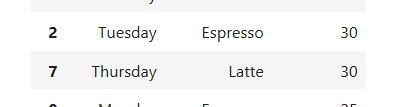

terlihat baris tersebut sama-sama terjual 30, 

namun yang di dahulukan adalah `Coffee Type = Espresso` 

karena tadi kita set **`Coffee Type`** ascending=True` 

---

---

## df.iterrows()

### Iterating over a DataFrame (df) with a For Loop

Lalu, ada cara lain yang sebenarnya tidak terlalu disarankan untuk digunakan banyak kasus, 

tapi terkadang cara ini bisa digunakan untuk melihat data baris per baris dari DataFrame secara detail. 

In [117]:
for index, row in coffee.iterrows():
    print(index)
    print(row)
    print('\n\n\n') # untuk memberi jarak satu baris dengan baris lain

0
Day              Monday
Coffee Type    Espresso
Units Sold           25
Name: 0, dtype: object




1
Day            Monday
Coffee Type     Latte
Units Sold         15
Name: 1, dtype: object




2
Day             Tuesday
Coffee Type    Espresso
Units Sold           30
Name: 2, dtype: object




3
Day            Tuesday
Coffee Type      Latte
Units Sold          20
Name: 3, dtype: object




4
Day            Wednesday
Coffee Type     Espresso
Units Sold            35
Name: 4, dtype: object




5
Day            Wednesday
Coffee Type        Latte
Units Sold            25
Name: 5, dtype: object




6
Day            Thursday
Coffee Type    Espresso
Units Sold           40
Name: 6, dtype: object




7
Day            Thursday
Coffee Type       Latte
Units Sold           30
Name: 7, dtype: object




8
Day              Friday
Coffee Type    Espresso
Units Sold           45
Name: 8, dtype: object




9
Day            Friday
Coffee Type     Latte
Units Sold         35
Name: 9, dtype: object





## Filtering Data

Mari kita masuk ke data yang lebih menarik, dan kita akan mencoba *filtering data*. 

Dan kemungkinan hampir sisa tutorial `Pandas` akan menggunakan Data ini (bios)

In [118]:
bios

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25
...,...,...,...,...,...,...,...,...,...,...
145495,149222,Polina Luchnikova,2002-01-30,Serov,Sverdlovsk,RUS,ROC,167.0,61.0,NaN
145496,149223,Valeriya Merkusheva,1999-09-20,Moskva (Moscow),Moskva,RUS,ROC,168.0,65.0,NaN
145497,149224,Yuliya Smirnova,1998-05-08,Kotlas,Arkhangelsk,RUS,ROC,163.0,55.0,NaN
145498,149225,André Foussard,1899-05-19,Niort,Deux-Sèvres,FRA,France,166.0,NaN,1986-03-18


Jadi kita akan menggunakan data atlet dari `Olympics`. 

Kita lihat terlebih dahulu 5 data teratas : 

In [119]:
bios.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25


Kita lihat 5 data terakhir :

In [120]:
bios.tail()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
145495,149222,Polina Luchnikova,2002-01-30,Serov,Sverdlovsk,RUS,ROC,167.0,61.0,NaN
145496,149223,Valeriya Merkusheva,1999-09-20,Moskva (Moscow),Moskva,RUS,ROC,168.0,65.0,NaN
145497,149224,Yuliya Smirnova,1998-05-08,Kotlas,Arkhangelsk,RUS,ROC,163.0,55.0,NaN
145498,149225,André Foussard,1899-05-19,Niort,Deux-Sèvres,FRA,France,166.0,NaN,1986-03-18
145499,149814,Bill Phillips,1913-07-15,Dulwich Hill,New South Wales,AUS,Australia,NaN,NaN,2003-10-20


Nah kita bakal apain nih data? bakal ngelakuin filtering apa?

Mungkin bisa kita mulai dengan filtering .. tinggi badan (height) deh ya :

In [121]:
bios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145500 entries, 0 to 145499
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   athlete_id    145500 non-null  int64  
 1   name          145500 non-null  object 
 2   born_date     143693 non-null  object 
 3   born_city     110908 non-null  object 
 4   born_region   110908 non-null  object 
 5   born_country  110908 non-null  object 
 6   NOC           145499 non-null  object 
 7   height_cm     106651 non-null  float64
 8   weight_kg     102070 non-null  float64
 9   died_date     33940 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 11.1+ MB


Kita lihat berdasarkan informasi data diatas, jika `height_cm`bertipe data `float` dan tentunya menggunakan satuan *centi meter*. 

Kita bisa coba otak-atik data atlet berdasarkan data angka tadi

### Syntax Options, Numeric Values

Kita ingin filteri **siapa saja atlet yang memiliki tinggi diatas 200 cm?** :

In [122]:
bios.loc[bios["height_cm"] > 200]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
1080,1087,Bozhil Lozanov,1934-08-16,NaN,NaN,NaN,Bulgaria,208.0,133.0,NaN
1673,1680,Alexis Rubalcaba,1972-08-09,Pedro Betancourt,Matanzas,CUB,Cuba,204.0,95.0,NaN
2647,2659,Milan Šrejber,1963-12-30,Praha (Prague),Hlavní město Praha,CZE,Czechoslovakia,203.0,98.0,NaN
2827,2839,Nik'oloz Deriugini,1959-04-30,Kutaisi,Imereti,GEO,Soviet Union,206.0,105.0,NaN
2832,2844,Elşad Qadaşev,1968-05-01,Bakı,Bakı,AZE,Unified Team,205.0,110.0,NaN
...,...,...,...,...,...,...,...,...,...,...
143784,147440,Daniel Miklasevich,1997-07-17,NaN,NaN,NaN,United States,203.0,NaN,NaN
143833,147489,Garrett Muagututia,1988-02-26,NaN,NaN,NaN,United States,205.0,NaN,NaN
143834,147490,Kyle Ensing,1997-03-06,NaN,NaN,NaN,United States,201.0,NaN,NaN
143835,147491,Mitch Stahl,1994-08-31,NaN,NaN,NaN,United States,203.0,NaN,NaN


ternyata dari data tersebut **ada sebanyak 1219 atlet** yang memiliki **tinggi diatas 200**

---

kalo dirasa kolomnya terlalu banyak, kita bisa lakukan seperti ini : 

In [123]:
bios.loc[bios["height_cm"] > 200, ["name", "height_cm"]]

,name,height_cm
1080,Bozhil Lozanov,208.0
1673,Alexis Rubalcaba,204.0
2647,Milan Šrejber,203.0
2827,Nik'oloz Deriugini,206.0
2832,Elşad Qadaşev,205.0
...,...,...
143784,Daniel Miklasevich,203.0
143833,Garrett Muagututia,205.0
143834,Kyle Ensing,201.0
143835,Mitch Stahl,203.0


jadi dari syntax 

```python
bios.loc[bios["height_cm"] > 200, ["name", "height_cm"]]
```

untuk filter berasal dari `bios["height_cm"] > 200` 

dan untuk kolom spesifik yang ingin di tampilkan dengan `, ["name", "height_cm"]`

---

Sebenarnya bisa sih tanpa `.loc`, cukup kaya gini :

```python
df[ df["kolom"] filter ]
```

In [124]:
bios[bios["height_cm"] > 200]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
1080,1087,Bozhil Lozanov,1934-08-16,NaN,NaN,NaN,Bulgaria,208.0,133.0,NaN
1673,1680,Alexis Rubalcaba,1972-08-09,Pedro Betancourt,Matanzas,CUB,Cuba,204.0,95.0,NaN
2647,2659,Milan Šrejber,1963-12-30,Praha (Prague),Hlavní město Praha,CZE,Czechoslovakia,203.0,98.0,NaN
2827,2839,Nik'oloz Deriugini,1959-04-30,Kutaisi,Imereti,GEO,Soviet Union,206.0,105.0,NaN
2832,2844,Elşad Qadaşev,1968-05-01,Bakı,Bakı,AZE,Unified Team,205.0,110.0,NaN
...,...,...,...,...,...,...,...,...,...,...
143784,147440,Daniel Miklasevich,1997-07-17,NaN,NaN,NaN,United States,203.0,NaN,NaN
143833,147489,Garrett Muagututia,1988-02-26,NaN,NaN,NaN,United States,205.0,NaN,NaN
143834,147490,Kyle Ensing,1997-03-06,NaN,NaN,NaN,United States,201.0,NaN,NaN
143835,147491,Mitch Stahl,1994-08-31,NaN,NaN,NaN,United States,203.0,NaN,NaN


---

Lalu kalo pengen munculin beberapa kolom spesifik aja tinggal tambahin :

```python
df[ df["kolom"] filter ]["kolom"]
```



In [125]:
bios[bios["height_cm"] > 200]["name"]

1080          Bozhil Lozanov
1673        Alexis Rubalcaba
2647           Milan Šrejber
2827      Nik'oloz Deriugini
2832           Elşad Qadaşev
                 ...        
143784    Daniel Miklasevich
143833    Garrett Muagututia
143834           Kyle Ensing
143835           Mitch Stahl
143919     Emerson Rodríguez
Name: name, Length: 1219, dtype: object

---

atau kalo kolomnya lebih dari satu, tambahin lagi *bracket*-nya

```python
df[ df["kolom"] filter ][["kolom","kolom"]]
```

In [126]:
bios[bios["height_cm"] > 200][["name", "height_cm"]]

,name,height_cm
1080,Bozhil Lozanov,208.0
1673,Alexis Rubalcaba,204.0
2647,Milan Šrejber,203.0
2827,Nik'oloz Deriugini,206.0
2832,Elşad Qadaşev,205.0
...,...,...
143784,Daniel Miklasevich,203.0
143833,Garrett Muagututia,205.0
143834,Kyle Ensing,201.0
143835,Mitch Stahl,203.0


---

### Multiple Conditions

Lalu bisa ga *filtering*-nya ga cuman satu kondisi? alias *multiple condition*? bisa dong, syntaxnya gini :

```python
df[ (kondisi 1) & (kondisi 2)]

atau 

df[ (df["kolom"] filter ]) & (df["kolom"] filter ]) [["kolom","kolom"]] 
# kita tambahkan tanda kurung ()
```

Kita coba deh **cari atlet yang `tingginya lebih dari 200 cm` dan `lahirnya di Indonesia`**

In [127]:
bios[(bios["height_cm"] > 200) & (bios["born_country"] == "INA")]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
122147,124205,Luke Smith,1990-08-30,Jakarta,Daerah Khusus Ibukota Jakarta,INA,Australia,204.0,95.0,NaN


Woah ternyata ada, tapi bukan orang Indonesia :'v beliau atlet Australia. Well

### String Operations

Contoh diatas kan *filtering* berdasarkan tipe data kolom *float*, nah sekarang kita coba yuk *filtering* data untuk kolom *String*

kita coba cari nama orang yang diawali dengan `Keith`

> case sensitive btw

In [128]:
bios[bios["name"].str.startswith("Keith")]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
1897,1907,Keith Hanlon,1966-09-01,NaN,NaN,NaN,Ireland,NaN,NaN,NaN
3505,3517,Keith Wallace,1961-03-29,Preston,England,GBR,Great Britain,165.0,51.0,1999-12-31
6228,6255,Keith Hartley,1940-10-15,Vancouver,British Columbia,CAN,Canada,200.0,85.0,NaN
8898,8946,Keith Mwila,1966-01-01,NaN,NaN,NaN,Zambia,NaN,NaN,1993-01-09
12053,12118,Keith Hervey,1898-11-03,Fulham,England,GBR,Great Britain,NaN,NaN,1973-02-22
...,...,...,...,...,...,...,...,...,...,...
99921,100722,Keith Carney,1970-02-03,Providence,Rhode Island,USA,United States,188.0,93.0,NaN
102227,103168,Keith Beavers,1983-02-09,London,Ontario,CAN,Canada,185.0,75.0,NaN
109900,111105,Keith Cumberpatch,1927-08-25,Christchurch,Canterbury,NZL,New Zealand,NaN,NaN,2013-11-15
115973,117348,Keith Sanderson,1975-02-02,Plymouth,Massachusetts,USA,United States,183.0,95.0,NaN


berdasarkan hasil diatas ada sebanyak 64 atlet yang memiliki nama depan `Keith`

Sekarang kita ganti kasus, kita pengen cari **siapa aja atlet yang namanya mengandung nama `keith`** baik di depan maupun di belakang namanya :

In [129]:
# ketika keith semua huruf kecil, ga masalah
bios[bios["name"].str.contains("keith", case=False)]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
1897,1907,Keith Hanlon,1966-09-01,NaN,NaN,NaN,Ireland,NaN,NaN,NaN
3505,3517,Keith Wallace,1961-03-29,Preston,England,GBR,Great Britain,165.0,51.0,1999-12-31
6228,6255,Keith Hartley,1940-10-15,Vancouver,British Columbia,CAN,Canada,200.0,85.0,NaN
8898,8946,Keith Mwila,1966-01-01,NaN,NaN,NaN,Zambia,NaN,NaN,1993-01-09
12053,12118,Keith Hervey,1898-11-03,Fulham,England,GBR,Great Britain,NaN,NaN,1973-02-22
...,...,...,...,...,...,...,...,...,...,...
109900,111105,Keith Cumberpatch,1927-08-25,Christchurch,Canterbury,NZL,New Zealand,NaN,NaN,2013-11-15
115973,117348,Keith Sanderson,1975-02-02,Plymouth,Massachusetts,USA,United States,183.0,95.0,NaN
117676,119195,Duncan Keith,1983-07-16,Winnipeg,Manitoba,CAN,Canada,185.0,88.0,NaN
122121,124176,Keith Ferguson,1979-09-07,Sale,Victoria,AUS,Australia,176.0,78.0,NaN


Nambah 6 orang dari sebelumnya 64 orang doang. 

Kita lihat di index ke `117676` ada nama yang mengandung `keith`, lebih tepatnya nama dia `Duncan Keith`

Lalu di index ke-`127310` ada juga `Tracy Keith-Matchitt`

---

Sekarang ganti kasus, kita pengen cari nama atlet yang mengandung nama `keith` atau `patrick`

In [130]:
bios[bios["name"].str.contains("keith|patrick", case=False)]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
6,7,Patrick Chila,1969-11-27,Ris-Orangis,Essonne,FRA,France,180.0,73.0,NaN
119,120,Patrick Wheatley,1899-01-20,Vryheid,KwaZulu-Natal,RSA,Great Britain,NaN,NaN,1967-11-05
319,320,Patrick De Koning,1961-04-23,Dendermonde,Oost-Vlaanderen,BEL,Belgium,178.0,92.0,NaN
1897,1907,Keith Hanlon,1966-09-01,NaN,NaN,NaN,Ireland,NaN,NaN,NaN
2115,2125,Patrick Jopp,1962-01-08,NaN,NaN,NaN,Switzerland,176.0,67.0,NaN
...,...,...,...,...,...,...,...,...,...,...
143975,147633,Patrick Chinyemba,2001-01-03,NaN,NaN,NaN,Zambia,NaN,NaN,NaN
144172,147850,Patrick Jakob,1996-10-17,Sankt Johann in Tirol,Tirol,AUT,Austria,NaN,NaN,NaN
144547,148239,Patrick Galbraith,1986-03-11,Haderslev,Syddanmark,DEN,Denmark,NaN,NaN,NaN
144565,148257,Patrick Russell,1993-01-04,Gentofte,Hovedstaden,DEN,Denmark,186.0,93.0,NaN


tadi sempet `run` ketika `"keith | patrick"` (dipisah) diberi jarak, hasilnya ga jelas. Harus di gabung jadi `"keith|patrick"`

Hasilnya ada sebanyak 303 atlet yang namanya mengandung nama `keith` atau `patrick`. 

ada `Patrick Chila`, `Keith Hanlon`, dan lain-lain.

---

### Regular Expressions (Regex)

Regex (Regular Expression) itu ibarat `"Ctrl+F"` di **software Word*. Dia bisa mencari pola yang rumit, bukan cuma kata yang persis sama.

karena akan sangat sulit untuk dipahami apalagi dihapal, ini saya menggunakan Gemini AI untuk contoh beberapa kasus

#### 1. Mencari Awalan Huruf (Simbol ^)

Simbol `^` (topi) artinya **"Harus dimulai dengan..."**, atau di awali dengan..

Misalnya, **kita mau cari nama atlet yang depannya "Q"** :

In [131]:
bios[bios['name'].str.contains(r'^Q', regex=True)]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
653,656,Qian Qianli,1965-02-07,Qidong,Jiangsu,CHN,Austria,168.0,65.0,NaN
2281,2291,Qiao Hong,1968-11-21,Wuhan,Hubei,CHN,People's Republic of China,162.0,62.0,NaN
2282,2292,Qiao Yunping,1968-09-13,Qingdao,Shandong,CHN,People's Republic of China,162.0,60.0,NaN
2283,2293,Qin Yiyuan,1973-02-14,NaN,NaN,NaN,People's Republic of China,173.0,62.0,NaN
5424,5443,Qiu Chen,1963-06-01,NaN,NaN,NaN,People's Republic of China,181.0,64.0,NaN
...,...,...,...,...,...,...,...,...,...,...
139437,142910,Quentin Delapierre,1992-07-17,Vannes,Morbihan,FRA,France,NaN,NaN,NaN
141827,145408,Quentin Antognelli,1994-08-15,Monaco,Monaco,MON,Monaco,NaN,NaN,NaN
143470,147122,Quanera Hayes,1992-03-07,NaN,NaN,NaN,United States,NaN,NaN,NaN
143471,147123,Quanesha Burks,1995-03-15,Ozark,Alabama,USA,United States,NaN,NaN,NaN


Wah banyak juga ada 108 atlet, kayanya dominan dari Asia.

---

Lalu, *mau cari atlet dengan awalan "Mc" (seperti McDonald, McGregor): `r'^Mc'`* :

In [132]:
bios[bios['name'].str.contains(r'^Mc', regex=True)]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
37083,37378,McAllister Lonnon,1916-04-20,Guildford,England,GBR,Great Britain,NaN,NaN,1999-01-28
68337,68854,McDonald Bailey,1920-12-08,NaN,NaN,NaN,Great Britain,180.0,65.0,2013-12-04
78244,78835,McClinton Neal,1968-07-11,Dallas,Texas,USA,United States,193.0,88.0,NaN
105947,107023,McLain Ward,1975-10-17,Brewster,New York,USA,United States,176.0,70.0,NaN
111734,112979,McWilliams Arroyo,1985-12-05,Ceiba,Puerto Rico,PUR,Puerto Rico,163.0,51.0,NaN
111767,113013,McJoe Arroyo,1985-12-05,Ceiba,Puerto Rico,PUR,Puerto Rico,163.0,54.0,NaN
124461,126764,McKayla Maroney,1995-12-09,Aliso Viejo,California,USA,United States,160.0,46.0,NaN
133458,136397,McQuin Baron,1995-10-27,Laguna Beach,California,USA,United States,206.0,104.0,NaN
135157,138300,McRae Williams,1990-10-23,Salt Lake City,Utah,USA,United States,188.0,79.0,NaN
136585,139812,McKenna Mazlo,2002-03-15,Olney,Maryland,USA,United States,NaN,NaN,NaN


dikit ternyata 

#### 2. Mencari Akhiran Huruf (Simbol `$`)

Simbol `$` (dollar) artinya **"Harus diakhiri dengan..."**. 

Misalnya, kamu mau cari atlet keturunan Skandinavia atau anak laki-laki yang biasanya berakhiran "son" (seperti Ander`son`, John`son`, Peter`son`).

In [133]:
bios[bios['name'].str.contains(r'son$', regex=True, case=False)]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
37,38,Helen Aitchison,1881-12-06,Sunderland,England,GBR,Great Britain,NaN,NaN,1947-05-26
92,93,Anne Gibson,1968-10-26,Dumfries,Scotland,GBR,Great Britain,173.0,70.0,NaN
113,114,Julian Robertson,1969-10-09,Peterborough,England,GBR,Great Britain,182.0,73.0,NaN
120,121,Chris Wilkinson,1970-01-05,Southampton,England,GBR,Great Britain,180.0,72.0,NaN
373,374,Don Jackson,1932-10-25,Lindsay,Ontario,CAN,Canada,178.0,NaN,2009-01-26
...,...,...,...,...,...,...,...,...,...,...
145419,149142,Jake Sanderson,2002-07-08,Whitefish,Montana,USA,United States,NaN,NaN,NaN
145424,149147,Jonathan Gustafson,1997-03-05,Massena,New York,USA,United States,NaN,NaN,NaN
145441,149164,Casey Dawson,2000-08-02,Park City,Utah,USA,United States,NaN,NaN,NaN
145457,149183,Alix Wilkinson,2000-08-02,Mammoth Lakes,California,USA,United States,NaN,NaN,NaN


woah **ada 3550 atlet** yang memiliki akhiran `son` pada namanya.

---

#### 3. Kombinasi Rumit (Huruf Tertentu)

Misalnya kamu iseng mau cari atlet yang inisial namanya dimulai dari huruf **X**, **Y**, atau **Z**. Kita pakai kurung siku `[]` untuk membuat himpunan huruf.

In [134]:
bios[bios['name'].str.contains(r'^[XYZ]', regex=True)]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
83,84,Xinhua Chen,1960-01-30,Fuan,Fujian,CHN,Great Britain,175.0,71.0,NaN
214,215,Zoltán Bátorfi,1975-07-20,Szombathely,Vas,HUN,Hungary,188.0,79.0,NaN
216,217,Zsolt Harczi,1967-02-17,Cegléd,Pest,HUN,Hungary,180.0,72.0,NaN
219,220,Zsolt Kriston,1961-02-12,Miskolc,Borsod-Abaúj-Zemplén,HUN,Hungary,185.0,76.0,NaN
232,233,Yayuk Basuki,1970-11-30,Yogyakarta,Daerah Istimewa Yogyakarta,INA,Indonesia,165.0,55.0,NaN
...,...,...,...,...,...,...,...,...,...,...
145476,149203,Zhen Weijie,2003-10-16,NaN,NaN,NaN,People's Republic of China,NaN,NaN,NaN
145478,149205,Zhao Zihe,2000-07-29,NaN,NaN,NaN,People's Republic of China,NaN,NaN,NaN
145487,149214,Yekaterina Kosova,1996-04-25,Moskva (Moscow),Moskva,RUS,ROC,NaN,NaN,NaN
145489,149216,Ye Jielong,2000-03-02,NaN,NaN,NaN,People's Republic of China,NaN,NaN,NaN


#### 4. Mencari Atlet yang lahir di Kota yang diawali huruf konsonan

In [135]:
bios[bios["born_city"].str.contains(r'^[AIUEOaiueo]', na=False)]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
5,6,Nicolas Chatelain,1970-01-13,Amiens,Somme,FRA,France,181.0,70.0,NaN
10,11,"Élie, Comte de Lastours",1874-08-12,Orgeval,Yvelines,FRA,France,NaN,NaN,1932-11-18
17,18,Jean-Philippe Gatien,1968-10-16,Alès,Gard,FRA,France,178.0,73.0,NaN
35,36,Étienne Thobois,1967-09-20,Amiens,Somme,FRA,France,186.0,78.0,NaN
40,41,Julie Bradbury,1967-02-12,Oxford,England,GBR,Great Britain,175.0,64.0,NaN
...,...,...,...,...,...,...,...,...,...,...
145395,149118,Abbey Murphy,2002-04-14,Evergreen Park,Illinois,USA,United States,NaN,NaN,NaN
145398,149121,Grace Zumwinkle,1999-04-23,Excelsior,Minnesota,USA,United States,NaN,NaN,NaN
145405,149128,Brian Cooper,1993-11-01,Anchorage,Alaska,USA,United States,NaN,NaN,NaN
145418,149141,Nick Perbix,1998-06-15,Elk River,Minnesota,USA,United States,NaN,NaN,NaN


Singkatnya: `na=False` itu artinya **"Kalau datanya kosong (NaN), anggap saja dia TIDAK LULUS seleksi."**

Biar mudah, bayangkan kamu adalah **Satpam Klub "Huruf Vokal"**. Tugasmu menyeleksi tamu berdasarkan kota lahirnya.

###1. Situasi Tanpa `na=False` (Default)Tamu datang satu per satu:

* **Tamu A:** "Saya lahir di **A**mbon." \rightarrow Satpam: "Oke, depannya A (Vokal). Masuk! (**True**)"
* **Tamu B:** "Saya lahir di **J**akarta." \rightarrow Satpam: "Maaf, depannya J (Konsonan). Ditolak! (**False**)"
* **Tamu C:** (Diam saja, datanya kosong/NaN) \rightarrow Satpam: **"Hah? Bingung nih. Kamu masuk atau nggak ya?"**

> Hasilnya: Pandas akan memberikan nilai **`NaN`** (Not a Number).
> Masalahnya: Saat hasil seleksi ini dipakai untuk filter (`bios[...]`), Pandas akan error atau bingung karena dia cuma mengerti `True` atau `False`. Dia tidak bisa memproses "Bingung".

---

###2. Situasi Pakai `na=False`Kamu kasih instruksi tambahan ke Satpam: *"Pak Satpam, kalau ada tamu yang datanya kosong/diam saja, **tolak** saja dia!"*

* **Tamu A:** "Saya lahir di **A**mbon." \rightarrow **True**
* **Tamu B:** "Saya lahir di **J**akarta." \rightarrow **False**
* **Tamu C:** (Data Kosong/NaN) \rightarrow **False** (Langsung dianggap tidak lulus).

> Hasilnya: Semua data jadi jelas statusnya (True/False). Tidak ada yang error.

---

**Tabel PerbandinganMisal kita cari kota berawalan vokal (`^[AIUEO]`).**

| Kota Lahir | Tanpa `na=False` | Pakai `na=False` | Efeknya |
| --- | --- | --- | --- |
| **A**mbon | `True` | `True` | Data Terambil |
| **J**akarta | `False` | `False` | Data Dibuang |
| *(Kosong / NaN)* | **`NaN`** (Error/Bingung) | **`False`** | **Data Dibuang (Aman)** |

###KesimpulanKamu wajib pakai `na=False` kalau kolom data kamu **kotor** (ada data yang bolong/kosong).

Kalau kamu ganti jadi `na=True`, maka semua data yang kosong malah akan **diajak masuk** (dianggap lolos filter). Biasanya sih kita pakai `False` biar data yang diambil benar-benar valid saja.

#### 5. Atlet dengan nama mengandung 2 huruf vokal

In [136]:
bios[bios["name"].str.contains(r'[^AIUEOaiueo]*[AIUEOaiueo] [^AIUEOaiueo]*[AIUEOaiueo] [^AIUEOaiueo]*$', na=False)]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
4655,4671,Ye Swe,1939-07-06,NaN,NaN,NaN,Myanmar,NaN,NaN,NaN
25844,26037,Giovanni De Prà,1900-06-28,Genova (Genoa),Genova,ITA,Italy,NaN,NaN,1979-06-15
143291,146933,Hatice Kübra İlgün,1993-01-01,NaN,NaN,NaN,Türkiye,NaN,NaN,NaN


#### 6. Atlet dengan nama yang memiliki huruf diulang-ulang (`Aa`r`oo`n & E`mm`e`tt`)

In [137]:
bios[bios["name"].str.contains(r'(.)\1', na=False)]

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13252\3403196377.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  bios[bios["name"].str.contains(r'(.)\1', na=False)]


,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
9,10,Guy de la Chapelle,1868-07-16,Farges-Allichamps,Cher,FRA,France,NaN,NaN,1923-08-27
13,14,Étienne Durand,NaN,NaN,NaN,NaN,France,NaN,NaN,NaN
17,18,Jean-Philippe Gatien,1968-10-16,Alès,Gard,FRA,France,178.0,73.0,NaN
20,21,Pierre Hirsch,1900-11-08,Paris Ie,Paris,FRA,France,NaN,NaN,1942-04-19
28,29,Albert Lippmann,NaN,NaN,NaN,NaN,France,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
145474,149201,Nadine Hofstetter,1994-10-21,Romoos,Luzern,SUI,Switzerland,164.0,68.0,NaN
145488,149215,Shakeel John,2001-07-30,Mount Hope,Tunapuna-Piarco,TTO,Trinidad and Tobago,NaN,NaN,NaN
145491,149218,Matthew Wepke,1989-12-05,NaN,NaN,NaN,Jamaica,NaN,NaN,NaN
145498,149225,André Foussard,1899-05-19,Niort,Deux-Sèvres,FRA,France,166.0,NaN,1986-03-18


banyak banget, 
- kaya **Guy de la Chape`ll`e** l-nya double
- **Étie`nn`e Durand**, n-nya double
- dan seterusnya

#### 7. Atlet dengan nama akhir 'son' atau 'sen'

In [138]:
bios[bios["name"].str.contains(r'son$|sen$', case=False, na=False)]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
37,38,Helen Aitchison,1881-12-06,Sunderland,England,GBR,Great Britain,NaN,NaN,1947-05-26
92,93,Anne Gibson,1968-10-26,Dumfries,Scotland,GBR,Great Britain,173.0,70.0,NaN
107,108,Anders Nielsen,1967-02-24,Cape Town,Western Cape,RSA,Great Britain,173.0,70.0,2010-07-29
113,114,Julian Robertson,1969-10-09,Peterborough,England,GBR,Great Britain,182.0,73.0,NaN
120,121,Chris Wilkinson,1970-01-05,Southampton,England,GBR,Great Britain,180.0,72.0,NaN
...,...,...,...,...,...,...,...,...,...,...
145419,149142,Jake Sanderson,2002-07-08,Whitefish,Montana,USA,United States,NaN,NaN,NaN
145424,149147,Jonathan Gustafson,1997-03-05,Massena,New York,USA,United States,NaN,NaN,NaN
145441,149164,Casey Dawson,2000-08-02,Park City,Utah,USA,United States,NaN,NaN,NaN
145457,149183,Alix Wilkinson,2000-08-02,Mammoth Lakes,California,USA,United States,NaN,NaN,NaN


#### 8. Atlet yang lahir pada tahun angka awalan '19' (1970, 1990, dll)

In [139]:
bios[bios["born_date"].str.contains(r'^19', na=False)]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
5,6,Nicolas Chatelain,1970-01-13,Amiens,Somme,FRA,France,181.0,70.0,NaN
6,7,Patrick Chila,1969-11-27,Ris-Orangis,Essonne,FRA,France,180.0,73.0,NaN
7,8,Henri Cochet,1901-12-14,Villeurbanne,Rhône,FRA,France,NaN,NaN,1987-04-02
14,15,Damien Éloi,1969-07-04,Vire,Calvados,FRA,France,165.0,58.0,NaN
...,...,...,...,...,...,...,...,...,...,...
145492,149219,Carlos García-Ordóñez,1927-04-24,La Habana (Havana),Ciudad de La Habana,CUB,Cuba,NaN,NaN,2019-11-24
145493,149220,Landysh Falyakhova,1998-08-31,Dva Polya Artash,Respublika Tatarstan,RUS,ROC,NaN,NaN,NaN
145496,149223,Valeriya Merkusheva,1999-09-20,Moskva (Moscow),Moskva,RUS,ROC,168.0,65.0,NaN
145497,149224,Yuliya Smirnova,1998-05-08,Kotlas,Arkhangelsk,RUS,ROC,163.0,55.0,NaN


#### 9. Atlet yang namanya tidak ada sama sekali huruf vokal

In [140]:
bios[bios["name"].str.contains(r'^[^AIUEOaiueo]*$', na=False)]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
3818,3831,György Pál,1939-03-29,Budapest,Budapest,HUN,Hungary,178.0,64.0,NaN
3831,3844,László Szűcs,1969-10-27,Sajószentpéter,Borsod-Abaúj-Zemplén,HUN,Hungary,176.0,64.0,NaN
5125,5144,Zézé,1966-04-30,Santa Rita do Passa Quatro,São Paulo,BRA,Brazil,190.0,NaN,NaN
5764,5787,Bráz,1920-11-25,São Paulo,São Paulo,BRA,Brazil,NaN,NaN,1996-09-11
6260,6288,László Hódy,1934-07-10,Szeged,Csongrád,HUN,Australia Hungary,192.0,84.0,2023-05-26
15165,15267,Lê Văn Phươc,1929-10-15,NaN,NaN,NaN,South Vietnam,NaN,NaN,NaN
21621,21774,Céré,NaN,NaN,NaN,NaN,France,NaN,NaN,NaN
22252,22420,Árpád Bárány,1931-06-24,Budapest,Budapest,HUN,Hungary,171.0,59.0,NaN
22367,22535,László Széchy,1891-11-18,Arad,Arad,ROU,Hungary,NaN,NaN,1963-12-09
25578,25770,Kálmán Tóth,1944-08-13,Szombathely,Vas,HUN,Hungary,170.0,65.0,NaN


Kalo ini sih itungannya masih ada huruf konsonan ya

#### 10. Atlet dengan nama mengandung tanda baca sambung atau kutip

In [141]:
bios[bios["name"].str.contains(r"[-']", na=False)]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
15,16,Adrien Fauchier-Magnan,1873-11-19,Paris VIIIe,Paris,FRA,France,NaN,NaN,1965-08-06
17,18,Jean-Philippe Gatien,1968-10-16,Alès,Gard,FRA,France,178.0,73.0,NaN
33,34,Jean-Pierre Samazeuilh,1891-01-17,Bordeaux,Gironde,FRA,France,NaN,NaN,1965-04-13
36,37,Pierre Verdé-Delisle,1877-05-16,Trie-la-Ville,Oise,FRA,France,NaN,NaN,1960-07-18
...,...,...,...,...,...,...,...,...,...,...
145385,149108,Ashley Cain-Gribble,1995-07-22,Dallas,Texas,USA,United States,NaN,NaN,NaN
145388,149111,Jean-Luc Baker,1993-10-07,Burnley,England,GBR,United States,NaN,NaN,NaN
145470,149197,Lee Chae-Eun,2006-04-11,NaN,NaN,NaN,Republic of Korea,NaN,NaN,NaN
145490,149217,Sin Ye-Chan,1995-06-13,NaN,NaN,NaN,Republic of Korea,NaN,NaN,NaN


#### 11. Mencari Atlet dengan nama huruf awal dan akhir sama

In [142]:
bios[bios["name"].str.contains(r"^(.).*\1$", na=False)]

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13252\1198448826.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  bios[bios["name"].str.contains(r"^(.).*\1$", na=False)]


,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date


Untuk contoh lain mungkin bisa cari di Google atau tanya langsung ke AI ya! lieur ey

---

---

### .isin()

kalo pengen filtering lebih dari satu data, 

semisal **atlet yang lahirnya di USA** (Amerika Serikat) **atau FRA** (Prancis) : 

In [143]:
bios[bios["born_country"].isin(["USA", "FRA"])]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
5,6,Nicolas Chatelain,1970-01-13,Amiens,Somme,FRA,France,181.0,70.0,NaN
...,...,...,...,...,...,...,...,...,...,...
145454,149180,Anna Hoffmann,2000-03-28,Madison,Wisconsin,USA,United States,NaN,NaN,NaN
145457,149183,Alix Wilkinson,2000-08-02,Mammoth Lakes,California,USA,United States,NaN,NaN,NaN
145467,149194,Elisa Nakab,1998-05-08,Briançon,Hautes-Alpes,FRA,Italy,NaN,NaN,NaN
145468,149195,Justin Abdelkader,1987-02-25,Muskegon,Michigan,USA,United States,187.0,97.0,NaN


hasilnya ada 147 ribuan atlet

Tentu kita bisa kombinasikan juga dengan kondisi lain seperti multiple filtering 

semisal yang lahir di USA atau FRA, tapi namanya mengandung `keith` :

In [144]:
bios[(bios["born_country"].isin(["USA", "FRA"])) & (bios["name"].str.contains("Keith"))]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
50929,51288,Keith Carter,1924-08-30,Akron,Ohio,USA,United States,NaN,NaN,2013-05-03
51185,51544,Keith Russell,1948-01-15,Mesa,Arizona,USA,United States,188.0,73.0,NaN
52913,53288,Keith Erickson,1944-04-19,San Francisco,California,USA,United States,196.0,86.0,NaN
62678,63144,Keith Notary,1960-01-22,Merritt Island,Florida,USA,United States,170.0,66.0,NaN
77550,78141,Keith Brantly,1962-05-23,Scott Air Force Base,Illinois,USA,United States,180.0,64.0,NaN
84097,84766,Keith Christiansen,1944-07-14,International Falls,Minnesota,USA,United States,165.0,69.0,2018-11-05
94646,95413,Keith Meyer,1938-06-20,Geneva,Illinois,USA,United States,NaN,NaN,2010-07-25
97499,98286,Keith Tkachuk,1972-03-28,Melrose,Massachusetts,USA,United States,188.0,102.0,NaN
98068,98860,Keith Wegeman,1929-08-28,Denver,Colorado,USA,United States,NaN,NaN,1974-08-22
99921,100722,Keith Carney,1970-02-03,Providence,Rhode Island,USA,United States,188.0,93.0,NaN


ya lumayan banyak

---



### Query Functions

kalo kita lihat syntax diatas 

```python
bios[(bios["born_country"].isin(["USA", "FRA"])) & (bios["name"].str.contains("Keith"))]
```

terlihat panjang dan *njilimet*, **tulisan `bios` bisa muncul 3x dalam satu baris**. 

bisa kita persingkat dengan keren dengan **.query**.

jadi cukup :

```python
df.query(condition ... condition)
```

Semisal atlet yang lahir di Indonesia :

In [145]:
bios.query('born_country == "INA"')

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
232,233,Yayuk Basuki,1970-11-30,Yogyakarta,Daerah Istimewa Yogyakarta,INA,Indonesia,165.0,55.0,NaN
233,234,Rossy Pratiwi Dipoyanti,1972-06-28,Bandung,Jawa Barat,INA,Indonesia,NaN,NaN,NaN
234,235,Finarsih,1972-02-08,Sleman,Jawa Tengah,INA,Indonesia,NaN,NaN,NaN
235,236,Ling Ling Agustin,1969-08-23,Kediri,Jawa Timur,INA,Indonesia,NaN,NaN,NaN
238,239,Zelin Resiana,1972-07-09,Magelang,Jawa Tengah,INA,Indonesia,169.0,58.0,NaN
...,...,...,...,...,...,...,...,...,...,...
140211,143712,Jonatan Christie,1997-09-15,Jakarta,Daerah Khusus Ibukota Jakarta,INA,Indonesia,NaN,NaN,NaN
140212,143713,Kevin Sanjaya Sukamuljo,1995-08-02,Banyuwangi,Jawa Timur,INA,Indonesia,NaN,NaN,NaN
140213,143714,Marcus Fernaldi Gideon,1991-03-09,Jakarta,Daerah Khusus Ibukota Jakarta,INA,Indonesia,NaN,NaN,NaN
140215,143716,Aflah Prawira,1997-11-13,Cirebon,Jawa Barat,INA,Indonesia,NaN,NaN,NaN


Atlet yang lahir di `Indonesia` dan Kota `Jakarta` :

In [146]:
bios.query('born_country == "INA" & born_city == "Jakarta"')

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
247,248,Mia Audina,1979-08-22,Jakarta,Daerah Khusus Ibukota Jakarta,INA,Indonesia Netherlands,163.0,67.0,NaN
248,249,Suzanna Wibowo,1963-11-25,Jakarta,Daerah Khusus Ibukota Jakarta,INA,Indonesia,NaN,NaN,NaN
265,266,Donald Wailan Walalangi,1960-04-14,Jakarta,Daerah Khusus Ibukota Jakarta,INA,Indonesia,174.0,67.0,NaN
267,268,Ardy Wiranata,1970-02-10,Jakarta,Daerah Khusus Ibukota Jakarta,INA,Indonesia,171.0,67.0,NaN
1881,1891,Nurfitriyana Saiman-Lantang,1962-03-07,Jakarta,Daerah Khusus Ibukota Jakarta,INA,Indonesia,159.0,51.0,NaN
...,...,...,...,...,...,...,...,...,...,...
128031,130532,Dewi Yuliawati,1997-06-02,Jakarta,Daerah Khusus Ibukota Jakarta,INA,Indonesia,166.0,65.0,NaN
131601,134409,Tommy Sugiarto,1988-05-31,Jakarta,Daerah Khusus Ibukota Jakarta,INA,Indonesia,175.0,71.0,NaN
134943,138063,Rafael Kreienbühl,1999-06-10,Jakarta,Daerah Khusus Ibukota Jakarta,INA,Switzerland,171.0,NaN,NaN
140211,143712,Jonatan Christie,1997-09-15,Jakarta,Daerah Khusus Ibukota Jakarta,INA,Indonesia,NaN,NaN,NaN


tapi ya **kelemahan dari `.query`** ini adalah, kita **harus hafal nama kolom dan sangat *case sensitive***

---

## Adding / Removing Columns 1

### Basics Add Columns

Pertama, liat ini dulu : 

In [161]:
coffee.head()

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35


Kolomnya masih ada 3,, hanya ada `Day`, `Coffee Type` dan `Units Sold`

Kita bisa melakukan beberapa hal berbeda disini, 

**anggep aja kita mau buat semacam kolom harga baru bernama `Price`**. 

*Kita bisa set diharga yang sama dulu*

In [162]:
coffee["Price"] = 4.99

kita cek lagi hasilnya : 

In [163]:
coffee

,Day,Coffee Type,Units Sold,Price
0,Monday,Espresso,25,4.99
1,Monday,Latte,15,4.99
2,Tuesday,Espresso,30,4.99
3,Tuesday,Latte,20,4.99
4,Wednesday,Espresso,35,4.99
5,Wednesday,Latte,25,4.99
6,Thursday,Espresso,40,4.99
7,Thursday,Latte,30,4.99
8,Friday,Espresso,45,4.99
9,Friday,Latte,35,4.99


Dan sekarang kita lihat udah ada kolom baru dengan nama **`Price`**

---

### Conditional Values

Nah tapi kan ga mungkin nih semua harga kopi sama, 

nah caranya *gimana nih biar kita bedakan dan masukan harga lebih spesifik?* 

Anggaplah satu harga untuk `Espresso`, satu harga berbeda untuk `Latte`?

**Kita bisa gunakan bantuan dari Numpy**

In [164]:
import numpy as np

coffee["New Price"] = np.where(coffee["Coffee Type"]== "Espresso", 3.99, 5.99)
                    # dimana kalo kopi = espresso, kasih harga 3.99, yang lain 5.99

In [165]:
coffee

,Day,Coffee Type,Units Sold,Price,New Price
0,Monday,Espresso,25,4.99,3.99
1,Monday,Latte,15,4.99,5.99
2,Tuesday,Espresso,30,4.99,3.99
3,Tuesday,Latte,20,4.99,5.99
4,Wednesday,Espresso,35,4.99,3.99
5,Wednesday,Latte,25,4.99,5.99
6,Thursday,Espresso,40,4.99,3.99
7,Thursday,Latte,30,4.99,5.99
8,Friday,Espresso,45,4.99,3.99
9,Friday,Latte,35,4.99,5.99


Untuk jenis kopi `Espresso` harganya `3.99`, sedangkan yang lain `5.99`

---

### Basic Removing Columns

Nah berhasil. Tapi sekarang malah jadi ada 2 harga berbeda : `Price` dan `New Price`. **Bagaimana caranya kita hapus salah satu kolom?**

Tapi sebelum hapus kolom, kita bisa hapus suatu baris data menggunakan `df.drop(.. index ..)`

In [166]:
coffee.drop(0)

,Day,Coffee Type,Units Sold,Price,New Price
1,Monday,Latte,15,4.99,5.99
2,Tuesday,Espresso,30,4.99,3.99
3,Tuesday,Latte,20,4.99,5.99
4,Wednesday,Espresso,35,4.99,3.99
5,Wednesday,Latte,25,4.99,5.99
6,Thursday,Espresso,40,4.99,3.99
7,Thursday,Latte,30,4.99,5.99
8,Friday,Espresso,45,4.99,3.99
9,Friday,Latte,35,4.99,5.99
10,Saturday,Espresso,45,4.99,3.99


Nah tapi yang aneh disini adalah, kalo kita cek lagi 

In [167]:
coffee

,Day,Coffee Type,Units Sold,Price,New Price
0,Monday,Espresso,25,4.99,3.99
1,Monday,Latte,15,4.99,5.99
2,Tuesday,Espresso,30,4.99,3.99
3,Tuesday,Latte,20,4.99,5.99
4,Wednesday,Espresso,35,4.99,3.99
5,Wednesday,Latte,25,4.99,5.99
6,Thursday,Espresso,40,4.99,3.99
7,Thursday,Latte,30,4.99,5.99
8,Friday,Espresso,45,4.99,3.99
9,Friday,Latte,35,4.99,5.99


index 0 masih ada! padahal diatas kita udah drop(0) 

terus gimana dong biar ke-hapus beneran?

---

#### inplace=True

kita bisa tambahkan syntax `inplace=True`. 

Kita ulang ya

In [168]:
coffee.drop(0, inplace=True)

kita cek lagi, apakah index 0 sudah hilang?

In [169]:
coffee

,Day,Coffee Type,Units Sold,Price,New Price
1,Monday,Latte,15,4.99,5.99
2,Tuesday,Espresso,30,4.99,3.99
3,Tuesday,Latte,20,4.99,5.99
4,Wednesday,Espresso,35,4.99,3.99
5,Wednesday,Latte,25,4.99,5.99
6,Thursday,Espresso,40,4.99,3.99
7,Thursday,Latte,30,4.99,5.99
8,Friday,Espresso,45,4.99,3.99
9,Friday,Latte,35,4.99,5.99
10,Saturday,Espresso,45,4.99,3.99


setelah menambah `inplace=True`, index 0 sudah hilang

#### Cara lain

Selain menggunakan `inplace=True`. Kita juga bisa panggil kembali variable `coffee = `

Sehingga bentunya seperti ini :

```python
coffee = coffee.drop(0)
```

cara kedua seperti diatas, menggunakan `inplace=True`

```python
coffee.drop(0, inplace=True)
```

---

nah baru ilang. Kalo mau ngapus kolom gimana?
caranya sedikit berbeda, kita perlu menambahkan `columns="nama kolom"` :

```python
df.drop(columns="Nama kolom")
```

Semisal kita ingin menghapus kolom `Price`

In [170]:
coffee.drop(columns="Price")

,Day,Coffee Type,Units Sold,New Price
1,Monday,Latte,15,5.99
2,Tuesday,Espresso,30,3.99
3,Tuesday,Latte,20,5.99
4,Wednesday,Espresso,35,3.99
5,Wednesday,Latte,25,5.99
6,Thursday,Espresso,40,3.99
7,Thursday,Latte,30,5.99
8,Friday,Espresso,45,3.99
9,Friday,Latte,35,5.99
10,Saturday,Espresso,45,3.99


kita cek lagi wkwk, harusnya belum ilang

karena kita ga kasih syntax `inplace=True` atau simpan dalam variable

In [171]:
coffee

,Day,Coffee Type,Units Sold,Price,New Price
1,Monday,Latte,15,4.99,5.99
2,Tuesday,Espresso,30,4.99,3.99
3,Tuesday,Latte,20,4.99,5.99
4,Wednesday,Espresso,35,4.99,3.99
5,Wednesday,Latte,25,4.99,5.99
6,Thursday,Espresso,40,4.99,3.99
7,Thursday,Latte,30,4.99,5.99
8,Friday,Espresso,45,4.99,3.99
9,Friday,Latte,35,4.99,5.99
10,Saturday,Espresso,45,4.99,3.99


tuh kan, jadi kita perlu menambahkan `inplace=True`. 

**Tapi inget, gunakan `inplace=True` kalo udah bener-bener yakin mau hapus**

In [172]:
coffee.drop(columns="Price", inplace=True)

In [173]:
coffee

,Day,Coffee Type,Units Sold,New Price
1,Monday,Latte,15,5.99
2,Tuesday,Espresso,30,3.99
3,Tuesday,Latte,20,5.99
4,Wednesday,Espresso,35,3.99
5,Wednesday,Latte,25,5.99
6,Thursday,Espresso,40,3.99
7,Thursday,Latte,30,5.99
8,Friday,Espresso,45,3.99
9,Friday,Latte,35,5.99
10,Saturday,Espresso,45,3.99


---

### .copy()

Ada satu hal yang harus kalian lihat, ada kaitanya sama memory sementara dari Python bekerja.

In [174]:
coffee = pd.read_csv("./warm-up data/coffee.csv")

In [175]:
coffee

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35
5,Wednesday,Latte,25
6,Thursday,Espresso,40
7,Thursday,Latte,30
8,Friday,Espresso,45
9,Friday,Latte,35


Jadi, **kita bisa buat *DataFrame* baru** menggunakan *DataFrame* yang sudah ada, semisal gini deh 

Kita membuat variable baru bernama `coffee_new` yang datanya diambil dari `coffee`

In [176]:
coffee_new = coffee

In [177]:
coffee_new

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35
5,Wednesday,Latte,25
6,Thursday,Espresso,40
7,Thursday,Latte,30
8,Friday,Espresso,45
9,Friday,Latte,35


Anggaplah kita mau nambah kolom `Price` di DataFrame baru `coffee_new` 

In [178]:
coffee_new["Price"] = 4.99

In [179]:
coffee_new

,Day,Coffee Type,Units Sold,Price
0,Monday,Espresso,25,4.99
1,Monday,Latte,15,4.99
2,Tuesday,Espresso,30,4.99
3,Tuesday,Latte,20,4.99
4,Wednesday,Espresso,35,4.99
5,Wednesday,Latte,25,4.99
6,Thursday,Espresso,40,4.99
7,Thursday,Latte,30,4.99
8,Friday,Espresso,45,4.99
9,Friday,Latte,35,4.99


Tapiii...! kalo kita cek di *DataFrame* lama `Coffee` (tanpa **`_new`**). Ternyata ikut berubah :

Padahal **kita niatnya hanya mengubah isi *DataFrame* pada variable `coffee_new`**, tapi **data pada variable `coffee` ikut berubah**

In [180]:
coffee

,Day,Coffee Type,Units Sold,Price
0,Monday,Espresso,25,4.99
1,Monday,Latte,15,4.99
2,Tuesday,Espresso,30,4.99
3,Tuesday,Latte,20,4.99
4,Wednesday,Espresso,35,4.99
5,Wednesday,Latte,25,4.99
6,Thursday,Espresso,40,4.99
7,Thursday,Latte,30,4.99
8,Friday,Espresso,45,4.99
9,Friday,Latte,35,4.99


Coba scroll ke atas lagi ^ . Tadi kita nambahin kolom baru di DataFrame `coffee_new` kan? tapi pas kita cek di `coffee` kolom `Price` juga ngikut.

Nah ini sebenernya, inilah `Pandas Python` menyimpan memory. Jadi kalo ada :

```python
data_frame_new = data_frame
```

**itu sama aja cuman kaya copy alamat memory yang sama, cuman beda nama DataFrame**

Nah biar ga kejadian kaya gitu gimana? 

> **kita perlu menambahkan syntax `.copy`**

kita load ulang deh dataset-nya

In [181]:
coffee = pd.read_csv('./warm-up data/coffee.csv')
coffee

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35
5,Wednesday,Latte,25
6,Thursday,Espresso,40
7,Thursday,Latte,30
8,Friday,Espresso,45
9,Friday,Latte,35


In [182]:
# tambahkan .copy()
coffee_new = coffee.copy()

# kita ubah harga pada kolom price data coffee_new menjadi 4.99
coffee_new['Price'] = 4.99

In [183]:
coffee_new

,Day,Coffee Type,Units Sold,Price
0,Monday,Espresso,25,4.99
1,Monday,Latte,15,4.99
2,Tuesday,Espresso,30,4.99
3,Tuesday,Latte,20,4.99
4,Wednesday,Espresso,35,4.99
5,Wednesday,Latte,25,4.99
6,Thursday,Espresso,40,4.99
7,Thursday,Latte,30,4.99
8,Friday,Espresso,45,4.99
9,Friday,Latte,35,4.99


Nah seharusnya DataFrame **`coffee` udah ga ngikut berubah**

In [184]:
coffee

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35
5,Wednesday,Latte,25
6,Thursday,Espresso,40
7,Thursday,Latte,30
8,Friday,Espresso,45
9,Friday,Latte,35


Nahh..

---

### Math Operations

Kali ini kita coba untuk melakukan operasi matematika sederhana di DataFrame, anggaplah kita ingin membuat kolom `Revenue`. Jadi `Revenue` itu adalah $Harga \times Total  Penjualan$

In [185]:
coffee

,Day,Coffee Type,Units Sold
0,Monday,Espresso,25
1,Monday,Latte,15
2,Tuesday,Espresso,30
3,Tuesday,Latte,20
4,Wednesday,Espresso,35
5,Wednesday,Latte,25
6,Thursday,Espresso,40
7,Thursday,Latte,30
8,Friday,Espresso,45
9,Friday,Latte,35


kita tambahin dulu deh harganya, kita copy syntax diatas

In [186]:
coffee['Price'] = 4.99

In [187]:
coffee

,Day,Coffee Type,Units Sold,Price
0,Monday,Espresso,25,4.99
1,Monday,Latte,15,4.99
2,Tuesday,Espresso,30,4.99
3,Tuesday,Latte,20,4.99
4,Wednesday,Espresso,35,4.99
5,Wednesday,Latte,25,4.99
6,Thursday,Espresso,40,4.99
7,Thursday,Latte,30,4.99
8,Friday,Espresso,45,4.99
9,Friday,Latte,35,4.99


In [188]:
coffee["New Price"] = np.where(coffee["Coffee Type"]== "Espresso", 3.99, 5.99)
                    # dimana kalo kopi = espresso, kasih harga 3.99, yang lain 5.99

In [189]:
coffee

,Day,Coffee Type,Units Sold,Price,New Price
0,Monday,Espresso,25,4.99,3.99
1,Monday,Latte,15,4.99,5.99
2,Tuesday,Espresso,30,4.99,3.99
3,Tuesday,Latte,20,4.99,5.99
4,Wednesday,Espresso,35,4.99,3.99
5,Wednesday,Latte,25,4.99,5.99
6,Thursday,Espresso,40,4.99,3.99
7,Thursday,Latte,30,4.99,5.99
8,Friday,Espresso,45,4.99,3.99
9,Friday,Latte,35,4.99,5.99


hmm.. kita hapus aja deh kolom `Price`. Kita gunakan kolom `New Price` saja

In [190]:
coffee.drop(columns='Price', inplace=True)

In [191]:
coffee

,Day,Coffee Type,Units Sold,New Price
0,Monday,Espresso,25,3.99
1,Monday,Latte,15,5.99
2,Tuesday,Espresso,30,3.99
3,Tuesday,Latte,20,5.99
4,Wednesday,Espresso,35,3.99
5,Wednesday,Latte,25,5.99
6,Thursday,Espresso,40,3.99
7,Thursday,Latte,30,5.99
8,Friday,Espresso,45,3.99
9,Friday,Latte,35,5.99


Nah disini kita baru bisa nambahin matematika sederhana. Udah di sebut diatas, `Revenue` itu dari $New Price \times Units Sold$

In [192]:
coffee['Revenue'] = coffee["Units Sold"] * coffee["New Price"]

In [193]:
coffee

,Day,Coffee Type,Units Sold,New Price,Revenue
0,Monday,Espresso,25,3.99,99.75
1,Monday,Latte,15,5.99,89.85
2,Tuesday,Espresso,30,3.99,119.70
3,Tuesday,Latte,20,5.99,119.80
4,Wednesday,Espresso,35,3.99,139.65
5,Wednesday,Latte,25,5.99,149.75
6,Thursday,Espresso,40,3.99,159.60
7,Thursday,Latte,30,5.99,179.70
8,Friday,Espresso,45,3.99,179.55
9,Friday,Latte,35,5.99,209.65


sudah ada kolom baru di paling kanan, kolom `Revenue` yang mendapat angka dari angka pada kolom `Units Sold` dan `New Price`

sebagai contoh revenue pada index ke-0, 99.75

didapat dari $25 \times 3.99 = 99.75$

---

### Rename Columns

Ada kemungkinan besar, kita pasti akan mengganti nama kolom karena kebutuhan (mudah dibaca, mudah diingat, dll)

Cara menggantinya cukup mudah, gunakan `.rename` lalu buat *dictionary* di dalamnya :

```python
df.rename(columns={'old_columns_name' : 'new_columns_name'}
```

> **dan ingat untuk menyimpan bisa menggunakan 2 cara** :

**Cara 1 :**

```python
df = df.rename(columns={'old_columns_name' : 'new_columns_name'})
```

**Cara 2** :

```python
df.rename(columns={'old_columns_name' : 'new_columns_name'}, inplace=True)
```

In [194]:
coffee.rename(columns={'New Price' : 'Price'}, inplace=True)

In [195]:
coffee

,Day,Coffee Type,Units Sold,Price,Revenue
0,Monday,Espresso,25,3.99,99.75
1,Monday,Latte,15,5.99,89.85
2,Tuesday,Espresso,30,3.99,119.70
3,Tuesday,Latte,20,5.99,119.80
4,Wednesday,Espresso,35,3.99,139.65
5,Wednesday,Latte,25,5.99,149.75
6,Thursday,Espresso,40,3.99,159.60
7,Thursday,Latte,30,5.99,179.70
8,Friday,Espresso,45,3.99,179.55
9,Friday,Latte,35,5.99,209.65


---

## Adding / Removing Columns 2

### String Operation

Beberapa hal lain yang mungkin ingin kita lihat. 

Kita pindah dulu ke data `bios`

In [196]:
bios.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25


Disini kita tahu data ini adalah data **Atlet Olympic** dan banyak kolom yang bisa kita gunakan untuk mengambil informasi. 

*Hmm.. mungkin **kita coba dengan mengambil nama depan** deh*. 

*Atau mungkin kita bisa ambil tahun dari tanggal lahir atlet* (`born_date`)

#### first_name

kita coba dulu kali ya, ambil nama depannya aja dari kolom `name`. 

Mungkin biar ga bolak-balik nanti read csv, kita `.copy` aja `bios` ke `bios_new`.

In [197]:
bios_new = bios.copy()

In [198]:
bios_new

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25
...,...,...,...,...,...,...,...,...,...,...
145495,149222,Polina Luchnikova,2002-01-30,Serov,Sverdlovsk,RUS,ROC,167.0,61.0,NaN
145496,149223,Valeriya Merkusheva,1999-09-20,Moskva (Moscow),Moskva,RUS,ROC,168.0,65.0,NaN
145497,149224,Yuliya Smirnova,1998-05-08,Kotlas,Arkhangelsk,RUS,ROC,163.0,55.0,NaN
145498,149225,André Foussard,1899-05-19,Niort,Deux-Sèvres,FRA,France,166.0,NaN,1986-03-18


semisal kita ingin membuat kolom baru bernama `Nama Depan` yang didapat dari kolom `name` dengan batas sebuah spasi :

In [199]:
bios_new['Nama Depan'] = bios_new['name'].str.split(' ').str[0]
# buat kolom baru 'Nama Depan' = ambil dari kolom 'name' ubah jadi string, split kalo ada spasi (' ') lalu ambil kata pertama (index 0)

In [200]:
bios_new

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,Nama Depan
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,Jean-François
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,Arnaud
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,Jean
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,Jacques
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,Albert
...,...,...,...,...,...,...,...,...,...,...,...
145495,149222,Polina Luchnikova,2002-01-30,Serov,Sverdlovsk,RUS,ROC,167.0,61.0,NaN,Polina
145496,149223,Valeriya Merkusheva,1999-09-20,Moskva (Moscow),Moskva,RUS,ROC,168.0,65.0,NaN,Valeriya
145497,149224,Yuliya Smirnova,1998-05-08,Kotlas,Arkhangelsk,RUS,ROC,163.0,55.0,NaN,Yuliya
145498,149225,André Foussard,1899-05-19,Niort,Deux-Sèvres,FRA,France,166.0,NaN,1986-03-18,André


kalo kalian cek kolom paling kanan -> ada kolom baru `Nama Depan`. 

kita ganti nama kolom tersebut jadi `first_name` biar semua nama kolom dalam bahasa inggris

In [201]:
bios_new = bios_new.rename(columns={'Nama Depan' : 'first_name'})

In [202]:
bios_new.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,first_name
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,Jean-François
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,Arnaud
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,Jean
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,Jacques
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,Albert


kita cek lagi

In [203]:
bios_new['first_name']

0         Jean-François
1                Arnaud
2                  Jean
3               Jacques
4                Albert
              ...      
145495           Polina
145496         Valeriya
145497           Yuliya
145498            André
145499             Bill
Name: first_name, Length: 145500, dtype: object

---

kita juga bisa melakukan operasi pada kolom baru tersebut :

In [204]:
bios_new.query('first_name == "Keith"')

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,first_name
1897,1907,Keith Hanlon,1966-09-01,NaN,NaN,NaN,Ireland,NaN,NaN,NaN,Keith
3505,3517,Keith Wallace,1961-03-29,Preston,England,GBR,Great Britain,165.0,51.0,1999-12-31,Keith
6228,6255,Keith Hartley,1940-10-15,Vancouver,British Columbia,CAN,Canada,200.0,85.0,NaN,Keith
8898,8946,Keith Mwila,1966-01-01,NaN,NaN,NaN,Zambia,NaN,NaN,1993-01-09,Keith
12053,12118,Keith Hervey,1898-11-03,Fulham,England,GBR,Great Britain,NaN,NaN,1973-02-22,Keith
...,...,...,...,...,...,...,...,...,...,...,...
99921,100722,Keith Carney,1970-02-03,Providence,Rhode Island,USA,United States,188.0,93.0,NaN,Keith
102227,103168,Keith Beavers,1983-02-09,London,Ontario,CAN,Canada,185.0,75.0,NaN,Keith
109900,111105,Keith Cumberpatch,1927-08-25,Christchurch,Canterbury,NZL,New Zealand,NaN,NaN,2013-11-15,Keith
115973,117348,Keith Sanderson,1975-02-02,Plymouth,Massachusetts,USA,United States,183.0,95.0,NaN,Keith


---

#### last_name

Biar sambil ngasah kemampuan Pandas, kita coba juga ambil nama terakhir

In [205]:
bios_new['last_name'] = bios_new['name'].str.split(' ').str[-1] # ambil nama pada paling akhir (index -1) yang dipisah spasi

In [206]:
bios_new.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,first_name,last_name
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,Jean-François,Blanchy
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,Arnaud,Boetsch
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,Jean,Borotra
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,Jacques,Brugnon
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,Albert,Canet


Berhasil yeay!

---

### Datetime (pd.to_datetime) Operations

Kolom lain yang bisa kita tambahkan adalah mungkin.. 

> **menambah kolom tahun kelahiran dari atlet.**

kita cek dulu deh tipe data dari kolom `born_date`

In [207]:
bios_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145500 entries, 0 to 145499
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   athlete_id    145500 non-null  int64  
 1   name          145500 non-null  object 
 2   born_date     143693 non-null  object 
 3   born_city     110908 non-null  object 
 4   born_region   110908 non-null  object 
 5   born_country  110908 non-null  object 
 6   NOC           145499 non-null  object 
 7   height_cm     106651 non-null  float64
 8   weight_kg     102070 non-null  float64
 9   died_date     33940 non-null   object 
 10  first_name    145500 non-null  object 
 11  last_name     145500 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 13.3+ MB


bisa di cek pada index ke-2 tipe data `born_date` masih `object`. 

Untuk bekerja menggunakan tanggal format kaya gini :

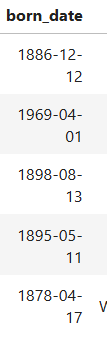

bisa dikatakan lebih mudah, tapi disarankan untuk *covert* tipe data kolom tersebut ke bentuk `Date Time` terlebih dahulu agar lebih mudah jika melakukan operasi

lalu disimpan pada kolom baru `born_datetime`

In [208]:
bios_new['born_datetime'] = pd.to_datetime(bios['born_date'])

kita cek lagi, apakah kolom `boorn_datetime` sudah ada?

In [209]:
bios_new.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,first_name,last_name,born_datetime
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,Jean-François,Blanchy,1886-12-12
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,Arnaud,Boetsch,1969-04-01
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,Jean,Borotra,1898-08-13
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,Jacques,Brugnon,1895-05-11
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,Albert,Canet,1878-04-17


oke, sudah ada di paling kanan. 

Kita cek dulu tipe datanya :

In [210]:
bios_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145500 entries, 0 to 145499
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   athlete_id     145500 non-null  int64         
 1   name           145500 non-null  object        
 2   born_date      143693 non-null  object        
 3   born_city      110908 non-null  object        
 4   born_region    110908 non-null  object        
 5   born_country   110908 non-null  object        
 6   NOC            145499 non-null  object        
 7   height_cm      106651 non-null  float64       
 8   weight_kg      102070 non-null  float64       
 9   died_date      33940 non-null   object        
 10  first_name     145500 non-null  object        
 11  last_name      145500 non-null  object        
 12  born_datetime  143693 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(9)
memory usage: 14.4+ MB


**`12  born_datetime  143693 non-null  datetime64[ns]`** sudah dalam bentuk `datetime`.

karena tadi niat awal kita ingin membuat **kolom baru berupa tahun kelahiran atlet**, **kita ambil tahun-nya saja** :

In [211]:
bios_new['born_year'] = bios_new['born_datetime'].dt.year

In [212]:
bios_new.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,first_name,last_name,born_datetime,born_year
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,Jean-François,Blanchy,1886-12-12,1886.0
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,Arnaud,Boetsch,1969-04-01,1969.0
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,Jean,Borotra,1898-08-13,1898.0
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,Jacques,Brugnon,1895-05-11,1895.0
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,Albert,Canet,1878-04-17,1878.0


supaya mempermudah kita melihat, kita ambil beberapa kolom saja :

In [213]:
bios_new[['name', 'born_date', 'first_name', 'last_name', 'born_year']]

,name,born_date,first_name,last_name,born_year
0,Jean-François Blanchy,1886-12-12,Jean-François,Blanchy,1886.0
1,Arnaud Boetsch,1969-04-01,Arnaud,Boetsch,1969.0
2,Jean Borotra,1898-08-13,Jean,Borotra,1898.0
3,Jacques Brugnon,1895-05-11,Jacques,Brugnon,1895.0
4,Albert Canet,1878-04-17,Albert,Canet,1878.0
...,...,...,...,...,...
145495,Polina Luchnikova,2002-01-30,Polina,Luchnikova,2002.0
145496,Valeriya Merkusheva,1999-09-20,Valeriya,Merkusheva,1999.0
145497,Yuliya Smirnova,1998-05-08,Yuliya,Smirnova,1998.0
145498,André Foussard,1899-05-19,André,Foussard,1899.0


---

#### errors ='coerce'

Diatas tadi saya nyebutin kalo format datetime tahun-bulan-hari itu mudah implementasi. 

Tapi terkadang satu hal yang harus kita tahu adalah, format tanggal bisa berbeda dan bisa terjadi error ketika kita melakukan konversi data ke date time.

Nah kalo ada error pada saat konversi tipe data ketika `pd.to_datetime`, kita bisa tambahkan *syntax* `, errors='coerce'` agar pandas menyelesaikan secara mandiri (mengubah format acak menjadi format tahun-bulan-tanggal)

In [214]:
bios_new['born_datetime'] = pd.to_datetime(bios['born_date'], errors='coerce')

atau kita bisa mengubah secara manual tanggalnya dengan :

In [215]:
bios_new['born_datetime'] = pd.to_datetime(bios['born_date'], format='%Y-%m-%d')

---

## Saving Our Update DataFrame

sapa tau kepake kan datanya, jadi lebih simple karena kita udah nyimpen `first_name`, `last_name`, `born_datetime`, `born_year`

#### to csv

In [216]:
bios_new.to_csv('./konversi data/bios_new.csv', index=False)

#### to excel

In [217]:
# bios_new.to_excel('./konversi data/bios_new.xlsx', index=False)

buset, ke excel aja juga lamanya bukan maen, kirain pas `read_excel` doang yang lama

#### to parquet

In [218]:
bios_new.to_parquet('./konversi data/bios_new.parquet', index=False)

-_- itu barusan ga sampe 2 detik kelar

**1. Kalau Kamu LUPA pakai `index=False` (Default `True`)**

Pandas secara otomatis memberi "nomor punggung" atau **Index** (0, 1, 2...) di setiap baris DataFrame kamu.

Kalau kamu simpan dengan:
`df.to_csv("data.csv")`

Maka di dalam file Excel/CSV nanti, hasilnya akan seperti ini:

|  | Nama | Umur |
| --- | --- | --- |
| **0** | Arie | 21 |
| **1** | Retha | 45 |
| **2** | Fesnuk | 34 |

Lihat kolom paling kiri yang kosong judulnya? Itu adalah Index.

**Masalahnya muncul saat kamu LOAD lagi file itu:**
Saat kamu baca lagi dengan `pd.read_csv("data.csv")`, Pandas akan menganggap kolom angka itu sebagai data biasa. Pandas lalu membuatkan index *baru* lagi.

Hasilnya jadi **double** (Jelek banget):

| Index (Baru) | Unnamed: 0 (Sampah) | Nama | Umur |
| --- | --- | --- | --- |
| 0 | 0 | Arie | 21 |
| 1 | 1 | Retha | 45 |
| 2 | 2 | Fesnuk | 34 |

Pernah lihat kolom bernama **`Unnamed: 0`**? Nah, itu pelakunya! Itu muncul karena kamu lupa set `index=False` saat menyimpan sebelumnya.

---

**2. Kalau Kamu PAKAI `index=False` (Yang Benar)**

Ini artinya: *"Hai Pandas, tolong simpan datanya saja. Nomor urut barisnya (0, 1, 2) buang saja, nanti kalau diload kan bisa bikin nomor urut baru."*

`df.to_csv("data.csv", index=False)`

Hasil di file Excel/CSV bersih:

| Nama | Umur |
| --- | --- |
| Arie | 21 |
| Retha | 45 |
| Fesnuk | 34 |

Saat di-load kembali, DataFrame kamu tetap bersih dan rapi.

---

**Kapan Kita HARUS set `index=True` (Default)?**

Kita membiarkan index ikut disimpan **HANYA JIKA** index tersebut punya arti penting.

Contoh paling umum adalah **Time Series Data** (Data Runtun Waktu) atau jika Index-nya adalah **ID**.

Misal Data Saham, di mana Index-nya adalah Tanggal:

| Date (Index) | Close Price |
| --- | --- |
| 2023-01-01 | 15000 |
| 2023-01-02 | 15200 |

Di sini, Tanggal adalah Index. Kalau kita buang (`index=False`), kita kehilangan informasi tanggalnya. Jadi untuk kasus ini, kita biarkan `index=True`.

**Kesimpulan:**
Untuk 90% kasus (terutama kalau index kamu cuma angka 0, 1, 2...), **SELALU** gunakan `index=False`.

#### to feather

In [219]:
# bios_new.to_feather('./konversi data/bios_new.feather', index=False)

baru tau feather ga bisa make `index=False`

Pertanyaan yang sangat jeli! Kamu benar-benar memperhatikan detail error-nya.

Jawabannya singkatnya: **Karena format Feather itu "Lebih Pintar" daripada CSV/Excel.**

Mari kita bedah kenapa `to_feather` tidak punya tombol `index=False`.

---

**1. CSV/Excel itu "Pelupa" (Teks Biasa)**

Format CSV atau Excel itu pada dasarnya hanya **teks yang berjejer**.

* Saat kamu simpan DataFrame ke CSV tanpa `index=False`, si Index (0, 1, 2) itu dicatat sebagai **kolom biasa** di urutan pertama.
* Si CSV **lupa** kalau itu dulunya adalah Index. Dia taunya itu angka.
* Makanya pas di-load balik, dia muncul sebagai kolom sampah (`Unnamed: 0`).
* **Solusi:** Kita paksa jangan simpan indexnya (`index=False`).

**2. Feather itu "Ingatannya Kuat" (Binary Format)**

Feather (dan saudara dekatnya, Parquet) adalah format **Binary** yang didukung oleh teknologi **Apache Arrow**. Dia menyimpan data persis seperti bentuknya di memori komputer (RAM).

* Feather menyimpan **Metadata**. Dia "ingat" struktur DataFrame kamu: *"Oh, kolom A itu data, kolom B itu data, dan angka 0,1,2 ini adalah INDEX, bukan data."*
* Jadi, walaupun Index-nya ikut disimpan, Feather **menandainya** sebagai Index.
* Saat kamu load balik (`pd.read_feather`), dia akan otomatis menaruh angka 0, 1, 2 itu kembali ke tempat asalnya (di posisi Index), **bukan** menjadi kolom baru yang mengganggu.

Karena Feather yakin dia bisa mengembalikan posisinya dengan sempurna, pembuat library-nya (Wes McKinney, yang juga bikin Pandas) memutuskan: *"Gak perlu opsi `index=False`. Simpan saja semuanya biar datanya utuh."*

---

**"Tapi aku benci banget sama Index-nya, mau buang aja!"**

Kalau kamu benar-benar ingin membuang index saat menyimpan ke Feather (misal index kamu acak-acakan dan kamu mau reset jadi 0, 1, 2 lagi nanti), kamu tidak bisa melakukannya di dalam fungsi `to_feather`.

Kamu harus melakukannya **sebelum** menyimpan, pakai jurus `.reset_index()`:

```python
# CARA SALAH (Error)
# df.to_feather("data.feather", index=False)

# CARA BENAR (Reset dulu, baru simpan)
# drop=True artinya: "Buang index lama ke tong sampah, jangan jadiin kolom baru"
df.reset_index(drop=True).to_feather("data.feather")

```

**Kesimpulan**

* **CSV/Excel:** Harus `index=False` biar gak muncul kolom sampah.
* **Feather:** Gak perlu `index=False` karena dia pintar (gak bakal bikin kolom sampah).
* **Parquet:** Dia unik, bisa dua-duanya (default-nya pintar kayak Feather, tapi kadang punya opsi buat atur index tergantung *engine*-nya).

In [220]:
bios_new.to_feather('./konversi data/bios_new.feather')

ini kek nya lebih cepet lagi

---

## Adding / Removing Columns 3

#### Using Lambda w/ .apply()

Anggaplah kita pengen buat kolom baru lagi dengan menambahkan .. mungkin kategori berdasarkan tinggi badan seseorang. Semisal :

- < 165 : pendek
- < 185 : rata-rata
- \> 185 : tinggi

In [221]:
bios_new['height_category'] = bios_new['height_cm'].apply(lambda x: 'Short' if x < 165 else ('Average' if x < 185 else 'Tall'))

In [222]:
bios_new.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,first_name,last_name,born_datetime,born_year,height_category
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,Jean-François,Blanchy,1886-12-12,1886.0,Tall
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,Arnaud,Boetsch,1969-04-01,1969.0,Average
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,Jean,Borotra,1898-08-13,1898.0,Average
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,Jacques,Brugnon,1895-05-11,1895.0,Average
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,Albert,Canet,1878-04-17,1878.0,Tall


kita cek yang pendek siapa ae atlet dari Indonesia

In [223]:
bios_new[(bios_new['height_category'] == 'Short') & (bios_new['born_country'] == 'INA')].head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,first_name,last_name,born_datetime,born_year,height_category
242,243,Susy Susanti,1971-02-11,Tasikmalaya,Jawa Barat,INA,Indonesia,161.0,NaN,NaN,Susy,Susanti,1971-02-11,1971.0,Short
243,244,Lili Tampi,1970-05-19,Tasikmalaya,Jawa Barat,INA,Indonesia,161.0,NaN,NaN,Lili,Tampi,1970-05-19,1970.0,Short
246,247,Minarti Timur,1968-03-24,Surabaya,Jawa Timur,INA,Indonesia,163.0,55.0,NaN,Minarti,Timur,1968-03-24,1968.0,Short
247,248,Mia Audina,1979-08-22,Jakarta,Daerah Khusus Ibukota Jakarta,INA,Indonesia Netherlands,163.0,67.0,NaN,,Audina,1979-08-22,1979.0,Short
1879,1889,Lilies Handayani,1965-04-15,Surabaya,Jawa Timur,INA,Indonesia,155.0,50.0,NaN,Lilies,Handayani,1965-04-15,1965.0,Short


ada sebanyak 5 atlet

Sekarang kita cek yang tingginya >= 165 cm

In [224]:
bios_new[(bios_new['height_category'] == 'Average') & (bios_new['born_country'] == 'INA')].head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,first_name,last_name,born_datetime,born_year,height_category
232,233,Yayuk Basuki,1970-11-30,Yogyakarta,Daerah Istimewa Yogyakarta,INA,Indonesia,165.0,55.0,NaN,Yayuk,Basuki,1970-11-30,1970.0,Average
238,239,Zelin Resiana,1972-07-09,Magelang,Jawa Tengah,INA,Indonesia,169.0,58.0,NaN,Zelin,Resiana,1972-07-09,1972.0,Average
249,250,Antonius Ariantho,1971-10-03,Pekalongan,Jawa Tengah,INA,Indonesia,170.0,66.0,NaN,Antonius,Ariantho,1971-10-03,1971.0,Average
251,252,Eddy Hartono,1964-07-19,Kudus,Jawa Tengah,INA,Indonesia,173.0,73.0,NaN,Eddy,Hartono,1964-07-19,1964.0,Average
252,253,Hariyanto Arbi,1972-01-21,Kudus,Jawa Tengah,INA,Indonesia,178.0,70.0,NaN,Hariyanto,Arbi,1972-01-21,1972.0,Average


ada 5 orang lagi

sekarang kita cek yang 'tinggi'

In [225]:
bios_new[(bios_new['height_category'] == 'Tall') & (bios_new['born_country'] == 'INA')].head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,first_name,last_name,born_datetime,born_year,height_category
233,234,Rossy Pratiwi Dipoyanti,1972-06-28,Bandung,Jawa Barat,INA,Indonesia,NaN,NaN,NaN,Rossy,Dipoyanti,1972-06-28,1972.0,Tall
234,235,Finarsih,1972-02-08,Sleman,Jawa Tengah,INA,Indonesia,NaN,NaN,NaN,,Finarsih,1972-02-08,1972.0,Tall
235,236,Ling Ling Agustin,1969-08-23,Kediri,Jawa Timur,INA,Indonesia,NaN,NaN,NaN,Ling,Agustin,1969-08-23,1969.0,Tall
239,240,Yuliani Santoso,1971-10-29,Semarang,Jawa Tengah,INA,Indonesia,NaN,NaN,NaN,Yuliani,Santoso,1971-10-29,1971.0,Tall
240,241,Sarwendah Kusumawardhani,1967-08-22,Malang,Jawa Timur,INA,Indonesia,NaN,NaN,NaN,Sarwendah,Kusumawardhani,1967-08-22,1967.0,Tall


dikit bet dah prasaan

oke jadi itu yah cara `.apply` menggunakan `lambda` di Pandas. Apalagi dibuat secara spesifik berdasarkan tinggi berapa kategorinya berapa, tinggi diatas sekian kategorinya apa dan seterusnya.

---

#### Custome Function with .apply()

Hal lain yang bisa kita lakukan adalah membuat `Function` atau fungsi dalam pandas menggunakan `.apply()`. Tapi mau buat kolom paan lagi ya?

ah mungkin kelas seseorang kek Tinju gitu kali ye, 

In [226]:
def categorize_atlet(row):
    if row['height_cm'] < 175 and row['weight_kg'] < 70:
        return 'Kelas Ringan'
    elif row['height_cm'] < 185 or row['weight_kg'] <= 80:
        return 'Kelas Menengah'

    else:
        return 'Kelas Berat'

bios_new['Category'] = bios_new.apply(categorize_atlet, axis=1) # 1 untuk baris, 0 untuk kolom

Ingat, *mungkin tidak se'efisien Pandas lambda diatas*, **tapi menggunakan Function ini akan memudahkan seseorang untuk mengerti apa maksudnya**. Ya walaupun terlepas dari loadingnya lumayan lama ketika di run.

In [227]:
bios_new.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,first_name,last_name,born_datetime,born_year,height_category,Category
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,Jean-François,Blanchy,1886-12-12,1886.0,Tall,Kelas Berat
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,Arnaud,Boetsch,1969-04-01,1969.0,Average,Kelas Menengah
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,Jean,Borotra,1898-08-13,1898.0,Average,Kelas Menengah
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,Jacques,Brugnon,1895-05-11,1895.0,Average,Kelas Ringan
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,Albert,Canet,1878-04-17,1878.0,Tall,Kelas Berat


hmm kek nya di save ulang aja dah

#### Save ulang

In [228]:
bios_new.to_csv('./konversi data/bios_new.csv', index=False)

In [229]:
# bios_new.to_excel('./konversi data/bios_new.xlsx', index=False)

In [230]:
bios_new.to_parquet('./konversi data/bios_new.parquet', index=False)

In [231]:
bios_new.to_feather('./konversi data/bios_new.feather')

---

## Merging & Concatenating Data

### pd.merge()

Okeh, selanjutnya, kita akan menambahkan dan memindahkan / menghilangkan kolom dimana kita bisa melakukan *`Merging`* (penggabungan) dan *`Concate`* (pemisahan) data. 

Jadi mungkin kita coba liat lagi data `bios`

In [232]:
bios.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25


Satu hal yang mungkin bisa kita lakukan adalah mau mengambil data dari kolom **`born_country`** yang dimana bisa kita lihat disitu hanya terdiri dari 3 huruf besar seperti **`FRA`** dan **`GBR`**,, dan **Mungkin yang bisa kita lakukan adalah meng-konversinya menjadi nama negara asal.** 

Sebenarnya bisa dilihat sih dikolom sebelahnya yaitu `NOC`, tapi ga semua atlet lahir dan besar di negara yang sama, mungkin bisa dilihat di baris ke-`5` ada `Albert Canet` yang lahir di `Great Britian` (Teritori Inggris) namun besar di `Prancis` (`France`). 

Jadi, kita mau untuk membuatnya lebih eksplisit **di negara mana mereka lahir dan di negara apa mereka menjadi atlet?** yang mungkin juga kita bisa melakukan filtering data berdasarkan hal tersebut.

Tapi kita tidak akan hanya menggunakan data `bios` melainkan juga akan menggunakan data `NOC`, kalian bisa cari di Kaggle.

In [233]:
nocs = pd.read_csv('./data/noc_regions.csv')

In [234]:
nocs.head()

,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN


Bisa kita lihat, 3 kode huruf dikolom `NOC` dan lebih jelasnya di region (negara). Jadi yang bisa kita lakukan disini adalah *merging data*. 

Nah di kolom yang mana aja?
- di data `bios` kita akan menggunakan kolom `born_country`
- untuk data `nocs` kita akan menggunakan kolom `NOC` 
- **Karena kedua kolom tersebut sama-sama memiliki baris data 3 kode huruf**

In [235]:
bios_new = pd.merge(bios, nocs, left_on="born_country", right_on='NOC', how='left') # default how=inner, karena kita menempatkan bios di kiri, akhirnya make left
#   data kiri, data kanan, data kiri kolom born.. , data kanan kolom noc, dengan cara merge=left

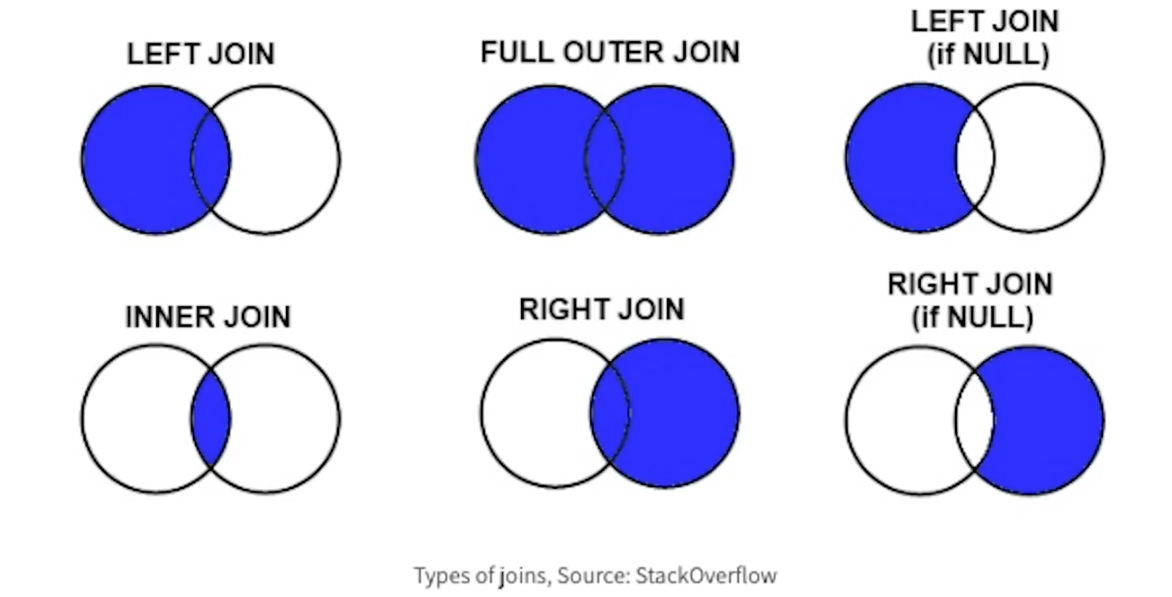

kita cek, setelah `merge` hasilnya seperti apa :

In [236]:
bios_new.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC_x,height_cm,weight_kg,died_date,NOC_y,region,notes
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,FRA,France,NaN
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,FRA,France,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,FRA,France,NaN
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,FRA,France,NaN
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,GBR,UK,NaN


hmm, **kalian lihat kolom yang paling kanan nomer 2? `region`?** itu seharusnya menjadi hasil dari merge. 

Hmm lebih baik kayanya kita ganti nama kolom tersebut

In [237]:
bios_new.rename(columns={'region' : 'born_country_full'}, inplace=True)

In [238]:
bios_new.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC_x,height_cm,weight_kg,died_date,NOC_y,born_country_full,notes
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,FRA,France,NaN
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,FRA,France,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,FRA,France,NaN
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,FRA,France,NaN
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,GBR,UK,NaN


Oke, dah ganti ya nama kolomnya.

Dan ada satu hal yang harus dicatat adalah disitu ada kolom :
> bios -> `NOC_x`)

> dan kolom baru (noc -> `NOC_y`)

**kedua kolom tersebut disebut `suffix`** 

biar ga bingung itu kolom dari data mana, bisa kita tambahkan syntax `suffixes` :

In [239]:
bios_new = pd.merge(bios, nocs, left_on="born_country", right_on='NOC', how='left', suffixes=['biosdf', 'nocdf'])

- `biosdf` dari dataframe kiri atau `bios_new`
- `nocdf` dari dataframe kanan atau `nocs`

kita lihat hasilnya

In [240]:
bios_new.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOCbiosdf,height_cm,weight_kg,died_date,NOCnocdf,region,notes
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,FRA,France,NaN
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,FRA,France,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,FRA,France,NaN
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,FRA,France,NaN
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,GBR,UK,NaN


Nah baru keliatan. 

Mungkin kalian *bertanya-tanya kenapa itu terjadi?*

Itu **terjadi karena kedua data tadi** (bios dan noc) **sama-sama memiliki kolom `NOC`**, sehingga penambahan nama `_x` dan `_y` diawal terjadi otomatis oleh Pandas Python. Sehingga biar ga binggung kita atur *suffixes*-nya

Eh kok itu jadi `region` lagi?

In [241]:
bios_new.rename(columns={'region' : 'born_country_full'}, inplace=True)

In [242]:
bios_new.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOCbiosdf,height_cm,weight_kg,died_date,NOCnocdf,born_country_full,notes
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,FRA,France,NaN
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,FRA,France,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,FRA,France,NaN
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,FRA,France,NaN
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,GBR,UK,NaN


---

#### filtering hasil merge

Coba deh, kita lihat atlet mana saja yang **`bukan berasal dari negara asal`** alias **lahir dari negara lain**

In [243]:
bios_new[bios_new['NOCbiosdf'] != bios_new['born_country_full']]

,athlete_id,name,born_date,born_city,born_region,born_country,NOCbiosdf,height_cm,weight_kg,died_date,NOCnocdf,born_country_full,notes
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,GBR,UK,NaN
12,13,J. Defert,NaN,NaN,NaN,NaN,France,NaN,NaN,NaN,NaN,NaN,NaN
13,14,Étienne Durand,NaN,NaN,NaN,NaN,France,NaN,NaN,NaN,NaN,NaN,NaN
16,17,Guy Forget,1965-01-04,Casablanca,Casablanca-Settat,MAR,France,189.0,79.0,NaN,MAR,Morocco,NaN
27,28,"Guy, Baron Lejeune",NaN,NaN,NaN,NaN,France,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145491,149218,Matthew Wepke,1989-12-05,NaN,NaN,NaN,Jamaica,NaN,NaN,NaN,NaN,NaN,NaN
145493,149220,Landysh Falyakhova,1998-08-31,Dva Polya Artash,Respublika Tatarstan,RUS,ROC,NaN,NaN,NaN,RUS,Russia,NaN
145495,149222,Polina Luchnikova,2002-01-30,Serov,Sverdlovsk,RUS,ROC,167.0,61.0,NaN,RUS,Russia,NaN
145496,149223,Valeriya Merkusheva,1999-09-20,Moskva (Moscow),Moskva,RUS,ROC,168.0,65.0,NaN,RUS,Russia,NaN


Ga keliatan jelas ya. well, ulangi dan ambil kolom yang dibutuhkan saja

In [244]:
bios_new[bios_new['NOCbiosdf'] != bios_new['born_country_full']][['name', 'NOCbiosdf', 'born_country_full']]

,name,NOCbiosdf,born_country_full
4,Albert Canet,France,UK
12,J. Defert,France,NaN
13,Étienne Durand,France,NaN
16,Guy Forget,France,Morocco
27,"Guy, Baron Lejeune",France,NaN
...,...,...,...
145491,Matthew Wepke,Jamaica,NaN
145493,Landysh Falyakhova,ROC,Russia
145495,Polina Luchnikova,ROC,Russia
145496,Valeriya Merkusheva,ROC,Russia


Ya bisa dilihat sebagai contoh ada `Albert Canet` yang **lahir di France** namun **menjadi atlet di UK (United Kingdom/Inggris).**

Kita lihat dari data ada berapa banyak atlet yang pindah kewarganegaraan?

In [245]:
bios_new[bios_new['NOCbiosdf'] != bios_new['born_country_full']][['name', 'NOCbiosdf', 'born_country_full']].shape

(73210, 3)

---

### pd.concat()

Nah **anggap lah ramalah kedua negara, yaitu Indonesia dan Malaysia menjadi satu negara benar-benar terjadi**, kita mau tidak mau akan membutuhkan data dari kedua negara tersebut menjadi satu.

kita cari dulu atlet yang lahir di Indonesia

In [246]:
atlet_indo = bios_new[bios_new['born_country_full'] == 'Indonesia'].copy()

In [247]:
atlet_indo

,athlete_id,name,born_date,born_city,born_region,born_country,NOCbiosdf,height_cm,weight_kg,died_date,NOCnocdf,born_country_full,notes
232,233,Yayuk Basuki,1970-11-30,Yogyakarta,Daerah Istimewa Yogyakarta,INA,Indonesia,165.0,55.0,NaN,INA,Indonesia,NaN
233,234,Rossy Pratiwi Dipoyanti,1972-06-28,Bandung,Jawa Barat,INA,Indonesia,NaN,NaN,NaN,INA,Indonesia,NaN
234,235,Finarsih,1972-02-08,Sleman,Jawa Tengah,INA,Indonesia,NaN,NaN,NaN,INA,Indonesia,NaN
235,236,Ling Ling Agustin,1969-08-23,Kediri,Jawa Timur,INA,Indonesia,NaN,NaN,NaN,INA,Indonesia,NaN
238,239,Zelin Resiana,1972-07-09,Magelang,Jawa Tengah,INA,Indonesia,169.0,58.0,NaN,INA,Indonesia,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
140211,143712,Jonatan Christie,1997-09-15,Jakarta,Daerah Khusus Ibukota Jakarta,INA,Indonesia,NaN,NaN,NaN,INA,Indonesia,NaN
140212,143713,Kevin Sanjaya Sukamuljo,1995-08-02,Banyuwangi,Jawa Timur,INA,Indonesia,NaN,NaN,NaN,INA,Indonesia,NaN
140213,143714,Marcus Fernaldi Gideon,1991-03-09,Jakarta,Daerah Khusus Ibukota Jakarta,INA,Indonesia,NaN,NaN,NaN,INA,Indonesia,NaN
140215,143716,Aflah Prawira,1997-11-13,Cirebon,Jawa Barat,INA,Indonesia,NaN,NaN,NaN,INA,Indonesia,NaN


Lalu coba kita lihat atlet mana saja yang berasal dari Malaysia

In [248]:
atlet_malay = bios_new[bios_new['born_country_full'] == 'Malaysia'].copy()

In [249]:
atlet_malay

,athlete_id,name,born_date,born_city,born_region,born_country,NOCbiosdf,height_cm,weight_kg,died_date,NOCnocdf,born_country_full,notes
950,954,Cheah Soon Kit,1968-01-09,Ipoh,Perak,MAS,Malaysia,180.0,73.0,NaN,MAS,Malaysia,NaN
952,956,Ong Ewe Hock,1972-03-14,Penang,Pulau Pinang,MAS,Malaysia,163.0,55.0,NaN,MAS,Malaysia,NaN
953,957,Alan Sidek Mohamed,1963-11-10,Banting,Selangor,MAS,Malaysia,178.0,69.0,NaN,MAS,Malaysia,NaN
954,958,Ajib Sidek Mohamed,1968-07-08,Banting,Selangor,MAS,Malaysia,180.0,68.0,NaN,MAS,Malaysia,NaN
958,962,Yap Kim Hock,1970-07-02,Muar,Johor,MAS,Malaysia,160.0,60.0,NaN,MAS,Malaysia,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
132242,135093,Welson Sim,1997-03-29,Kuching,Sarawak,MAS,Malaysia,181.0,70.0,NaN,MAS,Malaysia,NaN
132243,135094,Mohammad Hafifi bin Mansor,1990-10-28,Kuala Terengganu,Terengganu,MAS,Malaysia,166.0,69.0,NaN,MAS,Malaysia,NaN
134593,137673,Jeffrey Webb,1998-10-27,Kuala Lumpur,Kuala Lumpur,MAS,Malaysia,173.0,65.0,NaN,MAS,Malaysia,NaN
134594,137674,Julian Yee,1997-05-26,Kuala Lumpur,Kuala Lumpur,MAS,Malaysia,166.0,60.0,NaN,MAS,Malaysia,NaN


In [250]:
indo_malay = pd.concat([atlet_indo, atlet_malay])

Secara default harusnya concat hanya menggabungkan 2 data, 

jadi dari baris 1-348 atletnya dari Indonesia, 

lalu untuk urutan 349 hingga akhir dari malaysia. Kita lihat deh

In [251]:
indo_malay.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOCbiosdf,height_cm,weight_kg,died_date,NOCnocdf,born_country_full,notes
232,233,Yayuk Basuki,1970-11-30,Yogyakarta,Daerah Istimewa Yogyakarta,INA,Indonesia,165.0,55.0,NaN,INA,Indonesia,NaN
233,234,Rossy Pratiwi Dipoyanti,1972-06-28,Bandung,Jawa Barat,INA,Indonesia,NaN,NaN,NaN,INA,Indonesia,NaN
234,235,Finarsih,1972-02-08,Sleman,Jawa Tengah,INA,Indonesia,NaN,NaN,NaN,INA,Indonesia,NaN
235,236,Ling Ling Agustin,1969-08-23,Kediri,Jawa Timur,INA,Indonesia,NaN,NaN,NaN,INA,Indonesia,NaN
238,239,Zelin Resiana,1972-07-09,Magelang,Jawa Tengah,INA,Indonesia,169.0,58.0,NaN,INA,Indonesia,NaN


oke, dari indo semua yang awal, kita cek yang data bawah

In [252]:
indo_malay.tail()

,athlete_id,name,born_date,born_city,born_region,born_country,NOCbiosdf,height_cm,weight_kg,died_date,NOCnocdf,born_country_full,notes
132242,135093,Welson Sim,1997-03-29,Kuching,Sarawak,MAS,Malaysia,181.0,70.0,NaN,MAS,Malaysia,NaN
132243,135094,Mohammad Hafifi bin Mansor,1990-10-28,Kuala Terengganu,Terengganu,MAS,Malaysia,166.0,69.0,NaN,MAS,Malaysia,NaN
134593,137673,Jeffrey Webb,1998-10-27,Kuala Lumpur,Kuala Lumpur,MAS,Malaysia,173.0,65.0,NaN,MAS,Malaysia,NaN
134594,137674,Julian Yee,1997-05-26,Kuala Lumpur,Kuala Lumpur,MAS,Malaysia,166.0,60.0,NaN,MAS,Malaysia,NaN
135271,138434,P. Alagendra,1929-07-23,Kajang,Selangor,MAS,Malaya,NaN,NaN,NaN,MAS,Malaysia,NaN


Oke, **jadi sepertui itu `join data` menggunakan `concat`**

---

### types of joins

Contoh tambahan penggabungan yang mungkin ingin kita lihat adalah kita mengambil '`Results`' kita di sini.

In [253]:
results.head()

,year,type,discipline,event,as,athlete_id,noc,team,place,tied,medal
0,1912.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,None,17.0,True,None
1,1912.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jean Montariol,NaN,False,None
2,1920.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,None,32.0,True,None
3,1920.0,Summer,Tennis,"Doubles, Mixed (Olympic)",Jean-François Blanchy,1,FRA,Jeanne Vaussard,8.0,True,None
4,1920.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jacques Brugnon,4.0,False,None


Dan kita melihat bahwa ini adalah peristiwa spesifik untuk orang tertentu, dan karena **kita melihat ada `athlet_id`**

In [254]:
bios.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25


Dimana **`athlet_id` juga ada di DataFrame `bios`**, 

kita **bisa mengaitkan antara DataFrame `results` dengan informasi `bios` dari tiap atlet.**

In [255]:
combined_df = pd.merge(results, bios, on='athlete_id', how='left') # karena kita akan menyimpan di result, kita bikin how='left'

In [256]:
combined_df.head()

,year,type,discipline,event,as,athlete_id,noc,team,place,tied,medal,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1912.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,None,17.0,True,None,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,1912.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jean Montariol,NaN,False,None,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
2,1920.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,None,32.0,True,None,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
3,1920.0,Summer,Tennis,"Doubles, Mixed (Olympic)",Jean-François Blanchy,1,FRA,Jeanne Vaussard,8.0,True,None,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
4,1920.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jacques Brugnon,4.0,False,None,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02


Nah itu hasilnya dari penggabungan DataFrame dari 2 DataFrame berbeda, dimana disini kita menggunakan `athlete_id` sebagai jembatan atau pengaitnya.

---

---

---

## Handling Null Values

Selanjutnya, kita akan melihat **bagaimana cara mengatasi `null value`.** Jadi kita balik lagi menggunakan data `coffee`

In [257]:
coffee.head()

,Day,Coffee Type,Units Sold,Price,Revenue
0,Monday,Espresso,25,3.99,99.75
1,Monday,Latte,15,5.99,89.85
2,Tuesday,Espresso,30,3.99,119.70
3,Tuesday,Latte,20,5.99,119.80
4,Wednesday,Espresso,35,3.99,139.65


### np.nan

Anggeplah kita ga punya semua informasi data dari semua data itu, anggeplah kita punya beberapa `null values`. 

Kembali ke pelajaran sebelumnya, **anggeplah kita akan membuat Null Values di baris `0` dan `1`**

In [258]:
coffee.loc[[0,1], "Units Sold"] = np.nan

In [259]:
coffee.head()

,Day,Coffee Type,Units Sold,Price,Revenue
0,Monday,Espresso,NaN,3.99,99.75
1,Monday,Latte,NaN,5.99,89.85
2,Tuesday,Espresso,30.0,3.99,119.70
3,Tuesday,Latte,20.0,5.99,119.80
4,Wednesday,Espresso,35.0,3.99,139.65


### df.info()

bisa dilihat sekarang baris ke-0 dan 1 udah berubah menjadi `NaN`. Untuk melihat informasi Data Null kita bisa mengeceknya menggunakan `.info()`

In [260]:
coffee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Day          14 non-null     object 
 1   Coffee Type  14 non-null     object 
 2   Units Sold   12 non-null     float64
 3   Price        14 non-null     float64
 4   Revenue      14 non-null     float64
dtypes: float64(3), object(2)
memory usage: 692.0+ bytes


Bisa kalian lihat kalo kolom `Units Sold` **hanya ada `12 non-null` data** disaat yg lain jumlahnya ada 14, 

itu berarti ada 2 data NaN atau Null Value.

### .isna().sum()

kita juga bisa mengeceknya dengan cara lain

In [261]:
coffee.isna().sum()

Day            0
Coffee Type    0
Units Sold     2
Price          0
Revenue        0
dtype: int64

kita melihat dengan jelas berapa jumlah `NaN values` dari DataFrame `Coffee`

In [262]:
coffee

,Day,Coffee Type,Units Sold,Price,Revenue
0,Monday,Espresso,NaN,3.99,99.75
1,Monday,Latte,NaN,5.99,89.85
2,Tuesday,Espresso,30.0,3.99,119.70
3,Tuesday,Latte,20.0,5.99,119.80
4,Wednesday,Espresso,35.0,3.99,139.65
5,Wednesday,Latte,25.0,5.99,149.75
6,Thursday,Espresso,40.0,3.99,159.60
7,Thursday,Latte,30.0,5.99,179.70
8,Friday,Espresso,45.0,3.99,179.55
9,Friday,Latte,35.0,5.99,209.65


Namun, _apa yang akan kita lakukan jika di dunia nyata_ kita melihat dataframe kita dan menyadari bahwa kita tidak memiliki `Units Sold` untuk nilai `Monday` kita di sini?

Nah, ada beberapa hal yang bisa kita lakukan.

### .fillna()

 Salah satu yang bisa digunakan adalah `.fillna()`. 
 
 Dan di `.fillna()` juga kita bisa melakukan 2 cara :
 - Memilih angka sembarang (semisal 10.000)
 - Menggunakan `.mean()`, `.min()`, `.max()` , dan lainnya.

Kita coba dulu menggunakan angka sembarang

In [263]:
coffee.fillna(10000)

,Day,Coffee Type,Units Sold,Price,Revenue
0,Monday,Espresso,10000.0,3.99,99.75
1,Monday,Latte,10000.0,5.99,89.85
2,Tuesday,Espresso,30.0,3.99,119.70
3,Tuesday,Latte,20.0,5.99,119.80
4,Wednesday,Espresso,35.0,3.99,139.65
5,Wednesday,Latte,25.0,5.99,149.75
6,Thursday,Espresso,40.0,3.99,159.60
7,Thursday,Latte,30.0,5.99,179.70
8,Friday,Espresso,45.0,3.99,179.55
9,Friday,Latte,35.0,5.99,209.65


Cara ini sih ga di sarankan ya, karena terkesan ngasal dan kek gamau mikir njir. Nah ada cara lain semisal menggunakan `.mean()`

In [264]:
coffee.fillna(coffee['Units Sold'].mean())

,Day,Coffee Type,Units Sold,Price,Revenue
0,Monday,Espresso,35.0,3.99,99.75
1,Monday,Latte,35.0,5.99,89.85
2,Tuesday,Espresso,30.0,3.99,119.70
3,Tuesday,Latte,20.0,5.99,119.80
4,Wednesday,Espresso,35.0,3.99,139.65
5,Wednesday,Latte,25.0,5.99,149.75
6,Thursday,Espresso,40.0,3.99,159.60
7,Thursday,Latte,30.0,5.99,179.70
8,Friday,Espresso,45.0,3.99,179.55
9,Friday,Latte,35.0,5.99,209.65


Nah, hasil `35.0` lebih masuk akal karena nilai tersebut ga terlalu kecil bahkan terlalu besar jika dibandingkan dengan nilai disekitarnya.

atau semisal kita menggunakan `.min()`

In [265]:
coffee.fillna(coffee['Units Sold'].min())

,Day,Coffee Type,Units Sold,Price,Revenue
0,Monday,Espresso,20.0,3.99,99.75
1,Monday,Latte,20.0,5.99,89.85
2,Tuesday,Espresso,30.0,3.99,119.70
3,Tuesday,Latte,20.0,5.99,119.80
4,Wednesday,Espresso,35.0,3.99,139.65
5,Wednesday,Latte,25.0,5.99,149.75
6,Thursday,Espresso,40.0,3.99,159.60
7,Thursday,Latte,30.0,5.99,179.70
8,Friday,Espresso,45.0,3.99,179.55
9,Friday,Latte,35.0,5.99,209.65


---

### .interpolate()

Ada cara lain untuk mengisi kekosongan data seperti `NaN`. Yaitu `.interpolate()` 

Tapi sepertinya **`.interpolate()` baru bekerja dengan baik jika berada ditengah-tengah data**, karena kita membuat `NaN` di awal baris `0` dan `1`, kemungkinan hasilnya tetap `NaN`

In [266]:
coffee.fillna(coffee['Units Sold'].interpolate())

,Day,Coffee Type,Units Sold,Price,Revenue
0,Monday,Espresso,NaN,3.99,99.75
1,Monday,Latte,NaN,5.99,89.85
2,Tuesday,Espresso,30.0,3.99,119.70
3,Tuesday,Latte,20.0,5.99,119.80
4,Wednesday,Espresso,35.0,3.99,139.65
5,Wednesday,Latte,25.0,5.99,149.75
6,Thursday,Espresso,40.0,3.99,159.60
7,Thursday,Latte,30.0,5.99,179.70
8,Friday,Espresso,45.0,3.99,179.55
9,Friday,Latte,35.0,5.99,209.65


Nah kan, kita isi data `0` dan `1` dulu

In [267]:
coffee.loc[0:1, "Units Sold"] = 15

In [268]:
coffee

,Day,Coffee Type,Units Sold,Price,Revenue
0,Monday,Espresso,15.0,3.99,99.75
1,Monday,Latte,15.0,5.99,89.85
2,Tuesday,Espresso,30.0,3.99,119.70
3,Tuesday,Latte,20.0,5.99,119.80
4,Wednesday,Espresso,35.0,3.99,139.65
5,Wednesday,Latte,25.0,5.99,149.75
6,Thursday,Espresso,40.0,3.99,159.60
7,Thursday,Latte,30.0,5.99,179.70
8,Friday,Espresso,45.0,3.99,179.55
9,Friday,Latte,35.0,5.99,209.65


Lalu kita buat data `NaN` di data ke `2` dan `4`

In [269]:
coffee.loc[[2,3], "Units Sold"] = np.nan

In [270]:
coffee.head()

,Day,Coffee Type,Units Sold,Price,Revenue
0,Monday,Espresso,15.0,3.99,99.75
1,Monday,Latte,15.0,5.99,89.85
2,Tuesday,Espresso,NaN,3.99,119.70
3,Tuesday,Latte,NaN,5.99,119.80
4,Wednesday,Espresso,35.0,3.99,139.65


Kita coba lagi `.interpolate()` 

In [271]:
coffee['Units Sold'] = coffee['Units Sold'].interpolate()

In [272]:
coffee

,Day,Coffee Type,Units Sold,Price,Revenue
0,Monday,Espresso,15.000000,3.99,99.75
1,Monday,Latte,15.000000,5.99,89.85
2,Tuesday,Espresso,21.666667,3.99,119.70
3,Tuesday,Latte,28.333333,5.99,119.80
4,Wednesday,Espresso,35.000000,3.99,139.65
5,Wednesday,Latte,25.000000,5.99,149.75
6,Thursday,Espresso,40.000000,3.99,159.60
7,Thursday,Latte,30.000000,5.99,179.70
8,Friday,Espresso,45.000000,3.99,179.55
9,Friday,Latte,35.000000,5.99,209.65


Hmm belum cari tahu lagi sih bagaimana cara kerjanya, tapi itu salah satu cara keren untuk mengisi kekosongan data menggunakan `.interpolate`

### .dropna()

Atau jika kalian merasa ada baiknya menghapus baris tersebut karena, kita dapat melakuan `.dropna()` 

In [273]:
coffee.loc[[2,3], "Units Sold"] = np.nan

In [274]:
coffee.dropna()

,Day,Coffee Type,Units Sold,Price,Revenue
0,Monday,Espresso,15.0,3.99,99.75
1,Monday,Latte,15.0,5.99,89.85
4,Wednesday,Espresso,35.0,3.99,139.65
5,Wednesday,Latte,25.0,5.99,149.75
6,Thursday,Espresso,40.0,3.99,159.60
7,Thursday,Latte,30.0,5.99,179.70
8,Friday,Espresso,45.0,3.99,179.55
9,Friday,Latte,35.0,5.99,209.65
10,Saturday,Espresso,45.0,3.99,179.55
11,Saturday,Latte,35.0,5.99,209.65


Maka baris yang memiliki `NaN` atau missing value akan terhapus,

#### .dropna(subset=)

In [275]:
coffee.dropna(subset=['Units Sold'])

,Day,Coffee Type,Units Sold,Price,Revenue
0,Monday,Espresso,15.0,3.99,99.75
1,Monday,Latte,15.0,5.99,89.85
4,Wednesday,Espresso,35.0,3.99,139.65
5,Wednesday,Latte,25.0,5.99,149.75
6,Thursday,Espresso,40.0,3.99,159.60
7,Thursday,Latte,30.0,5.99,179.70
8,Friday,Espresso,45.0,3.99,179.55
9,Friday,Latte,35.0,5.99,209.65
10,Saturday,Espresso,45.0,3.99,179.55
11,Saturday,Latte,35.0,5.99,209.65


Apa bedanya :

```python
coffee.dropna() # tanpa subset
```

dengan

```python
coffee.dropna(subset=['Units Sold']) # dengan subset
```

Bedanya adalah, jika ada `NaN` di kolom `Price` semisal di baris ke-8, maka baris ke-8 tersebut juga terhapus jika hanya menggunakan `.dropna()`. Ibaratnya, **jika setiap kolom ada data yang memiliki `NaN`, datanya akan terhapus semua**.

Penggunaan `.dropna(subset=['Units Sold'])` adalah untuk **lebih spesifik kolom mana yang ingin datanya dihapus**, namun **jika kolom lain ada `NaN`, tidak akan terhapus.**

---

### .isna()

kalo ini sih cuman ke kaya filtering aja sih, ga ngisi data kosong. lihat nih : 

In [276]:
coffee[coffee['Units Sold'].isna()]

,Day,Coffee Type,Units Sold,Price,Revenue
2,Tuesday,Espresso,NaN,3.99,119.7
3,Tuesday,Latte,NaN,5.99,119.8


Jadi kita bisa melihat di kolom tertentu yang ada `NaN`-nya ada dimana gitu.

Harusnya sih masuk ke filtering ya, well.

---

### .notna()

Mirip `.isna()`, hanya saja kalo `.notna()` untuk melihat data yang bukan `NaN`, anggeplah kalo datanya yang kosong tuh lebih banyak daripada yang ga kosong, baru kita make `.notna()`

In [277]:
coffee[coffee['Units Sold'].notna()]

,Day,Coffee Type,Units Sold,Price,Revenue
0,Monday,Espresso,15.0,3.99,99.75
1,Monday,Latte,15.0,5.99,89.85
4,Wednesday,Espresso,35.0,3.99,139.65
5,Wednesday,Latte,25.0,5.99,149.75
6,Thursday,Espresso,40.0,3.99,159.60
7,Thursday,Latte,30.0,5.99,179.70
8,Friday,Espresso,45.0,3.99,179.55
9,Friday,Latte,35.0,5.99,209.65
10,Saturday,Espresso,45.0,3.99,179.55
11,Saturday,Latte,35.0,5.99,209.65


---

---

## Aggregating Data 1

Saat kita melanjutkan tutorial ini, salah satu hal yang sangat berguna adalah bagaimana kita dapat mengagregasi data. Jadi, menggabungkan berbagai hal, mengelompokkan berbagai hal, menggunakan tabel pivot, dan lain sebagainya. 

### value_counts()

Mungkin agregasi paling dasar yang menurut saya sangat berguna adalah `value_counts`.

Jadi, jika kita melihat informasi biografi para atlet kita,

In [278]:
bios.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25


mungkin saya sangat penasaran dari **kota mana saja atlet Olimpiade teratas berasal**. Dan saya secara eksplisit ingin melakukan penghitungan nilai pada kolom `born_city`

In [279]:
bios['born_city'].value_counts()

born_city
Budapest           1378
Moskva (Moscow)     883
Oslo                708
Stockholm           629
Praha (Prague)      600
                   ... 
Kirovgrad             1
Pereiaslav            1
Podgornyy             1
Kudepsta              1
Furmanov              1
Name: count, Length: 22368, dtype: int64

`Budapest` memimpin, dengan `Moskow` di posisi kedua dan `Oslo` di posisi ketiga.

dan kita bisa mulai menggabungkan berbagai hal di sini. Semisal **dari kota mana atlet yang berasal dari Indonesia?**

In [280]:
bios[bios['born_country'] == 'INA'][['born_region']].value_counts()

born_region                  
Daerah Khusus Ibukota Jakarta    62
Jawa Timur                       60
Jawa Tengah                      57
Jawa Barat                       42
Sumatera Utara                   18
Sulawesi Selatan                 12
Sulawesi Utara                   10
Aceh                              9
Daerah Istimewa Yogyakarta        9
Bali                              8
Lampung                           7
Kalimantan Timur                  6
Sumatera Selatan                  6
Maluku                            6
Papua                             4
Sulawesi Tenggara                 4
Nusa Tenggara Timur               4
Maluku Utara                      3
Sumatera Barat                    3
Nusa Tenggara Barat               3
Kalimantan Barat                  2
Jambi                             2
Kepulauan Riau                    2
Papua Barat                       2
Bangka-Belitung                   1
Bengkulu                          1
Banten                            

**`Daerah Khusus Ibukota Jakarta` dengan 62 atlet** dimana itu hal yang sangat wajar karena **`DKI Jakarta` tentunya memiliki fasilitas yang mumpuni**, lalu diikuti oleh `Jawa Timur`, `Jawa Tengah`, dan seterusnya.

## Aggregating Data 2

### groupby()

Mungkin selanjutnya kita akan mengelompokan data berdasarkan jenis kopi, hari, dan lainnya. Kita gunakan kembali data `coffee`

In [281]:
coffee

,Day,Coffee Type,Units Sold,Price,Revenue
0,Monday,Espresso,15.0,3.99,99.75
1,Monday,Latte,15.0,5.99,89.85
2,Tuesday,Espresso,NaN,3.99,119.70
3,Tuesday,Latte,NaN,5.99,119.80
4,Wednesday,Espresso,35.0,3.99,139.65
5,Wednesday,Latte,25.0,5.99,149.75
6,Thursday,Espresso,40.0,3.99,159.60
7,Thursday,Latte,30.0,5.99,179.70
8,Friday,Espresso,45.0,3.99,179.55
9,Friday,Latte,35.0,5.99,209.65


Yampun

In [282]:
coffee['Units Sold'] = coffee['Units Sold'].interpolate()

In [283]:
coffee

,Day,Coffee Type,Units Sold,Price,Revenue
0,Monday,Espresso,15.000000,3.99,99.75
1,Monday,Latte,15.000000,5.99,89.85
2,Tuesday,Espresso,21.666667,3.99,119.70
3,Tuesday,Latte,28.333333,5.99,119.80
4,Wednesday,Espresso,35.000000,3.99,139.65
5,Wednesday,Latte,25.000000,5.99,149.75
6,Thursday,Espresso,40.000000,3.99,159.60
7,Thursday,Latte,30.000000,5.99,179.70
8,Friday,Espresso,45.000000,3.99,179.55
9,Friday,Latte,35.000000,5.99,209.65


oke, kita mulai sekarang :


**Cara Kerja: Split-Apply-Combine**

Bayangkan kamu punya data penjualan kopi dari berbagai cabang.

1. **Split** : Data dipotong-potong dan dikelompokkan berdasarkan kolom tertentu (misal: dikelompokkan per "Nama Cabang").

2. **Apply** : Di setiap kelompok, kita lakukan operasi matematika (misal: dijumlahkan, dicari rata-ratanya, atau dihitung jumlah barisnya).

3. **Combine** : Hasil dari masing-masing kelompok disatukan kembali menjadi satu tabel ringkasan.

#### .sum

In [284]:
# 1. Pilih kolom yang mau dikelompokkan (Cabang)
# 2. Pilih kolom yang mau dihitung (Terjual)
# 3. Pilih operasinya (sum)
coffee.groupby('Coffee Type')['Units Sold'].sum()

Coffee Type
Espresso    246.666667
Latte       203.333333
Name: Units Sold, dtype: float64

Ternyata cukup banyak ya. Untuk Espresso terjual 246.66, kok ada koma njer? kita buletin ae ya jadi ada **246 Espresso terjual** dan ada **203 Latte terjual**.

---

#### .mean

Coba sekarang kita cari rata-rata perhari terjual berapa kopi

In [285]:
coffee.groupby('Coffee Type')['Units Sold'].mean()

Coffee Type
Espresso    35.238095
Latte       29.047619
Name: Units Sold, dtype: float64

Terlihat jika **`Espresso` rata-rata terjual sebanyak 35 kopi sehari**, lalu **`Latte` terjual sebanyak 29 kopi sehari**.

#### .agg

Salah satu hal yang keren adalah, **misalnya kita ingin menghitung berbagai hal berdasarkan data kita**, kita bisa menggunakan `.egg` dan memasukkan kamus di sini.

In [286]:
coffee.groupby('Coffee Type').agg({'Units Sold' : 'sum', 'Price' : 'mean'})

,Units Sold,Price
Coffee Type,,
Espresso,246.666667,3.99
Latte,203.333333,5.99


Sengaja kenapa `Units Sold` menggunakan `sum` dan `Price` menggunakan `mean`? ya **karena kita ingin melihat keseluruhan total penjualan kopi**. Dan **untuk harga kan ga mungkin dijumlah**, kalo dijumlah bakal gede nanti, makanya **kita make mean agar tidak terlalu melenceng jauh dari harga sebenarnya.**

---

### groupby multipe properties

Mungkin kita juga bisa menambahkan kolom lain semisal `day`, kita ingin melihat total penjualan perharinya seperti apa.

In [287]:
coffee.groupby(['Coffee Type', 'Day']).agg({'Units Sold' : 'sum', 'Price' : 'mean'})

Units Sold  Price
Coffee Type Day                         
Espresso    Friday      45.000000   3.99
            Monday      15.000000   3.99
            Saturday    45.000000   3.99
            Sunday      45.000000   3.99
            Thursday    40.000000   3.99
            Tuesday     21.666667   3.99
            Wednesday   35.000000   3.99
Latte       Friday      35.000000   5.99
            Monday      15.000000   5.99
            Saturday    35.000000   5.99
            Sunday      35.000000   5.99
            Thursday    30.000000   5.99
            Tuesday     28.333333   5.99
            Wednesday   25.000000   5.99

wow, dan ternyata bisa dilihat ada insight baru jika.. hmm kita tambahin syntax `sort_value` dulu deh biar keliatan

In [288]:
coffee.groupby(['Coffee Type', 'Day']).agg({'Units Sold' : 'sum', 'Price' : 'mean'}).sort_values(['Units Sold'], ascending=False)

Units Sold  Price
Coffee Type Day                         
Espresso    Friday      45.000000   3.99
            Saturday    45.000000   3.99
            Sunday      45.000000   3.99
            Thursday    40.000000   3.99
Latte       Friday      35.000000   5.99
Espresso    Wednesday   35.000000   3.99
Latte       Saturday    35.000000   5.99
            Sunday      35.000000   5.99
            Thursday    30.000000   5.99
            Tuesday     28.333333   5.99
            Wednesday   25.000000   5.99
Espresso    Tuesday     21.666667   3.99
            Monday      15.000000   3.99
Latte       Monday      15.000000   5.99

- Sekilas kopi Espresso terjual lebih banyak dari kopi Latt, apalagi ketika weekend.
- Ternyata penjulan kopi pada hari `Jum'at` bukan hari lain, kemungkinan karena mendekati hari weekend dan tidak ada ketakutan untuk tidur malam karena esok harinya libur.

Ga keliatan begitu jelas sih ya. Nah itu harusnya ada di penjelasan Pivot, silahkan scroll kebawah :

## Aggregating Data 3

### Pivot Table

Salah satu cara untuk melakukan hal serupa, tetapi mungkin **sedikit lebih mudah untuk dikelola dalam jangka panjang, adalah dengan membuat pivot pada data kita.**

Jadi, yang saya maksud adalah kita memiliki data frame asli yang terlihat seperti ini.

In [289]:
coffee

,Day,Coffee Type,Units Sold,Price,Revenue
0,Monday,Espresso,15.000000,3.99,99.75
1,Monday,Latte,15.000000,5.99,89.85
2,Tuesday,Espresso,21.666667,3.99,119.70
3,Tuesday,Latte,28.333333,5.99,119.80
4,Wednesday,Espresso,35.000000,3.99,139.65
5,Wednesday,Latte,25.000000,5.99,149.75
6,Thursday,Espresso,40.000000,3.99,159.60
7,Thursday,Latte,30.000000,5.99,179.70
8,Friday,Espresso,45.000000,3.99,179.55
9,Friday,Latte,35.000000,5.99,209.65


Bagaimana kalau kita menggunakan `espresso` dan `latte` sebagai kolom, dan kita melihat `unit terjual` berdasarkan `hari` dalam seminggu atau `pendapatan` untuk produk tersebut berdasarkan hari dalam seminggu?

In [290]:
pivot = coffee.pivot(columns='Coffee Type', index='Day', values='Revenue')

In [291]:
pivot

Coffee Type,Espresso,Latte
Day,,
Friday,179.55,209.65
Monday,99.75,89.85
Saturday,179.55,209.65
Sunday,179.55,209.65
Thursday,159.60,179.70
Tuesday,119.70,119.80
Wednesday,139.65,149.75


mungkin awalnya sedikit aneh ngeliat data kita berubah kek gini, **tapi dengan cara ini kita bisa melihat dengan jelas** _berapa sih penjualan kopi per harinya?_ gitu loh

Kita coba deh, semisal **berapa penjualan kopi Espresso pada hari kamis?**

In [292]:
pivot.loc['Thursday', 'Espresso']

np.float64(159.60000000000002)

ternyata **hasilnya ada `159` kopi `Latte` terjual pada hari kamis.**

Kita coba lagi melihat **berapa total penjualannya tiap jenis kopi?** : 

In [293]:
pivot.sum()

Coffee Type
Espresso    1057.35
Latte       1168.05
dtype: float64

lalu **kita lihat revenue per harinya seperti apa?**

In [294]:
pivot.sum(axis=1)

Day
Friday       389.2
Monday       189.6
Saturday     389.2
Sunday       389.2
Thursday     339.3
Tuesday      239.5
Wednesday    289.4
dtype: float64

---

### Groupby combined with Datetime Operations

Misalnya, kita ingin **mengelompokkan orang berdasarkan tahun kelahiran mereka**.

Untuk melakukan itu, kita bisa melakukan seperti `bios.groupby(date)

In [295]:
bios['born_date'] = pd.to_datetime(bios['born_date'])

bios.groupby(bios['born_date'].dt.year)['name'].count().reset_index().sort_values('name', ascending=False)

,born_date,name
139,1972.0,2231
152,1985.0,2227
140,1973.0,2216
138,1971.0,2205
137,1970.0,2174
...,...,...
4,1837.0,1
2,1833.0,1
6,1839.0,1
12,1845.0,1


Oke, jadi 1972 menjadi tahun kelahiran paling populer dari data Olympic ini, **ada sebanyak `2231` atlet yang lahir pada tahun `1972`**, lalu diikutin tahun yang lainnya. **(Data tahun 2023)**.

Jika kita melakukan hal lebih ekstrim lagi *seperti ingin melihat bulan dan tahun apa atlet lahir?* hasilnya seperti ini :

In [296]:
bios['born_date'] = pd.to_datetime(bios['born_date'])
bios['month_born'] = bios['born_date'].dt.month
bios['year_born'] = bios['born_date'].dt.year

bios.groupby([ bios['month_born'], bios['year_born'] ])['name'].count().reset_index().sort_values('name', ascending=False)

,month_born,year_born,name
124,1.0,1970.0,239
126,1.0,1972.0,229
129,1.0,1975.0,227
140,1.0,1986.0,227
139,1.0,1985.0,225
...,...,...,...
165,2.0,1853.0,1
168,2.0,1859.0,1
172,2.0,1864.0,1
7,1.0,1852.0,1


Ternyata hasilnya adalah, **orang yang lahir di bulan `Januari` (1.0) di tahun `1970` yang memiliki hasil terbanyak dengan `227` total atlet**. 

Tapi hal menarik lainnya adalah, **banyak atlet lahir di bulan Januari**, kita lihat lagi deh

In [297]:
bios.groupby([ bios['month_born'], bios['year_born'] ])['name'].count().reset_index().sort_values('name', ascending=False).head(25)

,month_born,year_born,name
124,1.0,1970.0,239
126,1.0,1972.0,229
129,1.0,1975.0,227
140,1.0,1986.0,227
139,1.0,1985.0,225
452,3.0,1985.0,222
135,1.0,1981.0,221
440,3.0,1973.0,216
136,1.0,1982.0,215
122,1.0,1968.0,213


Jika mengandung atau hamil membutuhkan waktu 9 bulan, ada kemungkinan orang tuanya berhubungan badan :'v astaga gatau nih penting pa kaga buat diceritain :'v well, berarti sekitar bulan-bulan April. Ada apa dengan april? 

Hasil dari Gemini AI adalah seperti ini :

Wah, ini analisa yang sangat menarik! Kamu baru saja menemukan fenomena nyata dalam data yang sering disebut sebagai **"Relative Age Effect"** atau efek usia relatif.

Berdasarkan data yang kamu tampilkan, memang terlihat lonjakan kelahiran yang sangat dominan di bulan **1.0 (Januari)**. Jika kita tarik mundur 9 bulan ke belakang ke bulan **April**, ada beberapa alasan logis dan ilmiah kenapa hal ini terjadi, terutama dalam konteks atlet profesional:

**1. Faktor Seleksi Olahraga (Penyebab Utama)**

Di banyak negara dan cabang olahraga, cutoff (batas umur) untuk pendaftaran kompetisi junior sering kali jatuh pada tanggal 1 Januari.
- Anak yang lahir di bulan Januari akan berkompetisi dengan anak yang lahir di bulan Desember di tahun yang sama.
- Pada usia anak-anak, perbedaan 11-12 bulan itu sangat besar secara fisik (lebih tinggi, lebih kuat) dan mental.
- Pelatih cenderung memilih anak yang "paling menonjol" (yang kebetulan lahir di awal tahun), memberi mereka latihan lebih baik, dan akhirnya mereka lebih berpeluang jadi atlet profesional. Itulah kenapa dataset Olympics kamu penuh dengan orang kelahiran Januari.

**2. Ada Apa di Bulan April? (Sisi Biologis & Psikologis)**
Kalau kita bicara kenapa banyak "proses pembuahan" terjadi di bulan April:

- **Musim Semi (Spring)** : Di belahan bumi utara (tempat banyak negara besar peserta Olympics), April adalah puncak musim semi. Suhu udara mulai menghangat, matahari lebih sering muncul, dan secara biologis, suasana hati (mood) manusia cenderung membaik.
- **Peningkatan Hormon** : Paparan sinar matahari meningkatkan hormon serotonin dan vitamin D, yang menurut beberapa penelitian memiliki korelasi positif dengan tingkat kesuburan dan gairah manusia.
- **Liburan Paskah (Easter)** : Di banyak negara Barat, bulan April identik dengan liburan panjang Paskah. Waktu luang yang lebih banyak bersama pasangan sering kali berkorelasi dengan peningkatan angka kehamilan.

In [298]:
# Coba lihat 10 negara dengan atlet lahir Januari terbanyak
bios[bios['month_born'] == 1].groupby('born_country')['name'].count().sort_values(ascending=False).head(10)

born_country
USA    829
GER    698
GBR    564
FRA    483
ITA    480
RUS    459
CAN    399
POL    319
CHN    304
ESP    261
Name: name, dtype: int64

---

## Advanced Functionality

Mari kita bahas beberapa fungsi yang lebih canggih secara singkat. Beberapa hal yang terlintas di pikiran saya adalah `.shift()`, `.rank()`, `.rolling()`, dan `.cumsum()` -> jumlah kumulatif.

### .shift()

Dimulai dengan `.shift()`. Anggeplah kamu ingin melihat revenue dengan komparasi berdasarkan hari sesudah atau sebelumnya atau kamu bisa melakukan agregat berdasarkan minggu, lalu dibandingkan : *minggu lalu dengan minggu ini banyakan mana revenue*-nya?

Ah mungkin lebih baik kita mulai saja contohnya : 

In [299]:
coffee

,Day,Coffee Type,Units Sold,Price,Revenue
0,Monday,Espresso,15.000000,3.99,99.75
1,Monday,Latte,15.000000,5.99,89.85
2,Tuesday,Espresso,21.666667,3.99,119.70
3,Tuesday,Latte,28.333333,5.99,119.80
4,Wednesday,Espresso,35.000000,3.99,139.65
5,Wednesday,Latte,25.000000,5.99,149.75
6,Thursday,Espresso,40.000000,3.99,159.60
7,Thursday,Latte,30.000000,5.99,179.70
8,Friday,Espresso,45.000000,3.99,179.55
9,Friday,Latte,35.000000,5.99,209.65


In [300]:
coffee['Yesterday Revenue'] = coffee['Revenue'].shift(1)

In [301]:
coffee

,Day,Coffee Type,Units Sold,Price,Revenue,Yesterday Revenue
0,Monday,Espresso,15.000000,3.99,99.75,NaN
1,Monday,Latte,15.000000,5.99,89.85,99.75
2,Tuesday,Espresso,21.666667,3.99,119.70,89.85
3,Tuesday,Latte,28.333333,5.99,119.80,119.70
4,Wednesday,Espresso,35.000000,3.99,139.65,119.80
5,Wednesday,Latte,25.000000,5.99,149.75,139.65
6,Thursday,Espresso,40.000000,3.99,159.60,149.75
7,Thursday,Latte,30.000000,5.99,179.70,159.60
8,Friday,Espresso,45.000000,3.99,179.55,179.70
9,Friday,Latte,35.000000,5.99,209.65,179.55


Oke, jadi hmm kita bisa lihat dalam satu table sebelahan pendapatan hari ini berapa, kemarin dapet berapa gitu.

Mungkin kalian juga bingung fungsi `1` di 

```python
coffee['Revenue'].shift(1)
```

buat apa? kita ganti make angka `2` aja kalo gitu biar langsung tau perbedaannya.

In [302]:
coffee['Yesterday Revenue'] = coffee['Revenue'].shift(2)

In [303]:
coffee

,Day,Coffee Type,Units Sold,Price,Revenue,Yesterday Revenue
0,Monday,Espresso,15.000000,3.99,99.75,NaN
1,Monday,Latte,15.000000,5.99,89.85,NaN
2,Tuesday,Espresso,21.666667,3.99,119.70,99.75
3,Tuesday,Latte,28.333333,5.99,119.80,89.85
4,Wednesday,Espresso,35.000000,3.99,139.65,119.70
5,Wednesday,Latte,25.000000,5.99,149.75,119.80
6,Thursday,Espresso,40.000000,3.99,159.60,139.65
7,Thursday,Latte,30.000000,5.99,179.70,149.75
8,Friday,Espresso,45.000000,3.99,179.55,159.60
9,Friday,Latte,35.000000,5.99,209.65,179.70


wkwk **kalo index kan dimulai dari `0`** ya? nah **kalo shift tuh gatau kenapa make nya dimulai dari `1`**.

Nah biar makin keliatan perbedaannya berapa persen, kita bisa buat table lagi

In [304]:
coffee['Percent Change'] = coffee['Revenue'] / coffee['Yesterday Revenue']

In [305]:
coffee

,Day,Coffee Type,Units Sold,Price,Revenue,Yesterday Revenue,Percent Change
0,Monday,Espresso,15.000000,3.99,99.75,NaN,NaN
1,Monday,Latte,15.000000,5.99,89.85,NaN,NaN
2,Tuesday,Espresso,21.666667,3.99,119.70,99.75,1.200000
3,Tuesday,Latte,28.333333,5.99,119.80,89.85,1.333333
4,Wednesday,Espresso,35.000000,3.99,139.65,119.70,1.166667
5,Wednesday,Latte,25.000000,5.99,149.75,119.80,1.250000
6,Thursday,Espresso,40.000000,3.99,159.60,139.65,1.142857
7,Thursday,Latte,30.000000,5.99,179.70,149.75,1.200000
8,Friday,Espresso,45.000000,3.99,179.55,159.60,1.125000
9,Friday,Latte,35.000000,5.99,209.65,179.70,1.166667


---

### .rank()

oke selanjutnya kita belajar `.rank()`, dimana kita bisa mengurutkan sesuatu. Semisal deh kita mau ngurutin dari atlet yang tertinggi ke terendah.

In [306]:
bios.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,month_born,year_born
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,12.0,1886.0
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,4.0,1969.0
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,8.0,1898.0
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,5.0,1895.0
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,4.0,1878.0


kita bakal make kolom `heigh_cm`, dan menempatkan atlet yang paling tinggi sebagai rank 1

In [307]:
bios['height_rank'] = bios['height_cm'].rank(ascending=False)

In [308]:
bios.sort_values(['height_rank']).head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,month_born,year_born,height_rank
89070,89782,Yao Ming,1980-09-12,Xuhui District,Shanghai,CHN,People's Republic of China,226.0,141.0,NaN,9.0,1980.0,1.0
6978,7013,Arvydas Sabonis,1964-12-19,Kaunas,Kaunas,LTU,Lithuania Soviet Union,223.0,122.0,NaN,12.0,1964.0,2.5
5781,5804,Tommy Burleson,1952-02-24,Crossnore,North Carolina,USA,United States,223.0,102.0,NaN,2.0,1952.0,2.5
5673,5696,Gunther Behnke,1963-01-19,Leverkusen,Nordrhein-Westfalen,GER,Germany,221.0,114.0,NaN,1.0,1963.0,5.0
89075,89787,Roberto Dueñas,1975-11-01,Madrid,Madrid,ESP,Spain,221.0,137.0,NaN,11.0,1975.0,5.0


hmm.. `Yao Ming` paling tinggi njir. Kalo kalian bingung siapa Yao Ming itu, dia bisa dibilang salah satu wajah yang sering digunakan dalam meme comic :

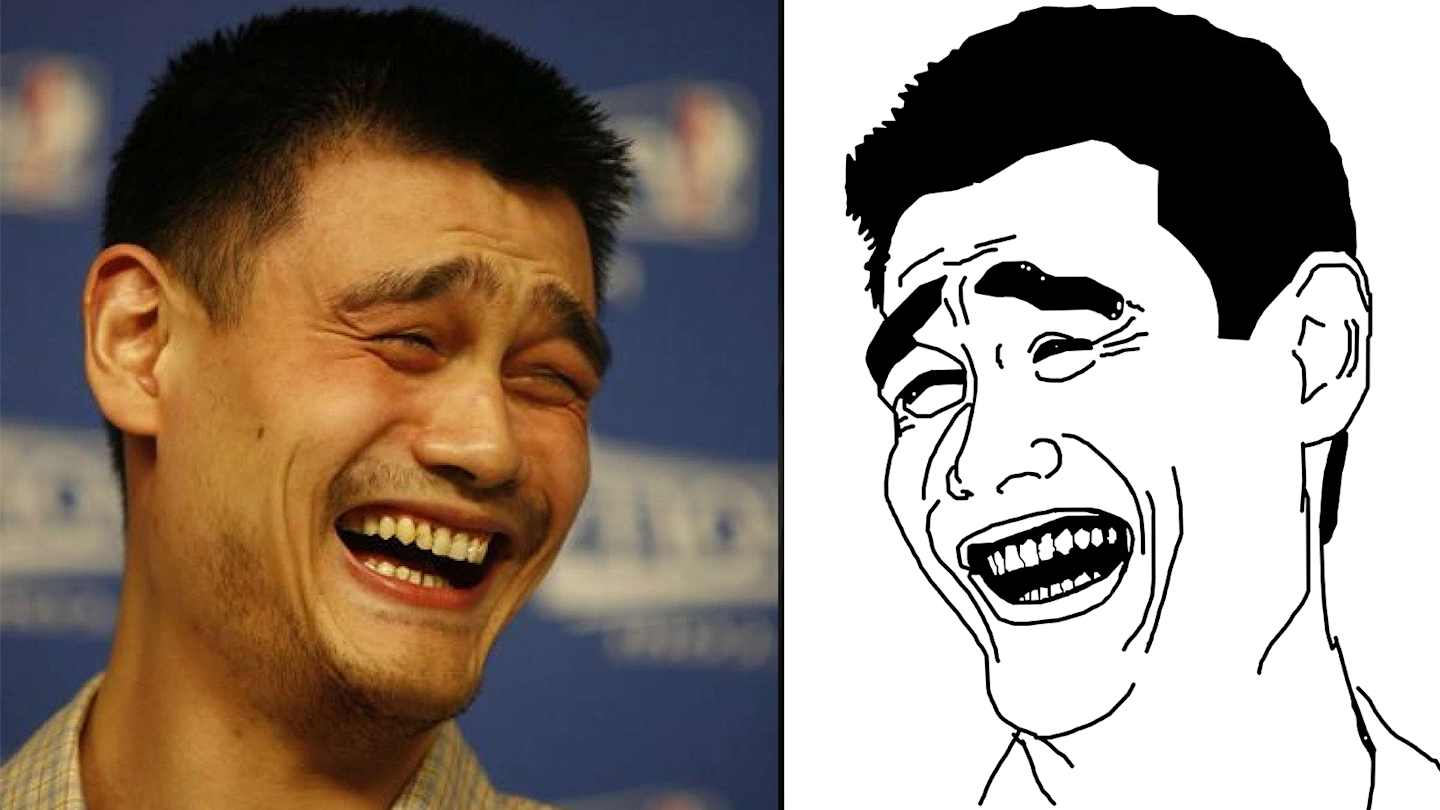

Kita coba lihat siapa atlet paling tinggi yang masuk 10 besar.

In [309]:
bios.sort_values(['height_rank']).head(10)[['name', 'height_cm']]

,name,height_cm
89070,Yao Ming,226.0
6978,Arvydas Sabonis,223.0
5781,Tommy Burleson,223.0
5673,Gunther Behnke,221.0
89075,Roberto Dueñas,221.0
120266,Zhang Zhaoxu,221.0
7188,Vladimir Tkachenko,220.0
6504,Luc Longley,220.0
5089,Viktor Pankrashkin,220.0
107408,Peter John Ramos,219.0


Ntah mereka kalo mesen baju ukurannya triple `XXL USA` atau gimana

---

### .cumsum()

Namanya sedikit.. ambigu, well itu singkatan dari cumulative sum. Jadi Cumulative Sum ini adalah menambahkan angka sebelumnya.

Hmm jadi kalo semisal : 
- hari senin dapet 2, disimpen dulu 2. 
- Nah hari selasa dapet 4, disimpen jadi 6.
- hari rabu 1, disimpen jadi 7,

gitu dan seterusnya/

In [310]:
coffee['Cumulative Revenue'] = coffee['Revenue'].cumsum()

In [311]:
coffee

,Day,Coffee Type,Units Sold,Price,Revenue,Yesterday Revenue,Percent Change,Cumulative Revenue
0,Monday,Espresso,15.000000,3.99,99.75,NaN,NaN,99.75
1,Monday,Latte,15.000000,5.99,89.85,NaN,NaN,189.60
2,Tuesday,Espresso,21.666667,3.99,119.70,99.75,1.200000,309.30
3,Tuesday,Latte,28.333333,5.99,119.80,89.85,1.333333,429.10
4,Wednesday,Espresso,35.000000,3.99,139.65,119.70,1.166667,568.75
5,Wednesday,Latte,25.000000,5.99,149.75,119.80,1.250000,718.50
6,Thursday,Espresso,40.000000,3.99,159.60,139.65,1.142857,878.10
7,Thursday,Latte,30.000000,5.99,179.70,149.75,1.200000,1057.80
8,Friday,Espresso,45.000000,3.99,179.55,159.60,1.125000,1237.35
9,Friday,Latte,35.000000,5.99,209.65,179.70,1.166667,1447.00


Jadi dari 13 hari bekerja sebagai starling, itu menghasilkan `$ 2225.40 `

---

### .rolling()

Fungsi `.rolling()` itu sebenarnya belum melakukan perhitungan apa-apa. Dia baru bertugas "membuat jendela" atau menentukan kotak datanya saja.

Tanpa fungsi tambahan seperti `.mean()`, `.sum()`, atau `.max()`, Pandas cuma akan menghasilkan objek "Rolling" yang masih mentah.

In [312]:
# Ini akan menghasilkan Error atau Objek mentah (Rolling Object)
test = coffee['Units Sold'].rolling(window=3) 
print(test) 
# Hasilnya cuma: Rolling [window=3,center=False,axis=0]

Rolling [window=3,center=False,axis=0,method=single]


In [313]:
# Ini baru jalan dan menghasilkan angka
rolling_sum = coffee['Units Sold'].rolling(window=3).sum()

In [314]:
rolling_sum

0            NaN
1            NaN
2      51.666667
3      65.000000
4      85.000000
5      88.333333
6     100.000000
7      95.000000
8     115.000000
9     110.000000
10    125.000000
11    115.000000
12    125.000000
13    115.000000
Name: Units Sold, dtype: float64

**Daftar "Perintah" yang sering dipakai setelah `.rolling()`**:

Selain .mean() dan .sum(), kamu bisa pakai ini:

- `.max()` : Mencari angka tertinggi dalam jendela tersebut (misal: "Berapa rekor penjualan tertinggi dalam 7 hari terakhir?").
- `.min()` : Mencari angka terendah dalam jendela tersebut.
- `.std()` : Mencari standar deviasi (untuk melihat seberapa stabil atau fluktuatif penjualanmu).
- `.var()` : Mencari varians data.

Sekarang make contoh datanya langsung : 

In [315]:
latte = coffee[coffee['Coffee Type'] == 'Latte'].copy()

In [316]:
latte

,Day,Coffee Type,Units Sold,Price,Revenue,Yesterday Revenue,Percent Change,Cumulative Revenue
1,Monday,Latte,15.000000,5.99,89.85,NaN,NaN,189.6
3,Tuesday,Latte,28.333333,5.99,119.80,89.85,1.333333,429.1
5,Wednesday,Latte,25.000000,5.99,149.75,119.80,1.250000,718.5
7,Thursday,Latte,30.000000,5.99,179.70,149.75,1.200000,1057.8
9,Friday,Latte,35.000000,5.99,209.65,179.70,1.166667,1447.0
11,Saturday,Latte,35.000000,5.99,209.65,209.65,1.000000,1836.2
13,Sunday,Latte,35.000000,5.99,209.65,209.65,1.000000,2225.4


In [317]:
latte['3day'] = latte['Units Sold'].rolling(3).sum()

In [318]:
latte

,Day,Coffee Type,Units Sold,Price,Revenue,Yesterday Revenue,Percent Change,Cumulative Revenue,3day
1,Monday,Latte,15.000000,5.99,89.85,NaN,NaN,189.6,NaN
3,Tuesday,Latte,28.333333,5.99,119.80,89.85,1.333333,429.1,NaN
5,Wednesday,Latte,25.000000,5.99,149.75,119.80,1.250000,718.5,68.333333
7,Thursday,Latte,30.000000,5.99,179.70,149.75,1.200000,1057.8,83.333333
9,Friday,Latte,35.000000,5.99,209.65,179.70,1.166667,1447.0,90.000000
11,Saturday,Latte,35.000000,5.99,209.65,209.65,1.000000,1836.2,100.000000
13,Sunday,Latte,35.000000,5.99,209.65,209.65,1.000000,2225.4,105.000000


Lihat di kolom `Units Sold`, 15 + 28 = `43`, `43` + 25 = 68

Kenapa yang 2 baris awal NaN? ya karena tadi kita ngisinya dimulai dari baris 3, `.rolling(3)`



kalo ga percaya kita coba lagi deh, angkanya kita ganti jadi 2

In [319]:
latte['2day'] = latte['Units Sold'].rolling(2).sum()

In [320]:
latte

,Day,Coffee Type,Units Sold,Price,Revenue,Yesterday Revenue,Percent Change,Cumulative Revenue,3day,2day
1,Monday,Latte,15.000000,5.99,89.85,NaN,NaN,189.6,NaN,NaN
3,Tuesday,Latte,28.333333,5.99,119.80,89.85,1.333333,429.1,NaN,43.333333
5,Wednesday,Latte,25.000000,5.99,149.75,119.80,1.250000,718.5,68.333333,53.333333
7,Thursday,Latte,30.000000,5.99,179.70,149.75,1.200000,1057.8,83.333333,55.000000
9,Friday,Latte,35.000000,5.99,209.65,179.70,1.166667,1447.0,90.000000,65.000000
11,Saturday,Latte,35.000000,5.99,209.65,209.65,1.000000,1836.2,100.000000,70.000000
13,Sunday,Latte,35.000000,5.99,209.65,209.65,1.000000,2225.4,105.000000,70.000000


---

# New Functionality

Mari menuju ke fungsi terbaru di `Pandas`. Dan tentunya akan terjadi perubahan besar. Mungkin pertama kali yang harus kita cek adalah versi dari `Pandas`-nya terlebih dahulu :

In [321]:
pd.__version__

'2.2.3'

### Pandas 1.0 vs Pandas 2.0 - pyarrow

In [322]:
results_numpy = pd.read_csv('./data/results.csv')
results_arrow = pd.read_csv('./data/results.csv', engine='pyarrow', dtype_backend='pyarrow')

Salah satu fitur baru adalah penggabungan backend `pyarrow`. Pada dasarnya, perbedaan antara `pyarrow` dan versi 1 yang menggunakan backend numpy adalah `pyarrow` memberikan optimasi yang jauh lebih baik dan dapat melakukan berbagai hal dengan lebih efisien, serta dapat berinteraksi dengan banyak alat rekayasa data dan ilmu data lainnya dengan lebih kuat daripada yang dapat dilakukan dengan numpy.

Dan beberapa hal penting yang akan Anda lihat sebagai pengguna sebenarnya berkaitan dengan kinerja.

Okdeh kita liat aja perbedaan dari keduanya

In [323]:
results_numpy.head()

,year,type,discipline,event,as,athlete_id,noc,team,place,tied,medal
0,1912.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,NaN,17.0,True,NaN
1,1912.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jean Montariol,NaN,False,NaN
2,1920.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,NaN,32.0,True,NaN
3,1920.0,Summer,Tennis,"Doubles, Mixed (Olympic)",Jean-François Blanchy,1,FRA,Jeanne Vaussard,8.0,True,NaN
4,1920.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jacques Brugnon,4.0,False,NaN


In [324]:
results_numpy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308408 entries, 0 to 308407
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   year        305807 non-null  float64
 1   type        305807 non-null  object 
 2   discipline  308407 non-null  object 
 3   event       308408 non-null  object 
 4   as          308408 non-null  object 
 5   athlete_id  308408 non-null  int64  
 6   noc         308407 non-null  object 
 7   team        121714 non-null  object 
 8   place       283193 non-null  float64
 9   tied        308408 non-null  bool   
 10  medal       44139 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(7)
memory usage: 23.8+ MB


Lalu dengan `arrow`

In [325]:
results_arrow.head()

,year,type,discipline,event,as,athlete_id,noc,team,place,tied,medal
0,1912.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,<NA>,17.0,True,<NA>
1,1912.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jean Montariol,<NA>,False,<NA>
2,1920.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,<NA>,32.0,True,<NA>
3,1920.0,Summer,Tennis,"Doubles, Mixed (Olympic)",Jean-François Blanchy,1,FRA,Jeanne Vaussard,8.0,True,<NA>
4,1920.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jacques Brugnon,4.0,False,<NA>


In [326]:
results_arrow.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308408 entries, 0 to 308407
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype          
---  ------      --------------   -----          
 0   year        305807 non-null  double[pyarrow]
 1   type        305807 non-null  string[pyarrow]
 2   discipline  308407 non-null  string[pyarrow]
 3   event       308408 non-null  string[pyarrow]
 4   as          308408 non-null  string[pyarrow]
 5   athlete_id  308408 non-null  int64[pyarrow] 
 6   noc         308407 non-null  string[pyarrow]
 7   team        121714 non-null  string[pyarrow]
 8   place       283193 non-null  double[pyarrow]
 9   tied        308408 non-null  bool[pyarrow]  
 10  medal       44139 non-null   string[pyarrow]
dtypes: bool[pyarrow](1), double[pyarrow](2), int64[pyarrow](1), string[pyarrow](7)
memory usage: 37.5 MB


**Disini kita bisa melihat**

<p float="left">
  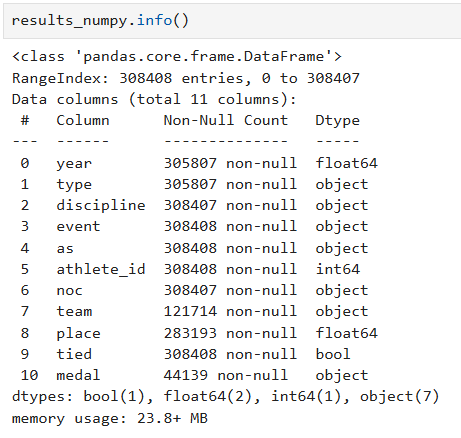
  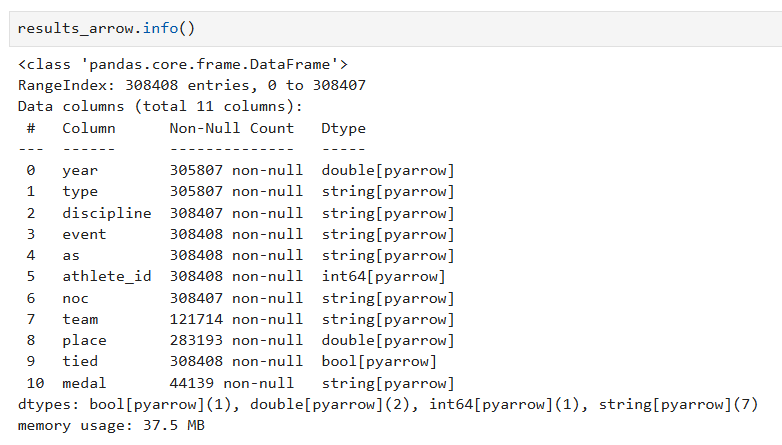 
</p>

Yang satu bentuknya `object`, sedangkan yang satunya `string`. Dimana `string` merupakan salah satu operasi terbesar yang perlu di optimasi menggunakan `back end = arrow` versus `numpy`. **`Numpy` memang tidak di desain untuk menangani tipe data `string`**. Dalam praktiknya kita bisa melakukan hal lebih efisien menggunakan `arrow`. 

Untuk lengkapnya bisa baca artikel berikut : https://datapythonista.me/blog/pandas-20-and-the-arrow-revolution-part-i

In [327]:
results_numpy['as'].str.contains('Agung')

0         False
1         False
2         False
3         False
4         False
          ...  
308403    False
308404    False
308405    False
308406    False
308407    False
Name: as, Length: 308408, dtype: bool

In [328]:
results_arrow['as'].str.contains('Agung')

0         False
1         False
2         False
3         False
4         False
          ...  
308403    False
308404    False
308405    False
308406    False
308407    False
Name: as, Length: 308408, dtype: bool[pyarrow]

Pada dasarnya, tidak ada perubahan fungsionalitas. Ini tetap berupa data frame dalam kedua situasi. Namun dengan menggunakan tipe spesifik seperti tipe `string` di dalam `pyarrow`, kita dapat melakukan optimasi dalam skala besar dengan operasi yang mencakup `string` yang berisi nilai `boolean`. Ada banyak hal berbeda yang dapat kita optimalkan di sini. Jadi, dalam sebagian besar situasi, jika performa menjadi pertimbangan utama, saya sarankan untuk beralih ke `pyarrow`. Anda harus menginstal `pyarrow`, tetapi itu sudah termasuk dalam persyaratan.

---